# 📓 Cas d'usage IA — Campagne de marketing bancaire

**Auteur** : Franck Walter  
**Promo** : Dev-id — Parcours 2 (Pros IT)  
**Date début** : 07/09/2026  
**Dernière mise à jour** : `JJ/MM/AAAA`

## 0. Imports & configuration

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins
DATA_DIR = Path("data")

# Affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")

# Imports ML (à activer au fur et à mesure)
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

In [2]:
import sys
import hashlib
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "UCI Bank Marketing — bank-additional-full.csv"
DATASET_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"
DATASET_VERSION = "2012-02-13"   # date de dépôt sur UCI, le contenu ne bouge plus depuis
DATASET_RECEIVED = "2026-07-23"  # date de réception du fichier fourni par Simplon
DATASET_PATH = DATA_DIR / "bank-additional-full.csv"

dataset_hash = hashlib.sha256(DATASET_PATH.read_bytes()).hexdigest()[:12]

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME}")
print(f"  source     : {DATASET_SOURCE}")
print(f"  version    : {DATASET_VERSION} (reçu le {DATASET_RECEIVED})")
print(f"  sha256     : {dataset_hash}")

Date session : 2026-10-01T23:01
Python       : 3.12.9
NumPy        : 2.5.3
Pandas       : 3.0.5
Git commit   : e8a6ad8
Dataset      : UCI Bank Marketing — bank-additional-full.csv
  source     : https://archive.ics.uci.edu/dataset/222/bank+marketing
  version    : 2012-02-13 (reçu le 2026-07-23)
  sha256     : 233e260d5d1d


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une banque de détail portugaise, dont le besoin est de faire souscrire à ses clients des contrats pour des produits d'épargne, en particulier un dépôt à terme. Cela rentre dans l'activité commerciale normale dans le secteur bancaire, à savoir vendre le plus possible de produits aux clients afin d'augmenter le chiffre d'affaires et donc les profits de l'entreprise.

D'après les données fournies, seuls 11% des clients souscrivent à un contrat suite à un appel de la banque, et les campagnes de démarchage téléphonique ont un coût, financier et en termes de dégradation de la relation commerciale. De même, les capacités d'appels de la banque sont limitées par le nombre de conseillers et la durée de la campagne, ce qui empêche d'appeler l'ensemble des clients. C'est pourquoi un ciblage des clients les plus susceptibles de souscrire au contrat est justifié, plutôt que de démarcher tous les clients.

C'est dans ce contexte qu'un recours à l'intelligence artificielle est demandé, afin d'augmenter le retour sur investissement de la campagne marketing, soit en obtenant davantage de souscriptions pour un nombre d'appels donné, soit en réduisant le nombre d'appels nécessaires.


### 1.2 Énoncé du problème IA

Il s'agit de prédire quels clients sont les plus susceptibles de souscrire un contrat pour un produit d'épargne. Il s'agit donc d'une classification en deux catégories, oui il va souscrire ou non il ne va pas souscrire.

Pour cela, les données utilisées sont :
- des données socio-démographiques du client
- la situation bancaire du client
- des informations sur le dernier contact de la campagne en cours
- un historique de la campagne
- le context socio-économique

### 1.3 Bénéficiaires & impacts

Le bénéficiaire direct de la solution est la banque, qui augmente son chiffre d'affaires en vendant des produits d'épargne.
Un client qui a souscrit un produit d'épargne peut être un bénéficiaire indirect si on considère qu'il tire des bénéfices de ce produit d'épargne, ou que le produit répond à un besoin de ce client.

En revanche, les clients peuvent subir un impact négatif si la campagne les incite à souscrire à un produit dont ils n'ont pas besoin ou qui va les impacter négativement, par exemple leur causer des pertes financières.


### 1.4 Critères de succès

| | Métier | Modèle | Opérationnel |
|---|---|---|---|
| **Critère** | Réduire le nombre de clients contactés tout en préservant les souscriptions | Rappel (recall) de la classe « oui », sous contrainte de volume de clients sélectionnés | Temps de réponse de l'API (p95) |
| **Cible initiale** | Contacter 50 % de clients en moins en conservant au moins 80 % des souscriptions | Rappel (recall) ≥ 0,80 en sélectionnant au maximum 50 % des clients | < 200 ms |
| **Pourquoi cette cible** | Réduire le coût des appels et les sollicitations inutiles, tout en limitant les ventes perdues | Limiter les souscripteurs manqués, sans atteindre artificiellement un bon rappel (recall) en sélectionnant tous les clients | Une réponse quasi instantanée permet au conseiller de préparer son appel sans attendre. Ce temps de réponse permet également de traiter un fichier de plusieurs milliers de clients en quelques heures. |
| **Cible révisée** | Cible maintenue : contacter 50 % des clients en conservant au moins 80 % des souscriptions | Rappel ≥ 0,80 en sélectionnant 50 % des clients, à confirmer sur le jeu de test | Cible maintenue : < 200 ms, à mesurer sur l’API |
| **Pourquoi la révision** | Les résultats de validation croisée permettent de maintenir l’objectif initial | L’arbre S5 atteint un rappel de 0,808 et la régression S5 de 0,812 : l’objectif paraît atteignable avant le réglage des hyperparamètres | Le temps de réponse n’a pas encore été évalué |
| **Cibles alternatives** | Adapter le volume d’appels aux ressources de la banque : sélectionner 25 % ou 75 % des clients | Avec l’arbre S5, rappels obtenus en validation croisée : 65,5 % à 25 % de clients sélectionnés et 92,4 % à 75 %, à confirmer sur le jeu de test | Même cible de temps de réponse : < 200 ms |
| **Confirmation sur le test** | Objectif atteint : 50 % des clients sélectionnés permettent de retrouver 82,33 % des souscripteurs | Régression logistique S5 : rappels de 66,7 % à 25 % d’appels, 82,33 % à 50 % et 91,9 % à 75 % | Latence p95 locale du pipeline : environ 1,8 ms ; cible < 200 ms à confirmer sur l’API |

### 1.5 Risques éthiques & réglementaires anticipés

**Variables sensibles** : âge, profession, situation familiale et niveau d’éducation, susceptibles d’entraîner un ciblage discriminatoire  
**Biais possibles** : les campagnes passées peuvent contenir des biais que le modèle risque de reproduire, en favorisant ou en excluant certains profils  
**RGPD** : vérifier les conditions d’utilisation des données personnelles pour le ciblage, leur minimisation et le respect des droits des clients.  
**AI Act** : déterminer la classification du système et les obligations applicables à une campagne marketing pour un produit bancaire  
**Droit sectoriel** : vérifier les règles applicables au démarchage téléphonique et à la commercialisation de produits d’épargne au Portugal.  
**Transparence** : les conseillers devront pouvoir comprendre les recommandations du modèle et garder la maîtrise du choix des clients à contacter.  
**Pression commerciale** : des sollicitations répétées ou inadaptées pourraient dégrader la relation client ou encourager une souscription qui ne répond pas à ses besoins.  


### 1.6 📝 Synthèse cadrage

La banque souhaite mieux cibler ses campagnes téléphoniques pour réduire leur coût et les sollicitations inutiles tout en préservant les souscriptions.  
La solution envisagée est un modèle de classification binaire prédisant la souscription à un produit d’épargne à partir des données clients et de campagne.  
L’objectif initial est de contacter 50 % de clients en moins en conservant au moins 80 % des souscriptions, soit un rappel (recall) ≥ 0,80 en sélectionnant au maximum 50 % des clients.  
Le principal risque éthique est de reproduire les biais des campagnes passées et de créer un ciblage discriminatoire ; l’utilisation des données et les pratiques commerciales devront aussi être examinées au regard du cadre réglementaire applicable.


---
## 2. Identification & acquisition des données



### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Bank Marketing, University of California, Irvine (UCI), fichier fourni par Simplon | Données tabulaires de campagnes de marketing bancaire | 41 188 lignes et 21 colonnes (20 variables explicatives + la cible `y`) | CSV, séparateur `;` | Fichier local : `data/bank-additional-full.csv` | Extraction non renseignée ; réception le 23/07/2026 |


In [3]:
# 2.2 Chargement
df = pd.read_csv(DATASET_PATH, sep=";")
df.shape, df.columns.tolist()

((41188, 21),
 ['age',
  'job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'poutcome',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed',
  'y'])

### 2.3 Dictionnaire de variables

À partir du sujet d'examen et de la [source UCI](https://archive.ics.uci.edu/dataset/222/bank+marketing).



| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `age` | Âge du client | Numérique | De 17 à 98 ans | × | ✅ |
| `job` | Type d’emploi du client | Catégoriel sans ordre | - `admin.` : employé administratif<br>- `blue-collar` : ouvrier<br>- `entrepreneur` : entrepreneur<br>- `housemaid` : employé de maison<br>- `management` : cadre / dirigeant<br>- `retired` : retraité<br>- `self-employed` : travailleur indépendant<br>- `services` : employé des services<br>- `student` : étudiant<br>- `technician` : technicien<br>- `unemployed` : sans emploi<br>- `unknown` : inconnu | × | ✅ |
| `marital` | Statut marital du client | Catégoriel sans ordre | - `married` : marié<br>- `single` : célibataire<br>- `divorced` : divorcé (inclut les personnes veuves)<br>- `unknown` : inconnu | × | ✅ |
| `education` | Niveau d’éducation | Catégoriel partiellement ordonné (`professional.course` difficile à situer ; `unknown` sans rang) | - `basic.4y` : enseignement de base, 4 ans<br>- `basic.6y` : enseignement de base, 6 ans<br>- `basic.9y` : enseignement de base, 9 ans<br>- `high.school` : enseignement secondaire<br>- `illiterate` : analphabète<br>- `professional.course` : formation professionnelle<br>- `university.degree` : diplôme universitaire<br>- `unknown` : inconnu | × | ✅ |
| `default` | Le client a-t-il un crédit en défaut de paiement ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `housing` | Le client a-t-il un prêt immobilier ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `loan` | Le client a-t-il un prêt personnel ? | Catégoriel sans ordre | - `yes` : oui<br>- `no` : non<br>- `unknown` : inconnu | × | × |
| `contact` | Type de moyen de contact du dernier contact de la campagne en cours | Catégoriel sans ordre | - `cellular` : téléphone mobile<br>- `telephone` : téléphone fixe | × | × |
| `month` | Mois du dernier contact de l’année pour la campagne en cours | Catégoriel cyclique | - `mar` : mars<br>- `apr` : avril<br>- `may` : mai<br>- `jun` : juin<br>- `jul` : juillet<br>- `aug` : août<br>- `sep` : septembre<br>- `oct` : octobre<br>- `nov` : novembre<br>- `dec` : décembre | × | × |
| `day_of_week` | Jour de la semaine du dernier contact de la campagne en cours | Catégoriel cyclique | - `mon` : lundi<br>- `tue` : mardi<br>- `wed` : mercredi<br>- `thu` : jeudi<br>- `fri` : vendredi | × | × |
| `duration` | Durée du dernier contact, en secondes, dans la campagne en cours | Numérique | De 0 à 4 918 secondes | × | × |
| `campaign` | Nombre de contacts effectués durant cette campagne pour ce client, incluant le dernier contact | Numérique | De 1 à 56 contacts | × | × |
| `pdays` | Nombre de jours écoulés depuis le dernier contact d’une campagne précédente | Numérique | - De 0 à 27 jours<br>- `999` signifie que le client n’a jamais été contacté auparavant | × | × |
| `previous` | Nombre de contacts effectués avant cette campagne pour ce client | Numérique (entier) | De 0 à 7 contacts | × | × |
| `poutcome` | Résultat de la campagne marketing précédente | Catégoriel sans ordre | - `failure` : échec<br>- `nonexistent` : absence de campagne précédente pour ce client<br>- `success` : succès | × | × |
| `emp.var.rate` | Taux de variation de l’emploi, indicateur trimestriel | Numérique | De -3,4 à 1,4 | × | × |
| `cons.price.idx` | Indice des prix à la consommation, indicateur mensuel | Numérique | De 92,201 à 94,767 | × | × |
| `cons.conf.idx` | Indice de confiance des consommateurs, indicateur mensuel | Numérique | De -50,8 à -26,9 | × | × |
| `euribor3m` | Taux Euribor à 3 mois, indicateur journalier | Numérique | De 0,634 à 5,045 | × | × |
| `nr.employed` | Nombre de salariés, indicateur trimestriel | Numérique | De 4 963,6 à 5 228,1 | × | × |
| `y` | Le client a-t-il souscrit un dépôt à terme ? | Binaire | - `yes` : oui<br>- `no` : non | ✅ | × |



### 2.4 📝 Synthèse acquisition

ORIGINE DES DONNÉES
- jeu de données UCI Bank Marketing
- fichier fourni par Simplon
- stocké localement dans `data/bank-additional-full.csv`

STRUCTURE DES DONNÉES
- jeu de données tabulaire composé de variables numériques, catégorielles et d’une cible binaire ;
- 41 188 lignes et 21 colonnes (y compris la cible)
- les variables sont nommées et décrivent le profil client, des données sur la campagne en cours et des campgnes précédentes, ainsi que données qui ne sont pas liées directement au client (le contexte économique)

PAS DE VALEUR MANQUANTE DIRECTE
- aucune valeur manquante, toutes les colonnes sont complètes

DES VALEURS INCONNUES
- des données qui pourraient être binaires mais qui ont une valeur `unknown` : `default` (20,87 %), `housing` (2,40 %) et `loan` (2,40 %)
- `poutcome` pourrait être binaire (`failure` / `success`), mais comporte une troisième modalité `nonexistent` lorsque le client n’a pas été contacté lors d’une campagne précédente
- les variables catégorielles `job`, `marital` et `education` comportent également une modalité `unknown` : `job` (0,80 %), `marital` (0,19 %) et `education` (4,20 %)
- pour la variable numérique `pdays` (nombre de jours écoulés depuis le dernier contact d'une campagne précédente), une valeur extrême utilisée pour signifier « jamais recontacté », à vérifeir par la suite si cette valeur pour fausser le modèle et s'il faut l'exclure ou la remplacer

UNE FUITE D'INFORMATION
- `duration` constitue une fuite d’information certaine : la durée de l’appel n’est connue qu’après celui-ci, alors que le modèle doit décider quels clients appeler avant le début de l’appel
- les variables `campaign`, `contact`, `month` et `day_of_week` décrivent aussi la campagne en cours. Leur utilisation dépend du moment où la décision de ciblage est prise et des informations réellement disponibles à ce moment-là. Il faudra donc clarifier le processus métier avant de les inclure dans le modèle
- les variables `pdays`, `previous` et `poutcome` décrivent les campagnes précédentes et peuvent a priori être connues avant un nouvel appel

DES VARIABLES SENSIBLES
- les personnelles des clients (son âge, son type d'emploi, son statut marital, son niveau d'éducation)





---
## 3. Exploration & analyse des données (EDA)

In [4]:
# 3.1 Premier coup d'œil
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()
# int64 (5) : age, duration, campaign, pdays, previous
# float64 (5) : emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
# str (11) : job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
print(df.describe(include="all"))
print(f"campaign > 10   : {(df['campaign']>10).mean()*100:.1f} %")
print(f"campaign == max : {(df['campaign']==df['campaign'].max()).sum()} ligne(s)")
print(f"pdays == 999    : {(df['pdays']==999).mean()*100:.1f} %")
print(f"previous == 0   : {(df['previous']==0).mean()*100:.1f} %")
print(df.nunique())
print(f"y == 'no'       : {(df['y']=='no').mean()*100:.1f} %")

# age : moyenne 40,0 proche de la médiane 38, rien à signaler
# duration : moyenne 258 >> médiane 180, max 4918 loin du Q3 (319), quelques appels très longs tirent la moyenne vers le haut ; à croiser avec y pour vérifier la fuite de données
# campaign : max 56 mais une seule ligne à cette valeur, 2,1 % > 10 contacts, à vérifier si erreur de saisie
# pdays : 96,3 % valent 999 ("jamais contacté avant"), seuls les 3,7 % restants ont une valeur réelle
# previous : 86,3 % ont la valeur 0, la grande majorité des clients n'ont jamais été contactés avant cette campagne
# emp.var.rate, cons.price.idx, cons.conf.idx, nr.employed : peu de valeurs distinctes (10, 26, 26, 11), se comportent davantage comme des catégorielles ordonnées que comme des valeurs continues
# euribor3m : 316 valeurs distinctes, plus variées que les autres indicateurs
# y : 88,7 % de "no" — cible déséquilibrée (11,3 % de "yes")

                age     job  marital          education default housing  \
count   41188.00000   41188    41188              41188   41188   41188   
unique          NaN      12        4                  8       3       3   
top             NaN  admin.  married  university.degree      no     yes   
freq            NaN   10422    24928              12168   32588   21576   
mean       40.02406     NaN      NaN                NaN     NaN     NaN   
std        10.42125     NaN      NaN                NaN     NaN     NaN   
min        17.00000     NaN      NaN                NaN     NaN     NaN   
25%        32.00000     NaN      NaN                NaN     NaN     NaN   
50%        38.00000     NaN      NaN                NaN     NaN     NaN   
75%        47.00000     NaN      NaN                NaN     NaN     NaN   
max        98.00000     NaN      NaN                NaN     NaN     NaN   

         loan   contact  month day_of_week      duration      campaign  \
count   41188     41188  

In [7]:
# 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

## MANQUANTS
print(df.isna().sum())
# aucune valeur manquante, toutes les colonnes sont à 0

## DOUBLONS
print(f"Doublons : {df.duplicated().sum()}")
# 12 lignes entièrement identiques à une autre ligne du dataset, donc il faudra déboulonner avant l'utilisation des données
print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))
# 12 paires de lignes identiques (indices) : 1265-1266, 12260-12261, 14155-14234, 16819-16956, 18464-18465, 20072-20216, 20531-20534, 25183-25217, 28476-28477, 32505-32516, 36950-36951, 38255-38281

# VALEURS ABERRANTES
# pdays : 96,3 % des valeurs sont à 999, code conventionnel signifiant que le client n’a pas été contacté auparavant.
# campaign : maximum de 56 contacts sur une seule ligne ; 2,1 % des observations dépassent 10 contacts.
# duration : maximum de 4 918 secondes, avec une moyenne de 258 secondes et une médiane de 180 secondes.
# age : les âges vont de 17 à 98 ans.
# Ces valeurs extrêmes paraissent plausibles et ne sont pas nécessairement des erreurs de saisie.

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Doublons : 12
       age          job   marital            education  default housing loan  \
28476   24     services    single          high.school       no     yes   no   
28477   24     services    single          high.school       no     yes   no   
14155   27   technician    single  professional.course       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
18464   32   technician    single  professional.course       no     yes   no   
18465   32   technician    single  professional.course       no     yes  

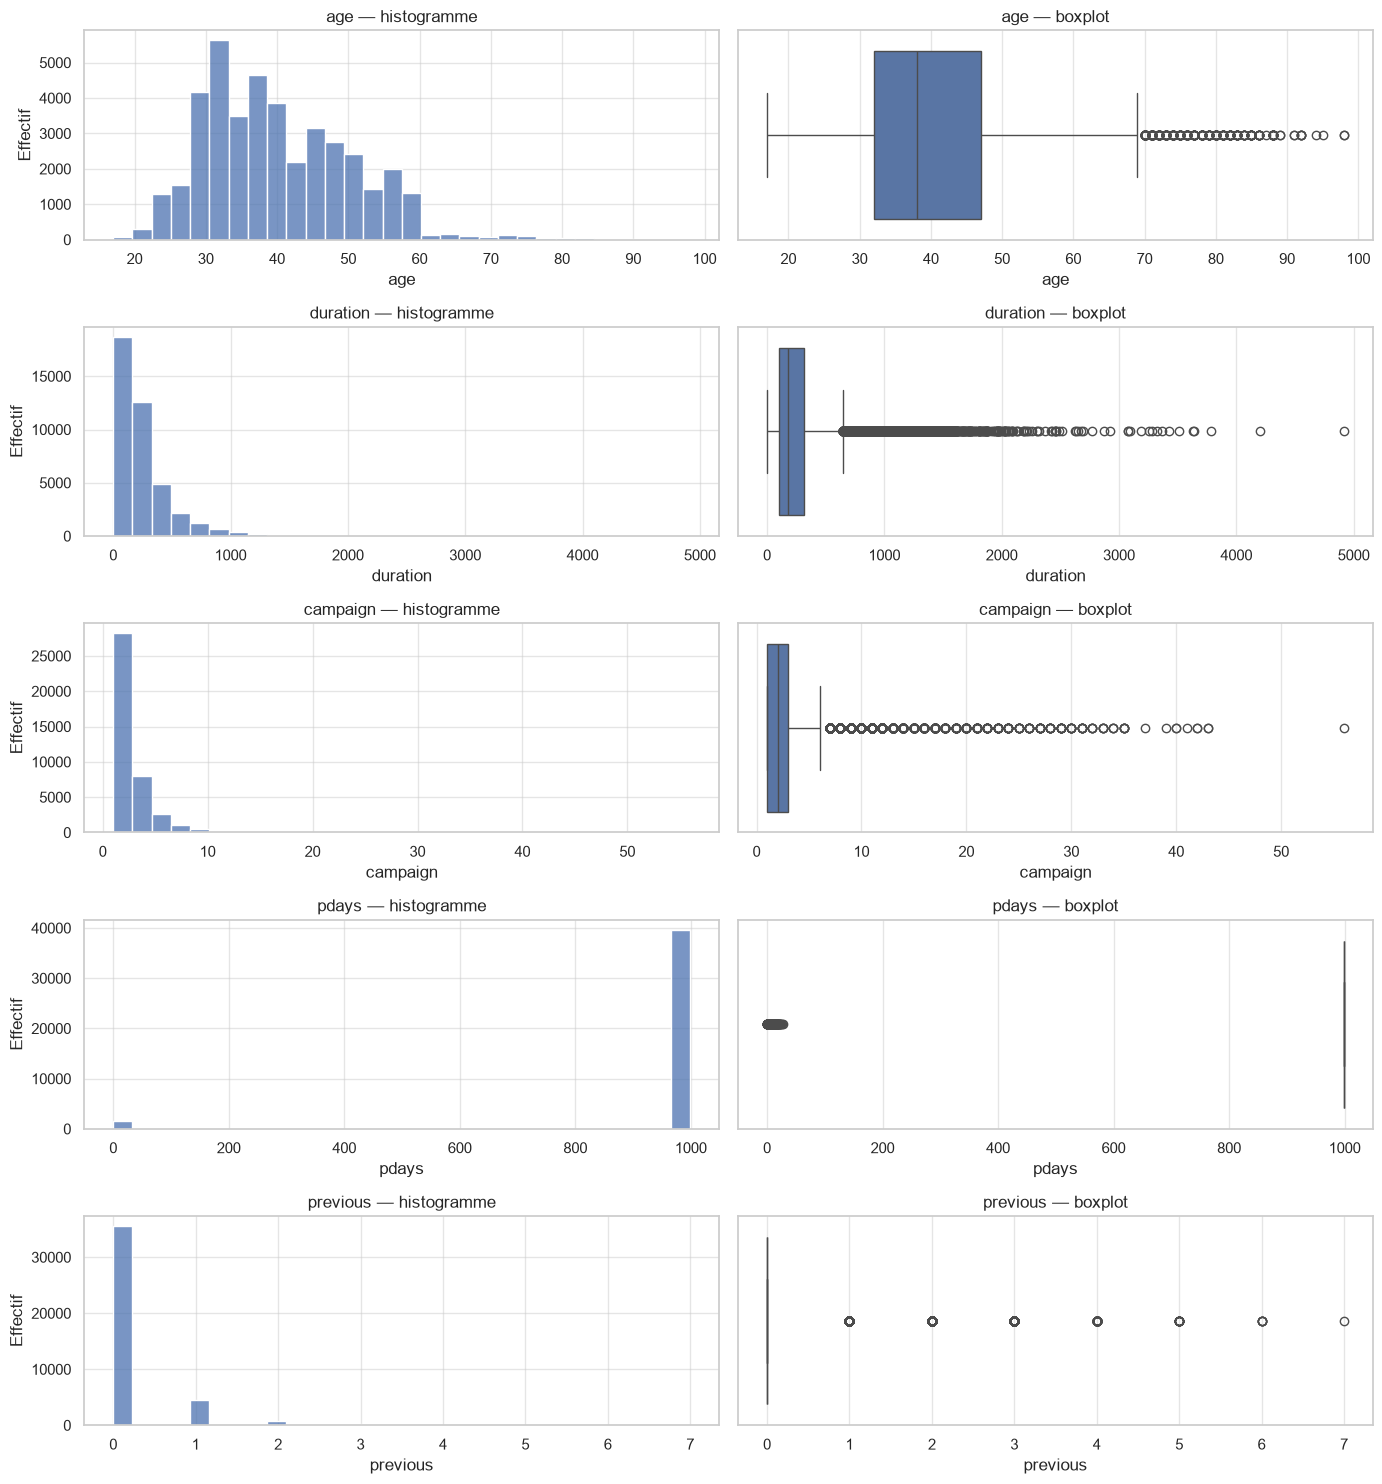

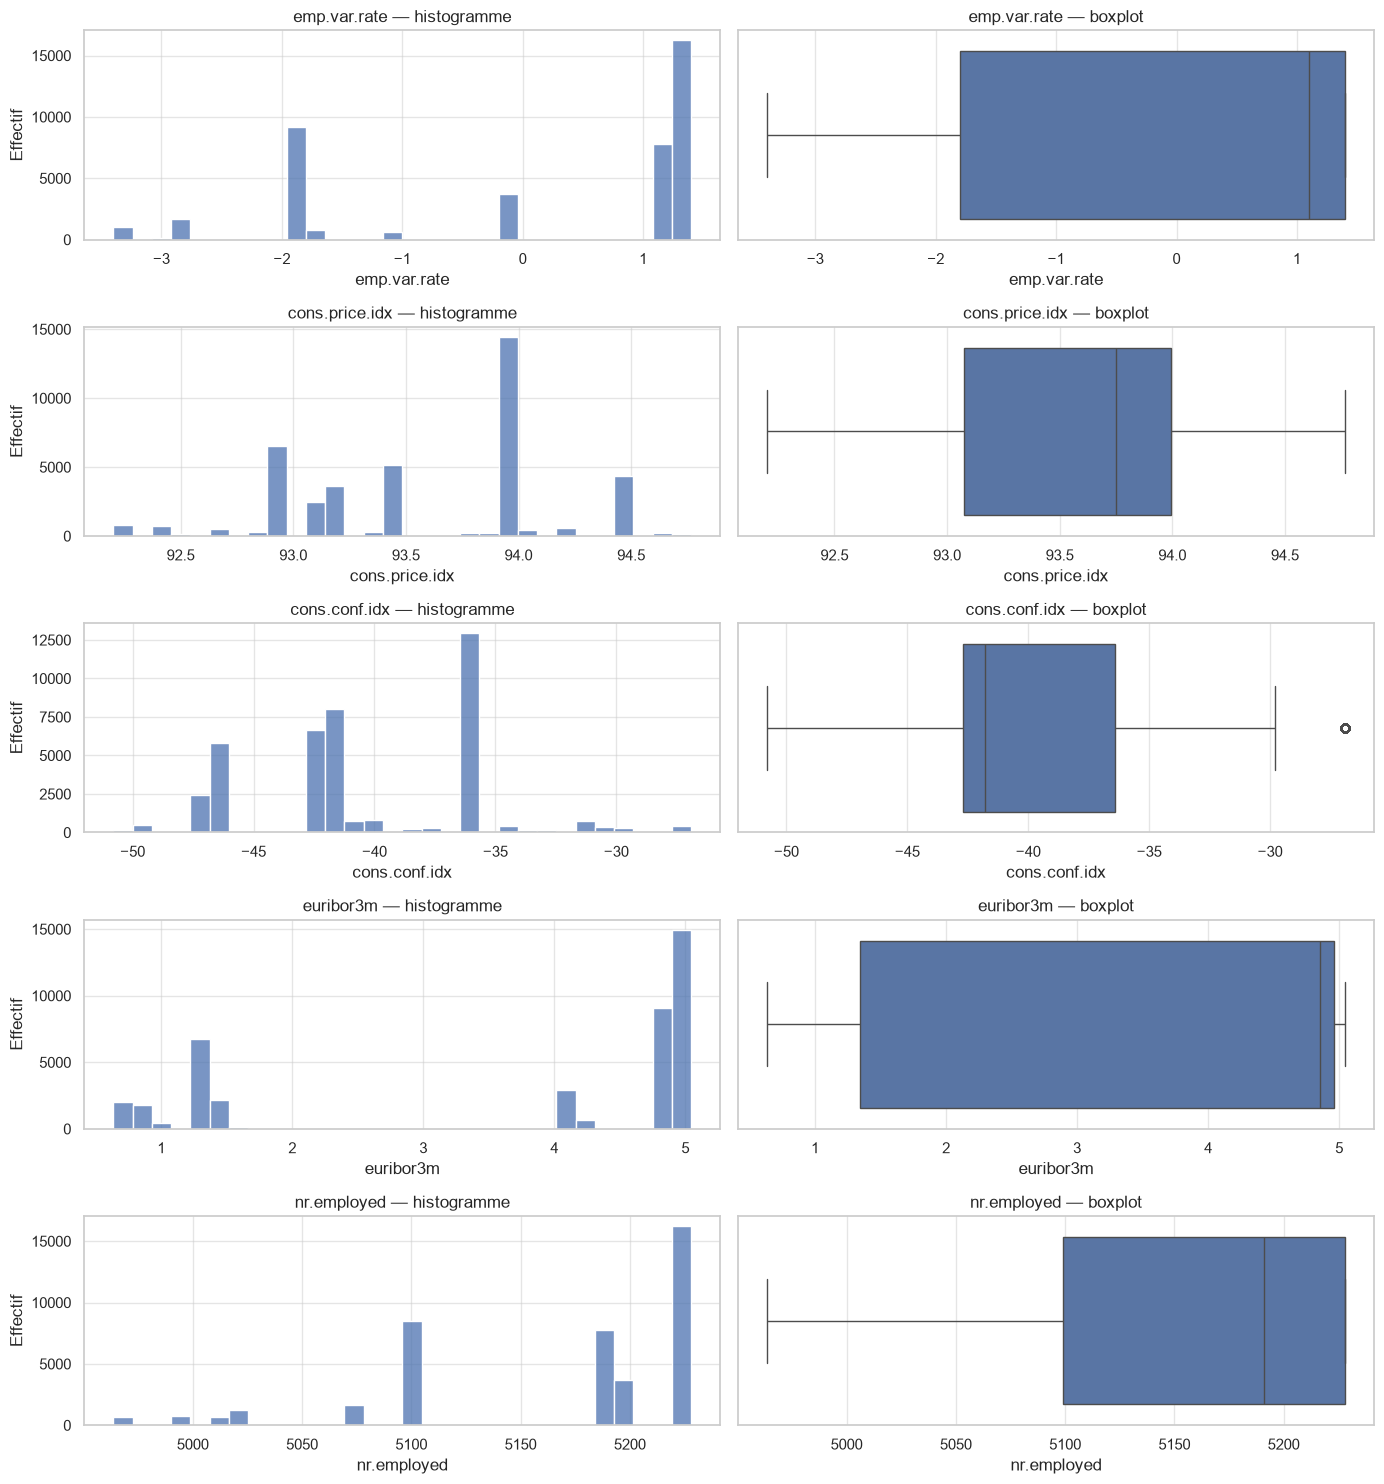

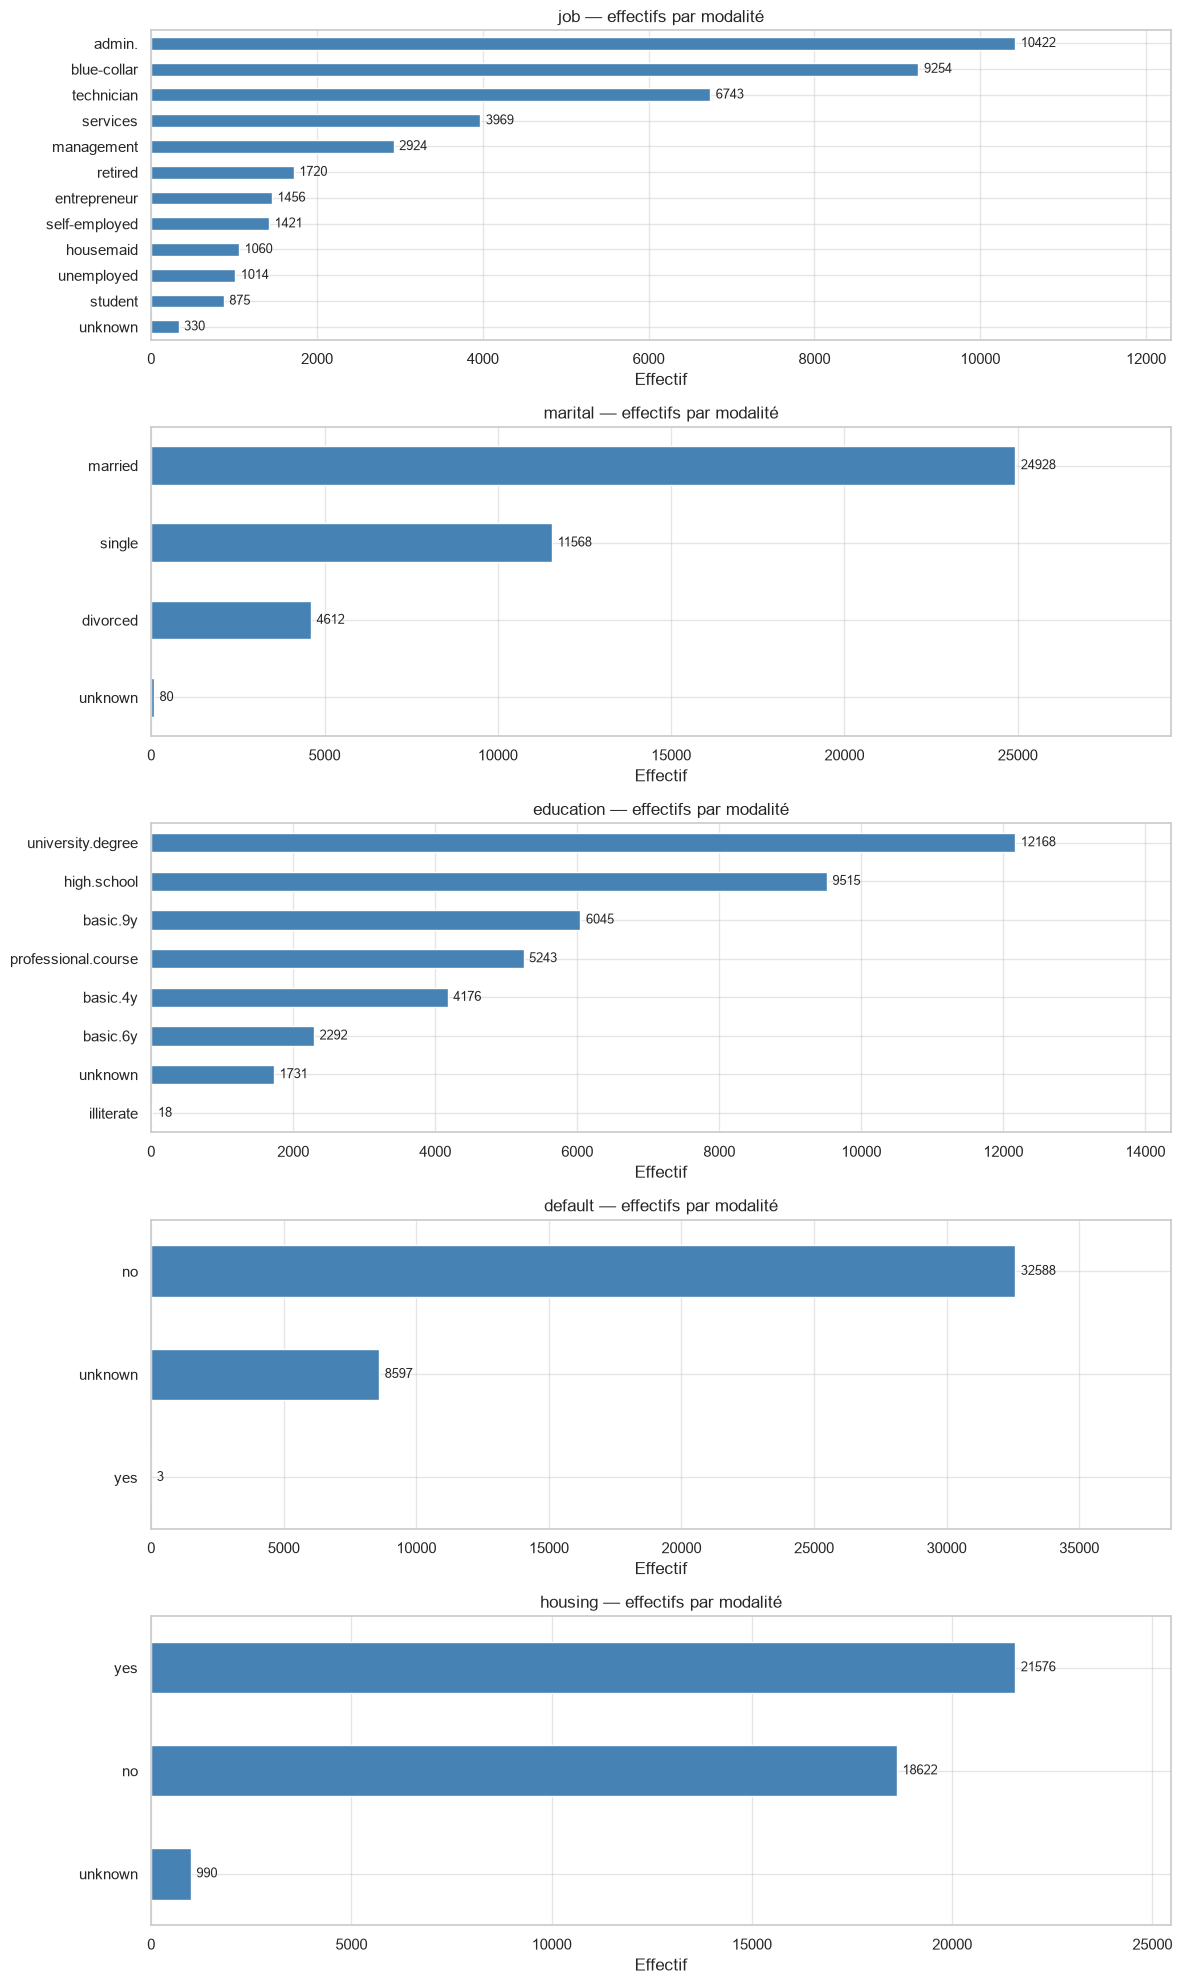

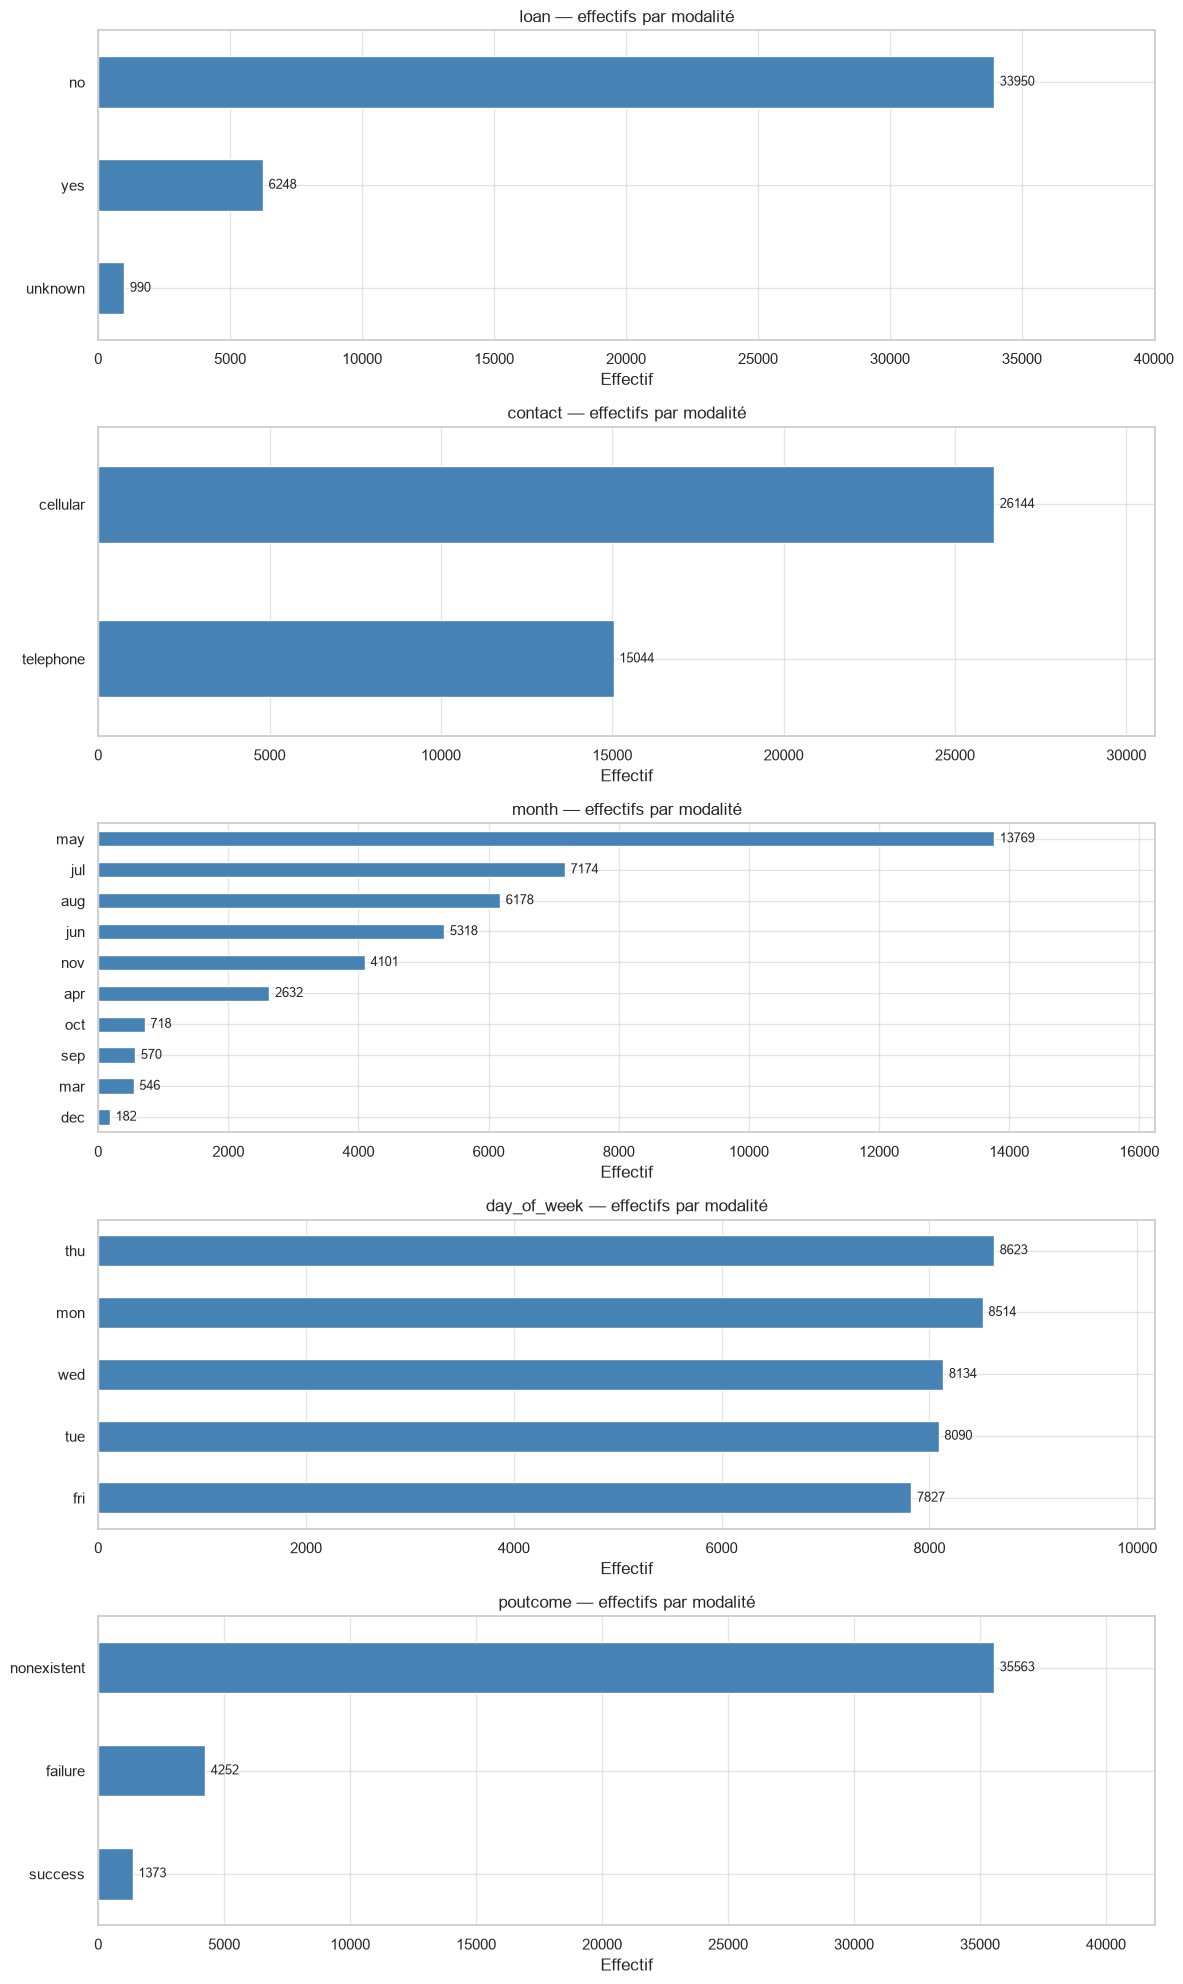

In [8]:
# 3.3 Distribution des variables (numériques + catégorielles)
# Histogrammes, boxplots, value_counts

variables_numeriques = df.select_dtypes(include="number").columns
variables_categorielles = df.drop(columns="y").select_dtypes(exclude="number").columns

for debut in range(0, len(variables_numeriques), 5):
    groupe = variables_numeriques[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 2, figsize=(14, 3 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        sns.histplot(data=df, x=variable, bins=30, ax=axes[ligne, 0])
        axes[ligne, 0].set_title(f"{variable} — histogramme")
        axes[ligne, 0].set_ylabel("Effectif")
        sns.boxplot(data=df, x=variable, ax=axes[ligne, 1])
        axes[ligne, 1].set_title(f"{variable} — boxplot")
    fig.tight_layout()
    plt.show()

for debut in range(0, len(variables_categorielles), 5):
    groupe = variables_categorielles[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 4 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        effectifs = df[variable].value_counts(dropna=False)
        ax = axes[ligne, 0]
        effectifs.iloc[::-1].plot.barh(ax=ax, color="steelblue")
        ax.set_title(f"{variable} — effectifs par modalité")
        ax.set_xlabel("Effectif")
        ax.set_ylabel("")
        ax.bar_label(ax.containers[0], padding=4, fontsize=9)
        ax.set_xlim(0, effectifs.max() * 1.18)
    fig.tight_layout()
    plt.show()


- `age` : les âges paraissent plausibles, avec une concentration chez les adultes jeunes ou d’âge moyen et des personnes âgées moins représentées.
- `duration` : les appels sont généralement courts, avec quelques durées extrêmes déjà relevées ; 3 000 à 4 000 secondes représentent 50 minutes à 1 h 07 et le maximum atteint environ 1 h 22, ce qui reste plausible.
- `campaign` : les clients ont généralement été contactés peu de fois, surtout une fois, mais les valeurs de 30 à 40 contacts et le maximum de 56 paraissent suspects et restent à vérifier.
- `pdays` : la valeur conventionnelle 999 domine et écrase la distribution des délais réels sur les graphiques.
- `previous` : la valeur 0 domine, avec quelques observations réparties entre 1 et 7 contacts antérieurs, ce qui paraît plausible.
- `emp.var.rate` : les valeurs se situent entre −3,4 et 1,4 et paraissent plausibles pour cet indicateur économique.
- `cons.price.idx` : les valeurs se situent entre 92,201 et 94,767 et paraissent plausibles pour cet indice.
- `cons.conf.idx` : les valeurs se situent entre −50,8 et −26,9 ; la valeur −26,9 apparaît isolée sur le boxplot, sans constituer à elle seule une erreur.
- `euribor3m` : les valeurs se situent entre 0,634 et 5,045 et paraissent plausibles pour ce taux.
- `nr.employed` : les valeurs se situent entre 4 963,6 et 5 228,1 et paraissent plausibles pour cet indicateur.
- `job` : les employés administratifs, ouvriers et techniciens sont les catégories les plus représentées ; les 330 `unknown` restent à traiter, avec un éventuel regroupement à justifier.
- `marital` : les personnes mariées dominent, suivies des célibataires ; les 80 `unknown` restent à traiter, avec un éventuel regroupement à justifier.
- `education` : `university.degree` et `high.school` sont les modalités les plus représentées séparément, mais les trois niveaux `basic` totalisent 12 513 personnes, ou 17 756 avec `professional.course`, et 1 731 valeurs sont `unknown`.
- `default` : les 8 597 `unknown` et les seuls 3 `yes` interrogent l’utilité de la variable et le risque d’apprendre une association fragile avec la souscription ; son maintien sera à évaluer.
- `housing` : les modalités `yes` et `no` sont assez équilibrées, avec 990 `unknown`.
- `loan` : les `no` dominent, les `yes` restent bien représentés et les 990 `unknown` invitent à vérifier s’il s’agit des mêmes lignes que pour `housing`.
- `contact` : les contacts par téléphone mobile dominent, avec une part de téléphone fixe qui reste représentée.
- `month` : la répartition reflète le calendrier des campagnes ; l’utilité de cette variable et sa pertinence pour une campagne menée à un autre moment de l’année restent à évaluer.
- `day_of_week` : la répartition est assez uniforme et l’apport prédictif du jour reste à vérifier.
- `poutcome` : `nonexistent` domine et indique l’absence de campagne précédente pour beaucoup de clients ; sa cohérence avec `previous` et `pdays` reste à vérifier.

À vérifier : les `unknown` concernent-ils les mêmes lignes, et certaines lignes cumulent-elles assez de variables inconnues pour envisager leur suppression ?


In [9]:
# 3.3 — Vérification des valeurs unknown communes
colonnes_unknown = [col for col in df.columns if df[col].eq("unknown").any()]
masque_unknown = df[colonnes_unknown].eq("unknown")
print("Nombre de unknown par variable :")
print(masque_unknown.sum().to_string())
print("\nCroisement housing / loan (True = unknown) :")
print(pd.crosstab(masque_unknown["housing"], masque_unknown["loan"]).to_string())
print("Mêmes lignes unknown pour housing et loan :",
      masque_unknown["housing"].equals(masque_unknown["loan"]))
print("\nNombre de lignes unknown en commun entre variables :")
print(masque_unknown.astype(int).T.dot(masque_unknown.astype(int)).to_string())
nb_unknown = masque_unknown.sum(axis=1)
print("\nRépartition du nombre de variables unknown par ligne :")
print(nb_unknown.value_counts().sort_index().rename_axis("Nombre de unknown").to_string())
print("\nCombinaisons de variables inconnues pour les lignes avec au moins 2 unknown :")
combinaisons_unknown = masque_unknown.loc[nb_unknown.ge(2)].apply(
    lambda ligne: ", ".join(ligne.index[ligne]), axis=1
)
print(combinaisons_unknown.value_counts().to_string())

# Conclusion : les 990 unknown de housing et loan concernent exactement les mêmes lignes (2,40 % du jeu de données).
# On les conserve pour le moment ; on pourrait comparer les modèles avec et sans ces lignes dans l’entraînement, sur les mêmes jeux de validation conservés complets, pour mesurer l’effet de leur exclusion avant de décider de les exclure ou non


Nombre de unknown par variable :
job           330
marital        80
education    1731
default      8597
housing       990
loan          990

Croisement housing / loan (True = unknown) :
loan     False  True 
housing              
False    40198      0
True         0    990
Mêmes lignes unknown pour housing et loan : True

Nombre de lignes unknown en commun entre variables :
           job  marital  education  default  housing  loan
job        330        9        131      152        5     5
marital      9       80          9       11        1     1
education  131        9       1731      548       40    40
default    152       11        548     8597      227   227
housing      5        1         40      227      990   990
loan         5        1         40      227      990   990

Répartition du nombre de variables unknown par ligne :
Nombre de unknown
0    30488
1     9034
2     1338
3      306
4       20
5        2

Combinaisons de variables inconnues pour les lignes avec au moins 2 

In [10]:
# 3.3 — Cohérence interne de l’historique de campagne
print("Croisement poutcome / previous :")
print(pd.crosstab(df["poutcome"], df["previous"]).to_string())
print("\nCroisement poutcome / pdays = 999 :")
print(pd.crosstab(df["poutcome"], df["pdays"].eq(999).rename("pdays = 999")).to_string())
print("\nCroisement previous = 0 / pdays = 999 :")
print(pd.crosstab(df["previous"].eq(0).rename("previous = 0"),
                  df["pdays"].eq(999).rename("pdays = 999")).to_string())
verifications = pd.Series({
    "poutcome nonexistent avec previous > 0": (df["poutcome"].eq("nonexistent") & df["previous"].gt(0)).sum(),
    "previous = 0 avec poutcome différent de nonexistent": (df["previous"].eq(0) & df["poutcome"].ne("nonexistent")).sum(),
    "poutcome nonexistent avec pdays différent de 999": (df["poutcome"].eq("nonexistent") & df["pdays"].ne(999)).sum(),
    "previous = 0 avec pdays différent de 999": (df["previous"].eq(0) & df["pdays"].ne(999)).sum(),
    "pdays = 999 avec previous > 0 (cas à examiner)": (df["pdays"].eq(999) & df["previous"].gt(0)).sum(),
})
print("\nEffectifs des cas à vérifier :")
print(verifications.to_string())

# Conclusion : poutcome = nonexistent correspond exactement à previous = 0, et toutes ces lignes ont pdays = 999.
# Toutefois, 4 110 lignes ont pdays = 999 avec previous > 0 et poutcome = failure ; cette combinaison reste à éclaircir avant de décider d’un traitement.


Croisement poutcome / previous :
previous         0     1    2    3   4   5  6  7
poutcome                                        
failure          0  3696  434   88  30   3  1  0
nonexistent  35563     0    0    0   0   0  0  0
success          0   865  320  128  40  15  4  1

Croisement poutcome / pdays = 999 :
pdays = 999  False  True 
poutcome                 
failure        142   4110
nonexistent      0  35563
success       1373      0

Croisement previous = 0 / pdays = 999 :
pdays = 999   False  True 
previous = 0              
False          1515   4110
True              0  35563

Effectifs des cas à vérifier :
poutcome nonexistent avec previous > 0                    0
previous = 0 avec poutcome différent de nonexistent       0
poutcome nonexistent avec pdays différent de 999          0
previous = 0 avec pdays différent de 999                  0
pdays = 999 avec previous > 0 (cas à examiner)         4110


     Effectif  Pourcentage (%)
y                             
no      36548            88.73
yes      4640            11.27


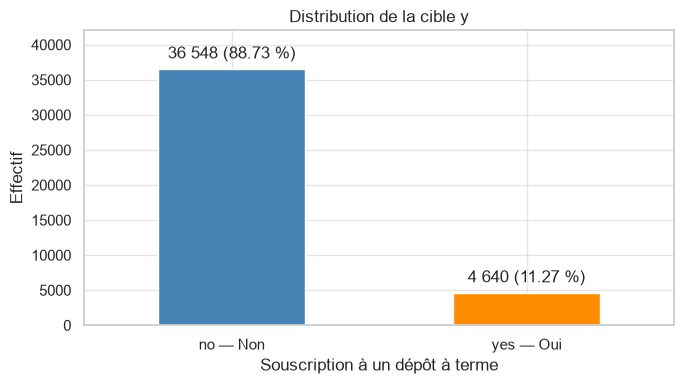

In [11]:
# 3.4 Variable cible : équilibre des classes / distribution

effectifs_cible = df["y"].value_counts().reindex(["no", "yes"], fill_value=0)
pourcentages_cible = df["y"].value_counts(normalize=True).reindex(["no", "yes"], fill_value=0) * 100
distribution_cible = pd.DataFrame({
    "Effectif": effectifs_cible,
    "Pourcentage (%)": pourcentages_cible.round(2),
})
print(distribution_cible.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
effectifs_cible.plot.bar(ax=ax, color=["steelblue", "darkorange"], rot=0)
ax.set_title("Distribution de la cible y")
ax.set_xlabel("Souscription à un dépôt à terme")
ax.set_ylabel("Effectif")
ax.set_xticklabels(["no — Non", "yes — Oui"])
ax.bar_label(
    ax.containers[0],
    labels=[f"{n:,} ({p:.2f} %)".replace(",", " ")
            for n, p in zip(effectifs_cible, pourcentages_cible)],
    padding=5,
)
ax.set_ylim(0, effectifs_cible.max() * 1.15)
fig.tight_layout()
plt.show()

# La cible comprend 36 548 non-souscriptions (88,73 %) et 4 640 souscriptions (11,27 %).
# Les classes sont déséquilibrées : la classe « yes » est nettement minoritaire, comme déjà relevé lors des premières observations.


In [12]:
# 3.5 Corrélations & relations entre variables
# Matrice de corrélation, pairplot, croisements clés vs cible

In [13]:
# Copie dédiée aux graphiques : 999 est écarté des délais numériques de pdays.
# Les données df restent inchangées ; chaque corrélation utilise les valeurs disponibles.
donnees_relations = df.copy()
donnees_relations["pdays"] = donnees_relations["pdays"].replace(999, np.nan)
donnees_relations["y_oui"] = donnees_relations["y"].map({"no": 0, "yes": 1})
colonnes_num = df.select_dtypes(include="number").columns.tolist()
colonnes_cat = df.drop(columns="y").select_dtypes(exclude="number").columns.tolist()

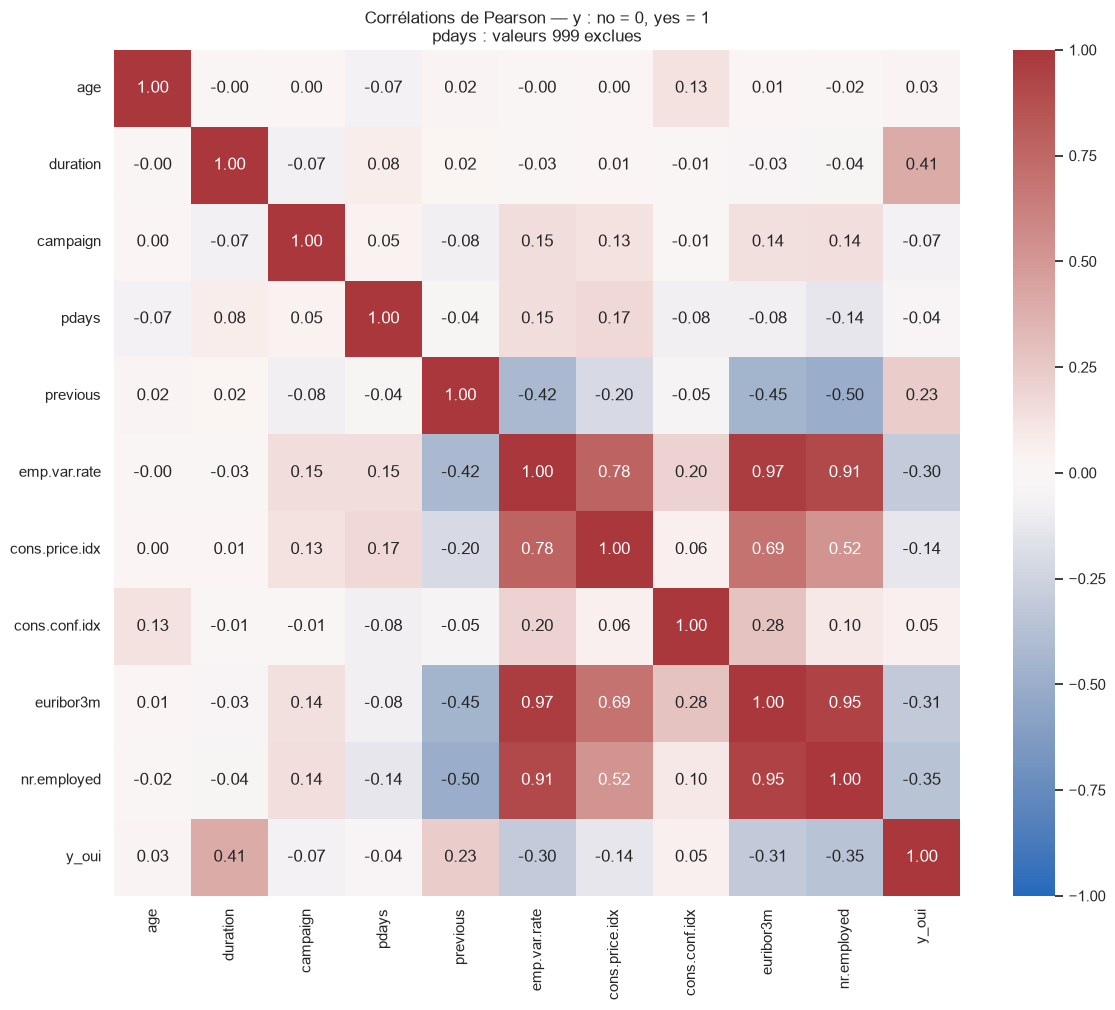

In [14]:
## MATRICE DE CORRÉLATION
correlations = donnees_relations[colonnes_num + ["y_oui"]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Corrélations de Pearson — y : no = 0, yes = 1\npdays : valeurs 999 exclues")
fig.tight_layout()
plt.show()

# Les fortes corrélations entre indicateurs économiques sont plausibles, car ils décrivent un contexte commun au fil des mêmes périodes.
# emp.var.rate, euribor3m et nr.employed sont très corrélés (0,91 à 0,97) : leur information est en partie redondante et leur maintien conjoint sera à évaluer.
# cons.conf.idx est peu corrélé aux autres indicateurs économiques (0,06 à 0,28) et décrit une dimension différente du contexte.
# duration est la variable numérique la plus corrélée à la souscription (+0,41), mais elle reste indisponible avant l’appel et constitue une fuite d’information.
# nr.employed (−0,35), euribor3m (−0,31) et emp.var.rate (−0,30) sont associés à la cible ; la pertinence du modèle sur une autre période sera à vérifier.
# previous est positivement associé à la souscription (+0,23), sans démontrer que multiplier les contacts provoque une souscription.
# age est peu corrélé linéairement à la cible (+0,03), ce qui laisse possible une relation différente selon les tranches d’âge.
# La corrélation de pdays avec la cible (−0,04) concerne uniquement les délais différents de 999 ; le statut 999 est étudié séparément.


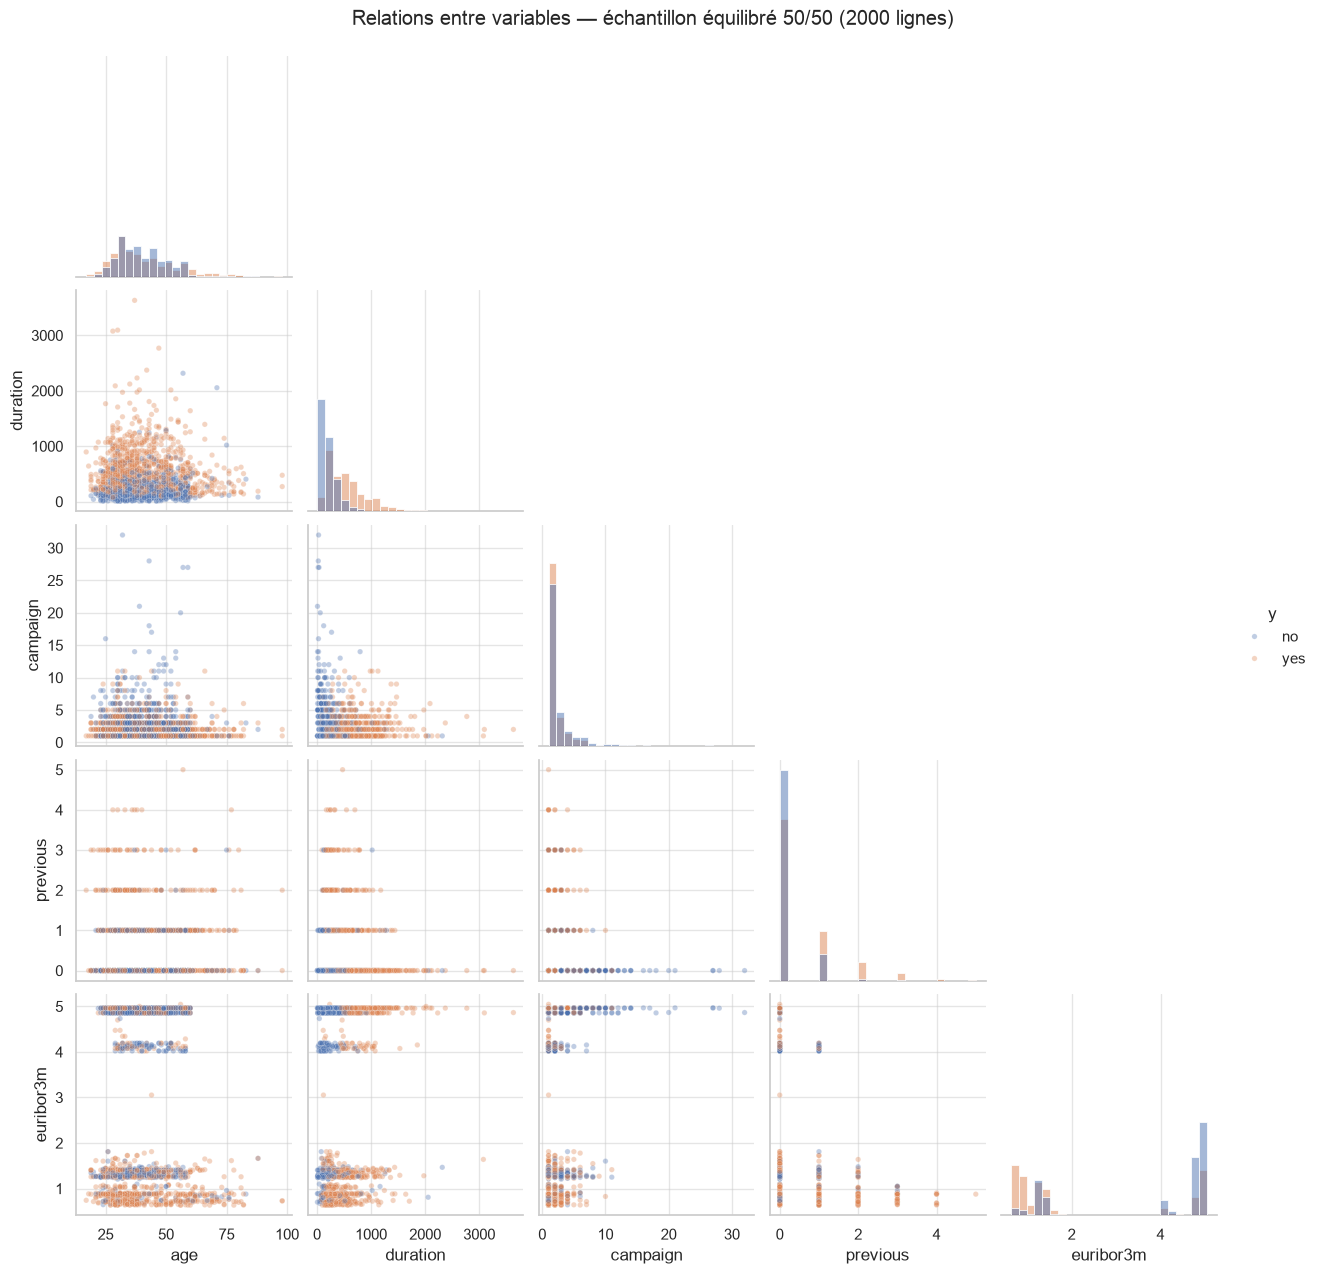

In [15]:
## PAIRPLOT
# Échantillon reproductible équilibré pour le graphique : 1 000 lignes par classe.
variables_pairplot = ["age", "duration", "campaign", "previous", "euribor3m"]
echantillon_relations = pd.concat([
    donnees_relations.loc[donnees_relations["y"].eq(classe)].sample(
        n=1000, random_state=RANDOM_STATE
    )
    for classe in ["no", "yes"]
]).sample(frac=1, random_state=RANDOM_STATE)
g = sns.pairplot(echantillon_relations, vars=variables_pairplot, hue="y",
                 hue_order=["no", "yes"], corner=True, diag_kind="hist",
                 plot_kws={"alpha": 0.35, "s": 15}, diag_kws={"bins": 25})
g.fig.suptitle(f"Relations entre variables — échantillon équilibré 50/50 ({len(echantillon_relations)} lignes)", y=1.02)
plt.show()

# duration distingue visuellement les classes, mais reste exclue du ciblage avant appel pour fuite d’information.
# previous et euribor3m semblent liés : leur apport prédictif propre reste à vérifier lors de la modélisation.
# Les classes se chevauchent largement ; ces croisements ne font apparaître aucune règle simple de séparation.


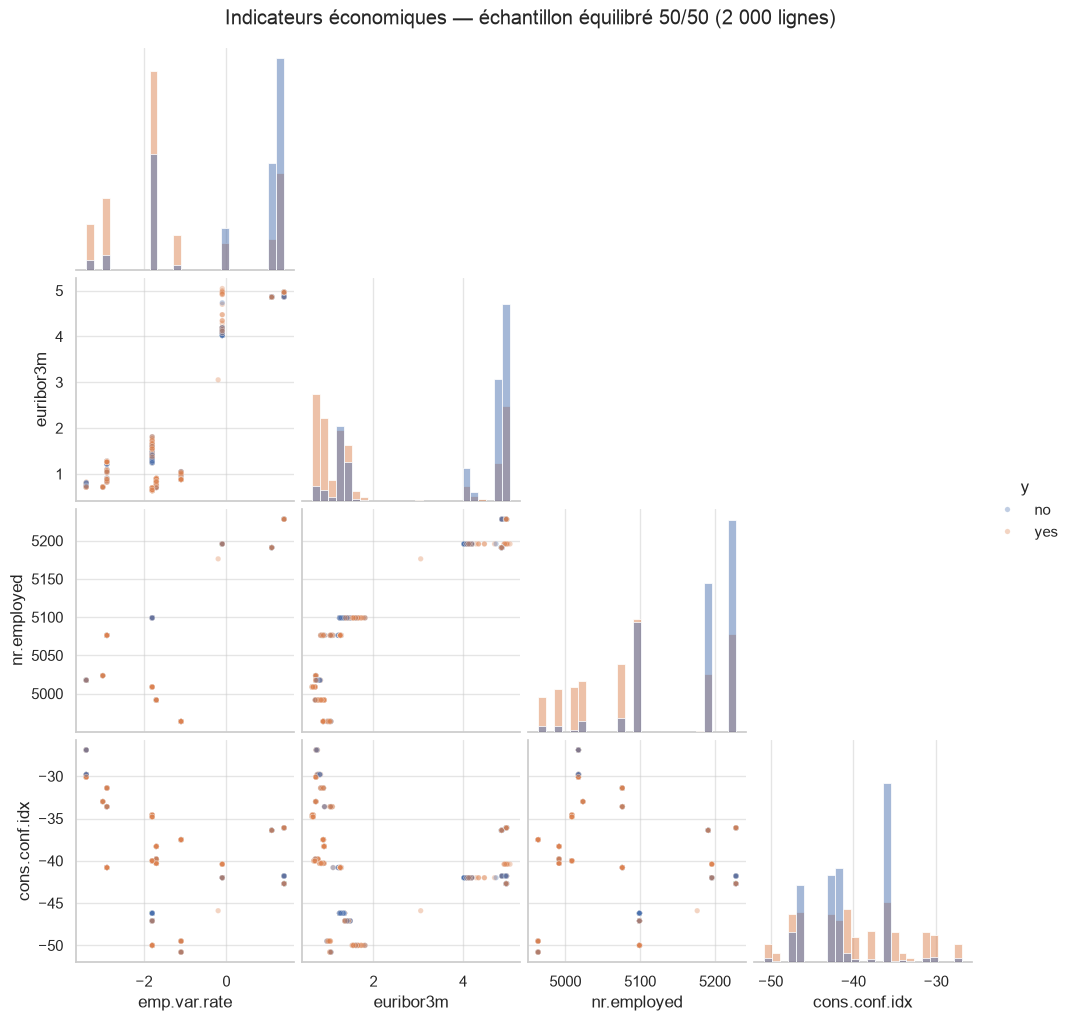

In [16]:
## RELATIONS ENTRE INDICATEURS ÉCONOMIQUES
# Même échantillon équilibré 50/50 pour explorer la redondance et cons.conf.idx.
variables_economiques = ["emp.var.rate", "euribor3m", "nr.employed", "cons.conf.idx"]
g = sns.pairplot(echantillon_relations, vars=variables_economiques, hue="y",
                 hue_order=["no", "yes"], corner=True, diag_kind="hist",
                 plot_kws={"alpha": 0.35, "s": 15}, diag_kws={"bins": 25})
g.fig.suptitle("Indicateurs économiques — échantillon équilibré 50/50 (2 000 lignes)", y=1.02)
plt.show()

# emp.var.rate, euribor3m et nr.employed portent une information en partie redondante : comparer leur apport conjoint à celui d’un sous-ensemble.
# cons.conf.idx présente des relations moins linéaires avec les autres indicateurs ; son utilité prédictive reste à évaluer.

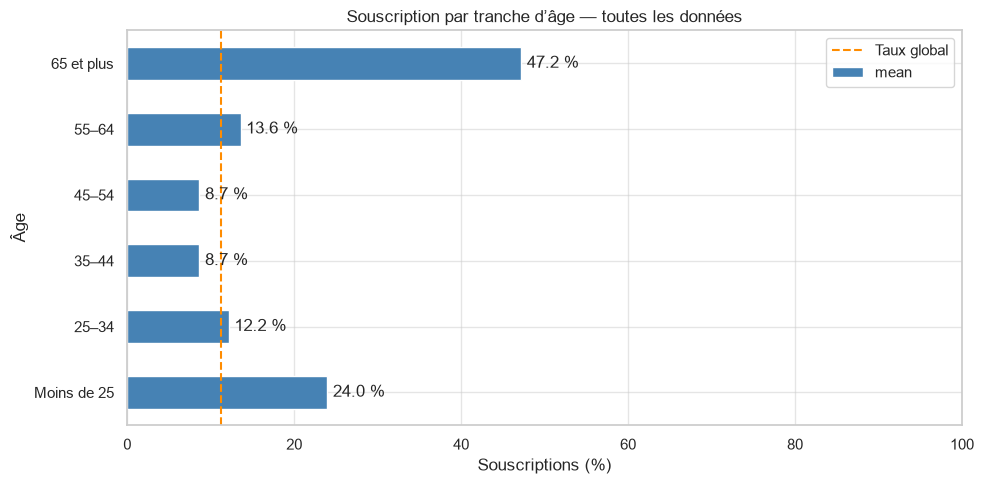

In [17]:
## TAUX DE SOUSCRIPTION PAR TRANCHE D’ÂGE
# Taux calculés sur toutes les données.
tranches_age = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, np.inf],
                      labels=["Moins de 25", "25–34", "35–44", "45–54", "55–64", "65 et plus"], right=False)
stats_age = donnees_relations.groupby(tranches_age, observed=True)["y_oui"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(10, 5))
(stats_age["mean"] * 100).plot.barh(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0], labels=[f"{t * 100:.1f} %" for t in stats_age["mean"]], padding=4)
ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange", linestyle="--", label="Taux global")
ax.set(title="Souscription par tranche d’âge — toutes les données", xlabel="Souscriptions (%)", ylabel="Âge", xlim=(0, 100))
ax.legend()
fig.tight_layout()
plt.show()

# Taux et effectifs : moins de 25 ans 24,0 %, 25–34 ans 12,2 %, 35–44 ans 8,7 %, 45–54 ans 8,7 %, 55–64 ans 13,6 %, 65 ans et plus 47,2 %.


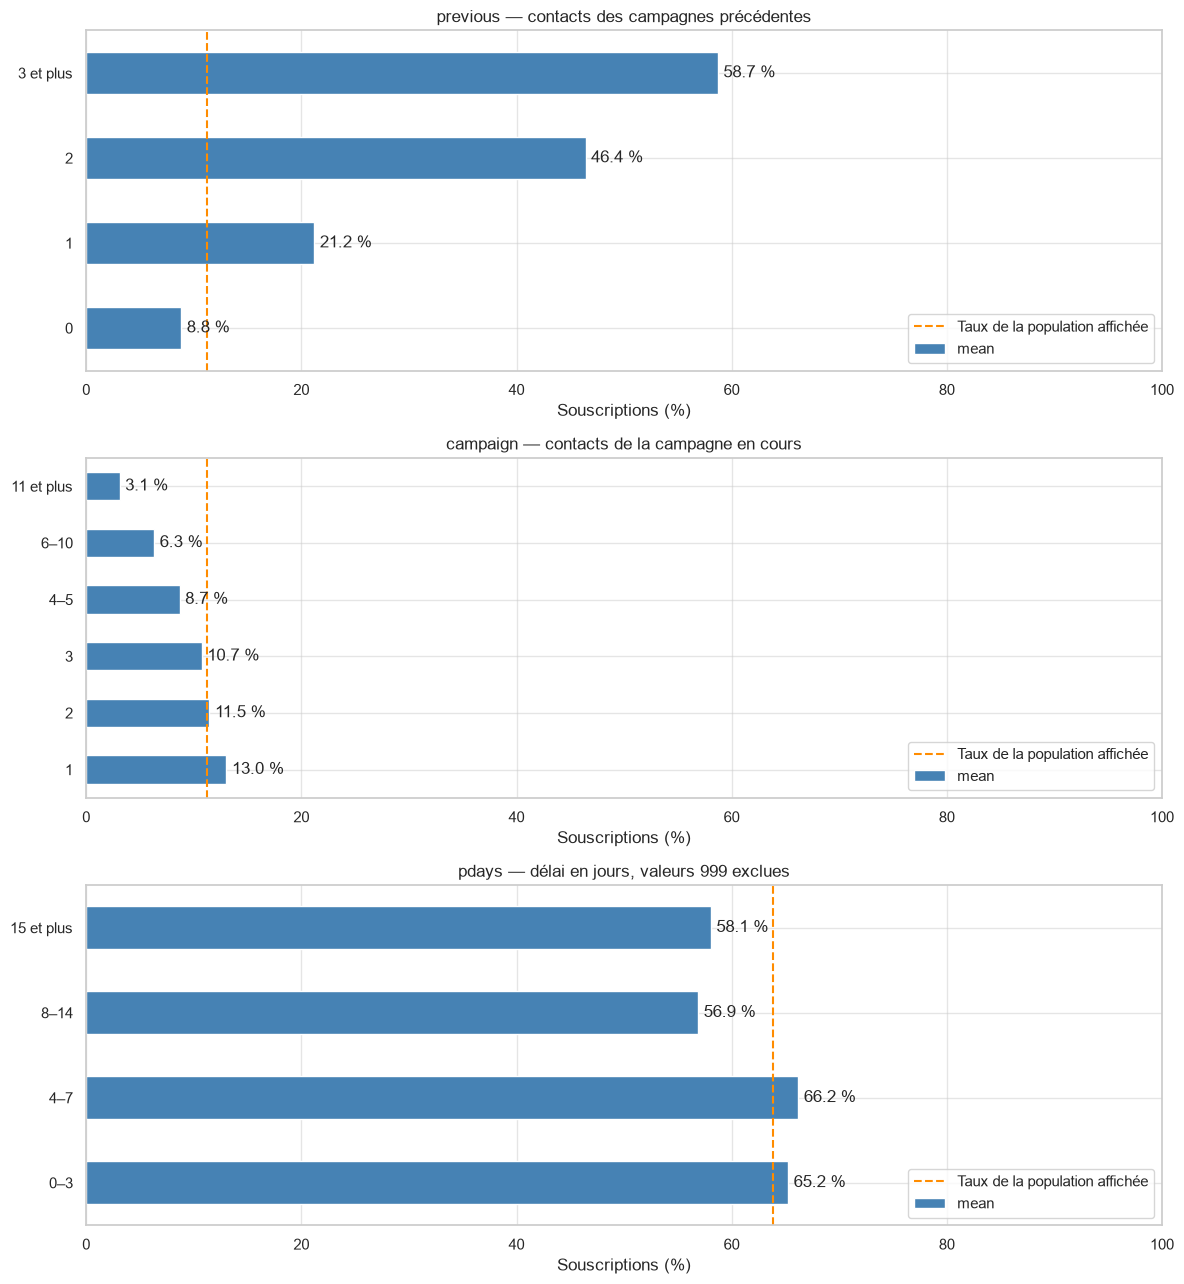

In [18]:
## TAUX DE SOUSCRIPTION SELON LES CONTACTS ET LES DÉLAIS
# Toutes les données ; les délais réels de pdays sont étudiés hors code 999.
groupes_contacts = {
    "previous — contacts des campagnes précédentes": pd.cut(
        df["previous"], bins=[-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3 et plus"]),
    "campaign — contacts de la campagne en cours": pd.cut(
        df["campaign"], bins=[0, 1, 2, 3, 5, 10, np.inf], labels=["1", "2", "3", "4–5", "6–10", "11 et plus"]),
    "pdays — délai en jours, valeurs 999 exclues": pd.cut(
        donnees_relations["pdays"], bins=[-1, 3, 7, 14, np.inf], labels=["0–3", "4–7", "8–14", "15 et plus"]),
}
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
for ax, (titre, groupes) in zip(axes, groupes_contacts.items()):
    stats_contacts = donnees_relations.groupby(groupes, observed=True)["y_oui"].agg(["mean", "size"])
    (stats_contacts["mean"] * 100).plot.barh(ax=ax, color="steelblue")
    ax.bar_label(ax.containers[0], labels=[f"{t * 100:.1f} %" for t in stats_contacts["mean"]], padding=4)
    population = donnees_relations.loc[groupes.notna(), "y_oui"]
    ax.axvline(population.mean() * 100, color="darkorange", linestyle="--", label="Taux de la population affichée")
    ax.set(title=titre, xlabel="Souscriptions (%)", ylabel="", xlim=(0, 100))
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# previous : taux de souscription croissant avec les contacts antérieurs : 8,8 % (35 563), 21,2 % (4 561), 46,4 % (754), 58,7 % (310, 3+ contacts).
# campaign : taux décroissant avec les contacts en cours : de 13,0 % (17 642, 1 contact) à 3,1 % (869, 11+ contacts).
# pdays (hors 999) : taux de 65,2 % (541), 66,2 % (636), 56,9 % (276), 58,1 % (62, 15+ jours) ; dernier groupe peu nombreux.


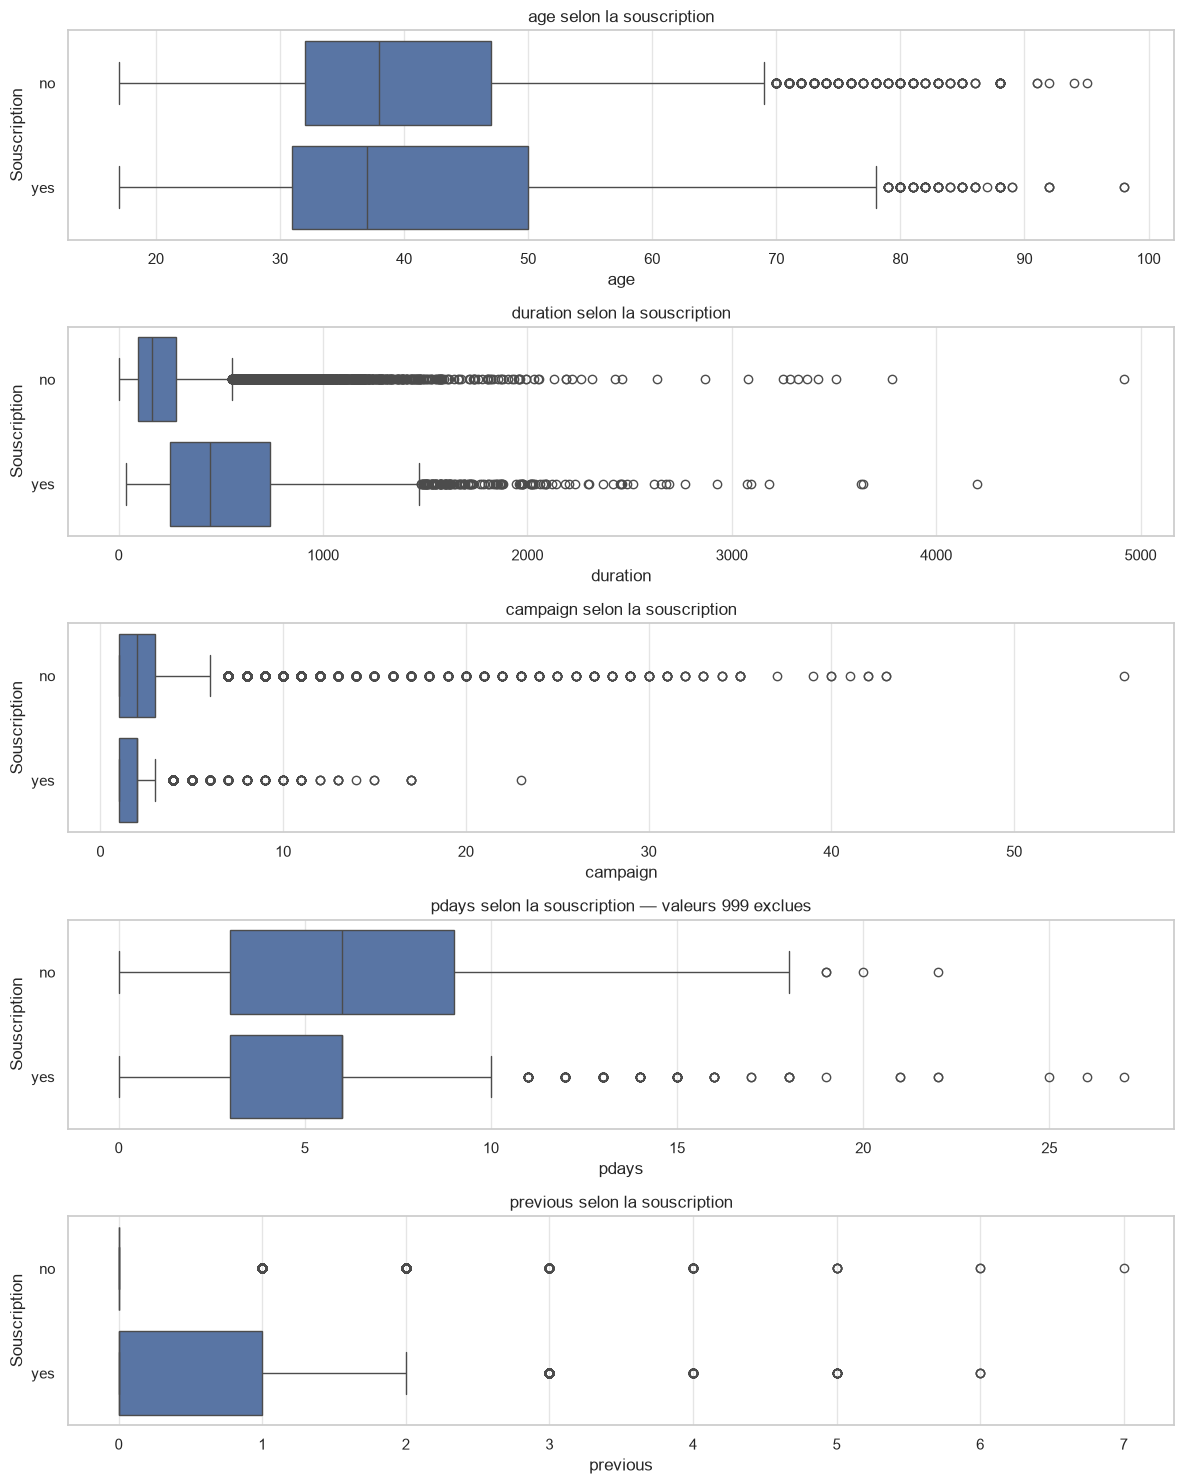

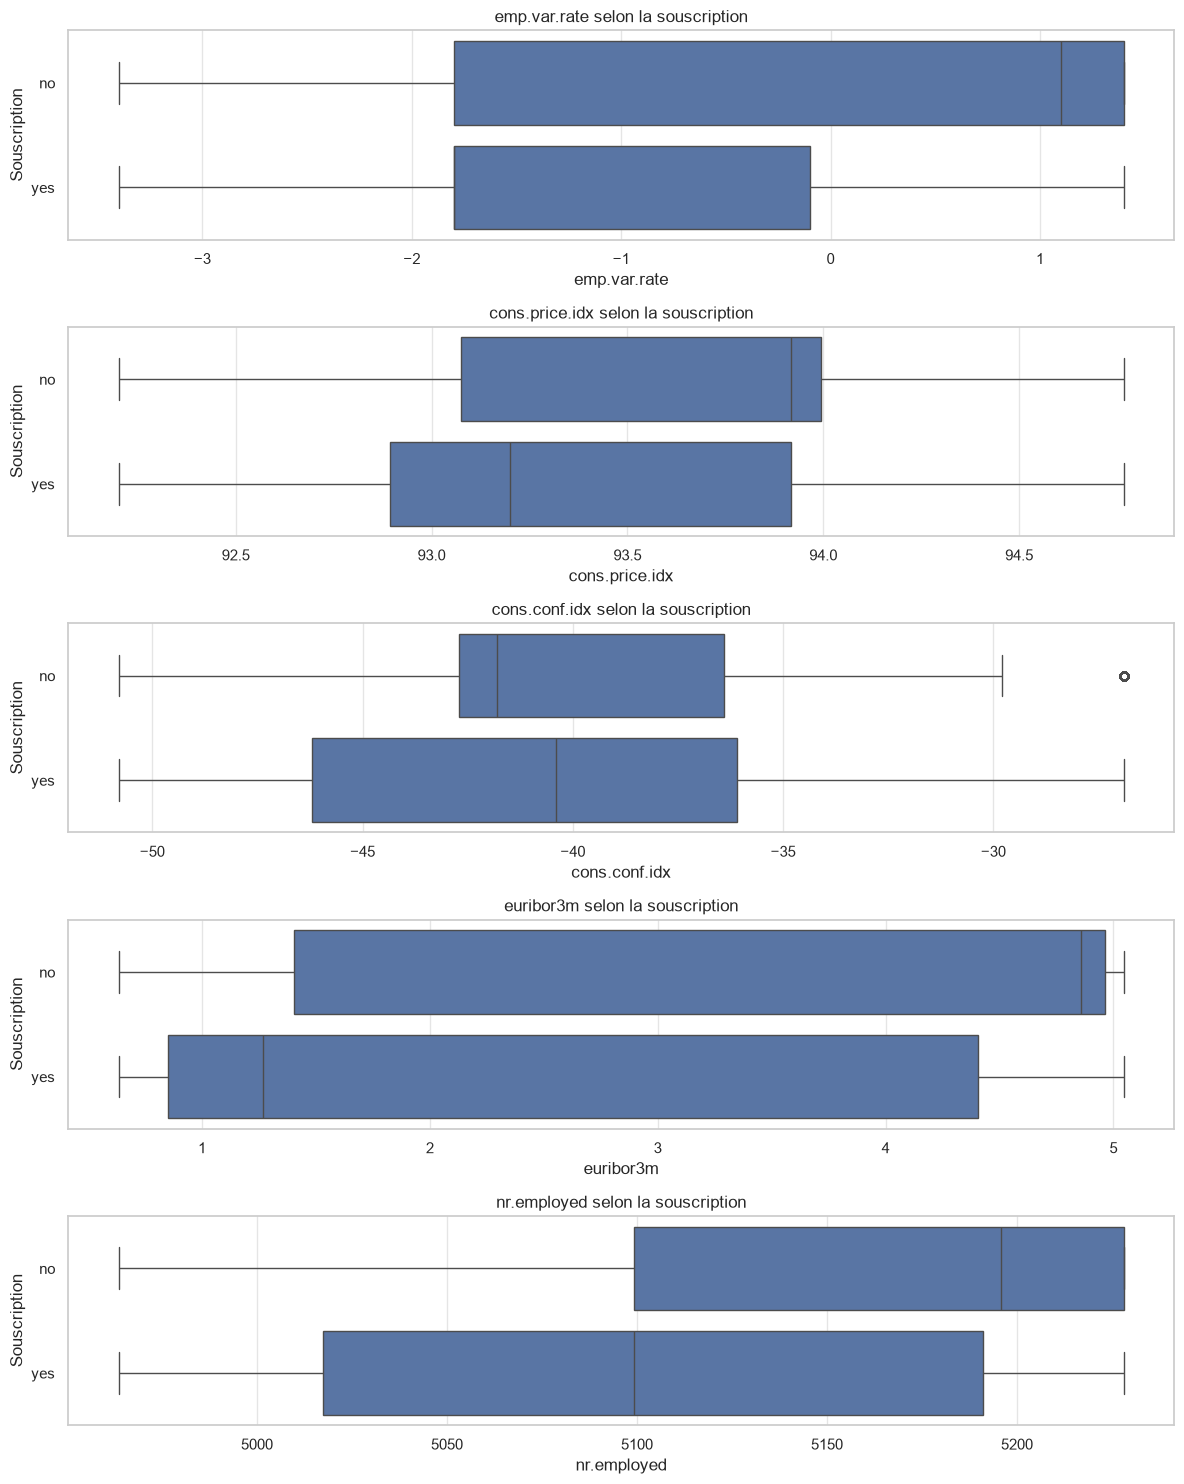

In [19]:
## VARIABLES NUMÉRIQUES SELON LA CIBLE
# Distribution des variables numériques selon la souscription.
for debut in range(0, len(colonnes_num), 5):
    groupe = colonnes_num[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 3 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        ax = axes[ligne, 0]
        sns.boxplot(data=donnees_relations, x=variable, y="y", order=["no", "yes"], ax=ax)
        titre = f"{variable} selon la souscription"
        if variable == "pdays":
            titre += " — valeurs 999 exclues"
        ax.set_title(titre)
        ax.set_ylabel("Souscription")
    fig.tight_layout()
    plt.show()

# age : les médianes sont proches (38 et 37 ans), mais les souscripteurs sont plus dispersés et comptent davantage de clients de plus de 60 ans, cohérent avec le taux élevé des 65 ans et plus.
# duration : les appels suivis d’une souscription sont nettement plus longs (médiane 449 s contre 164 s), ce qui confirme la fuite d’information déjà relevée.
# campaign : les souscripteurs ont été contactés moins souvent pendant la campagne ; au-delà de quelques appels, les souscriptions deviennent rares.
# pdays : hors code 999, les souscripteurs ont été recontactés dans un délai plus court et plus resserré, avec une médiane identique de 6 jours.
# previous : 32 % des souscripteurs ont eu au moins un contact antérieur, contre 11 % des non-souscripteurs.
# emp.var.rate, cons.price.idx, euribor3m et nr.employed : les souscriptions se concentrent sur les périodes de taux bas et d’emploi en recul, comme sur la matrice de corrélation.
# cons.conf.idx : les deux distributions se chevauchent largement, avec des médianes proches (−41,8 et −40,4) ; son apport propre reste à vérifier.


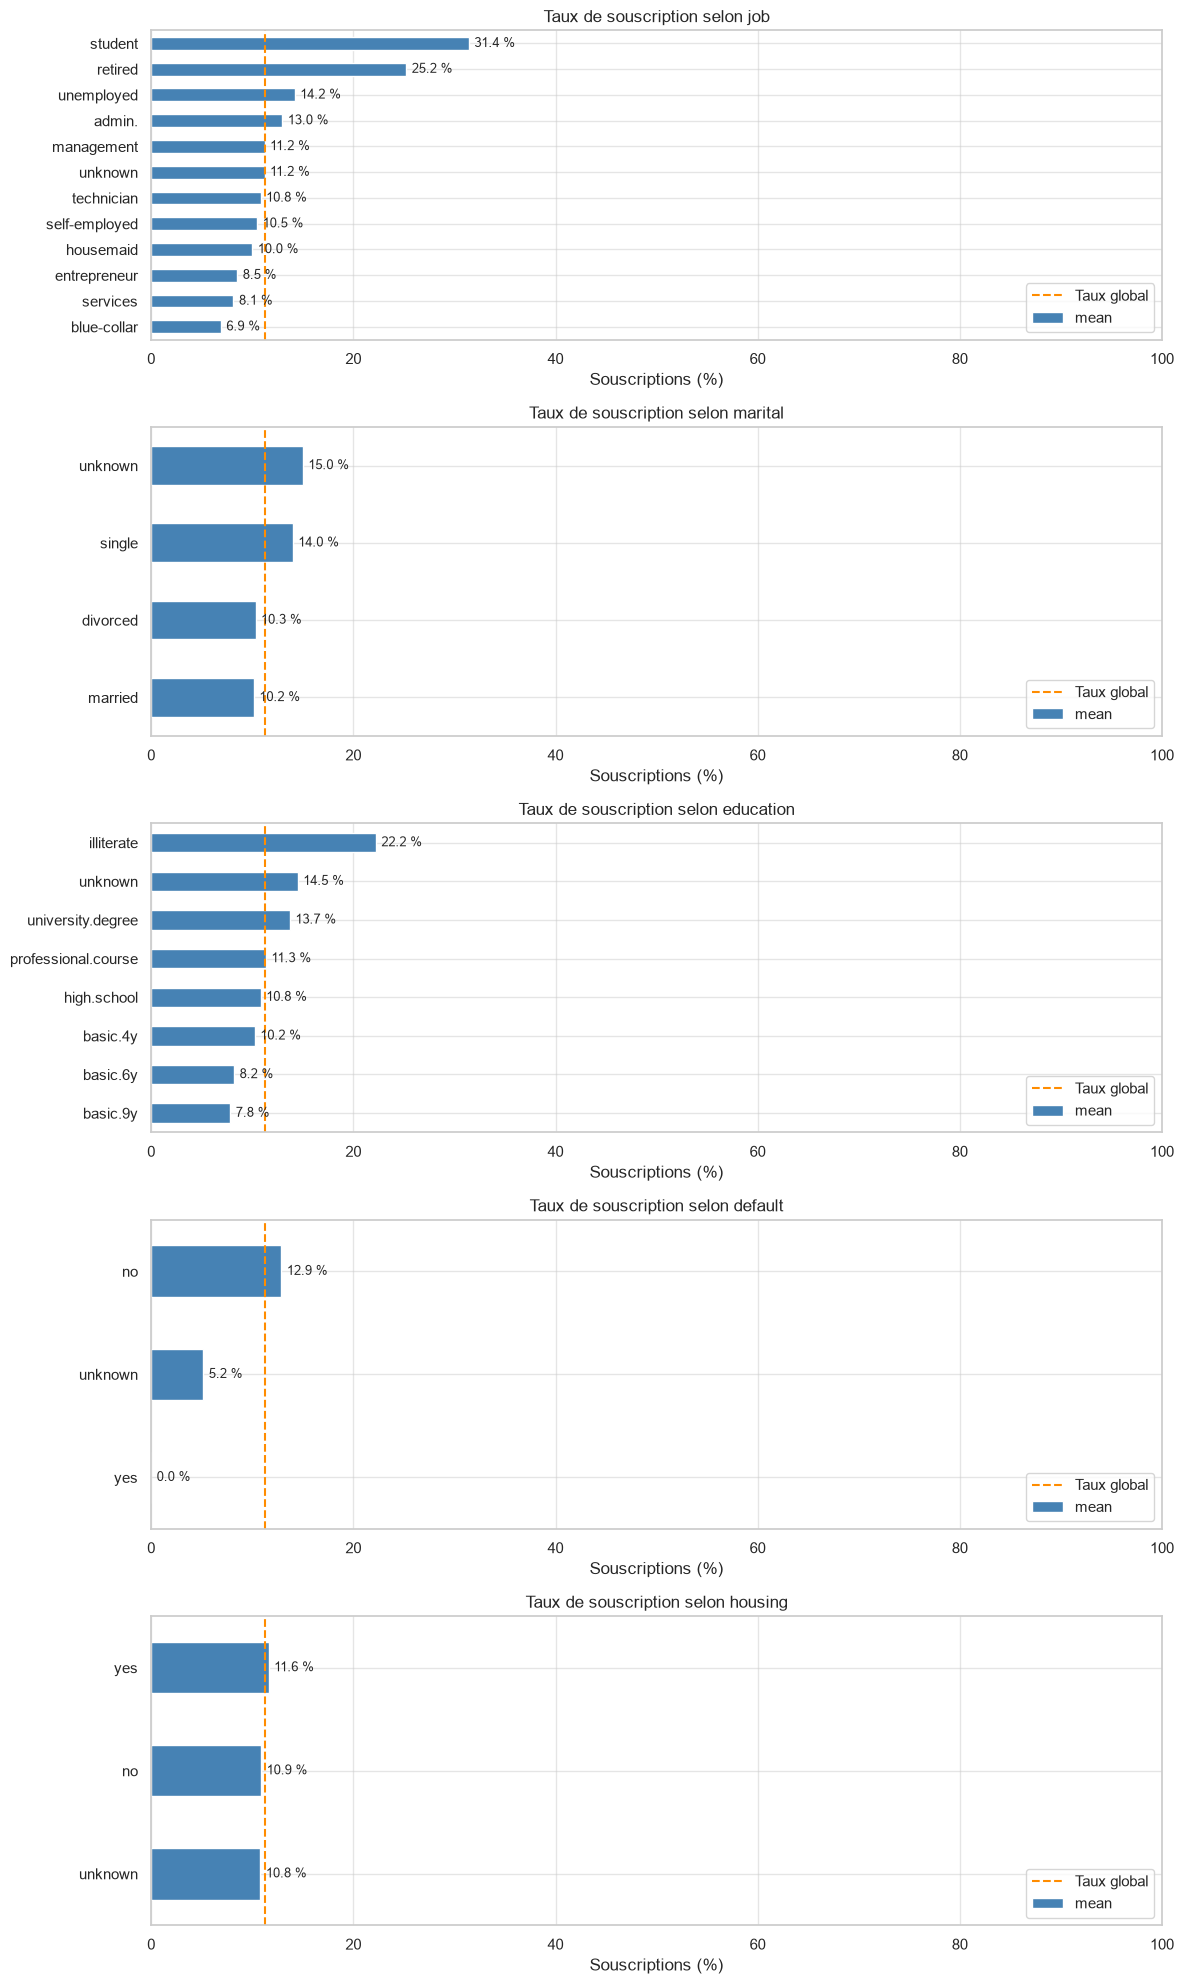

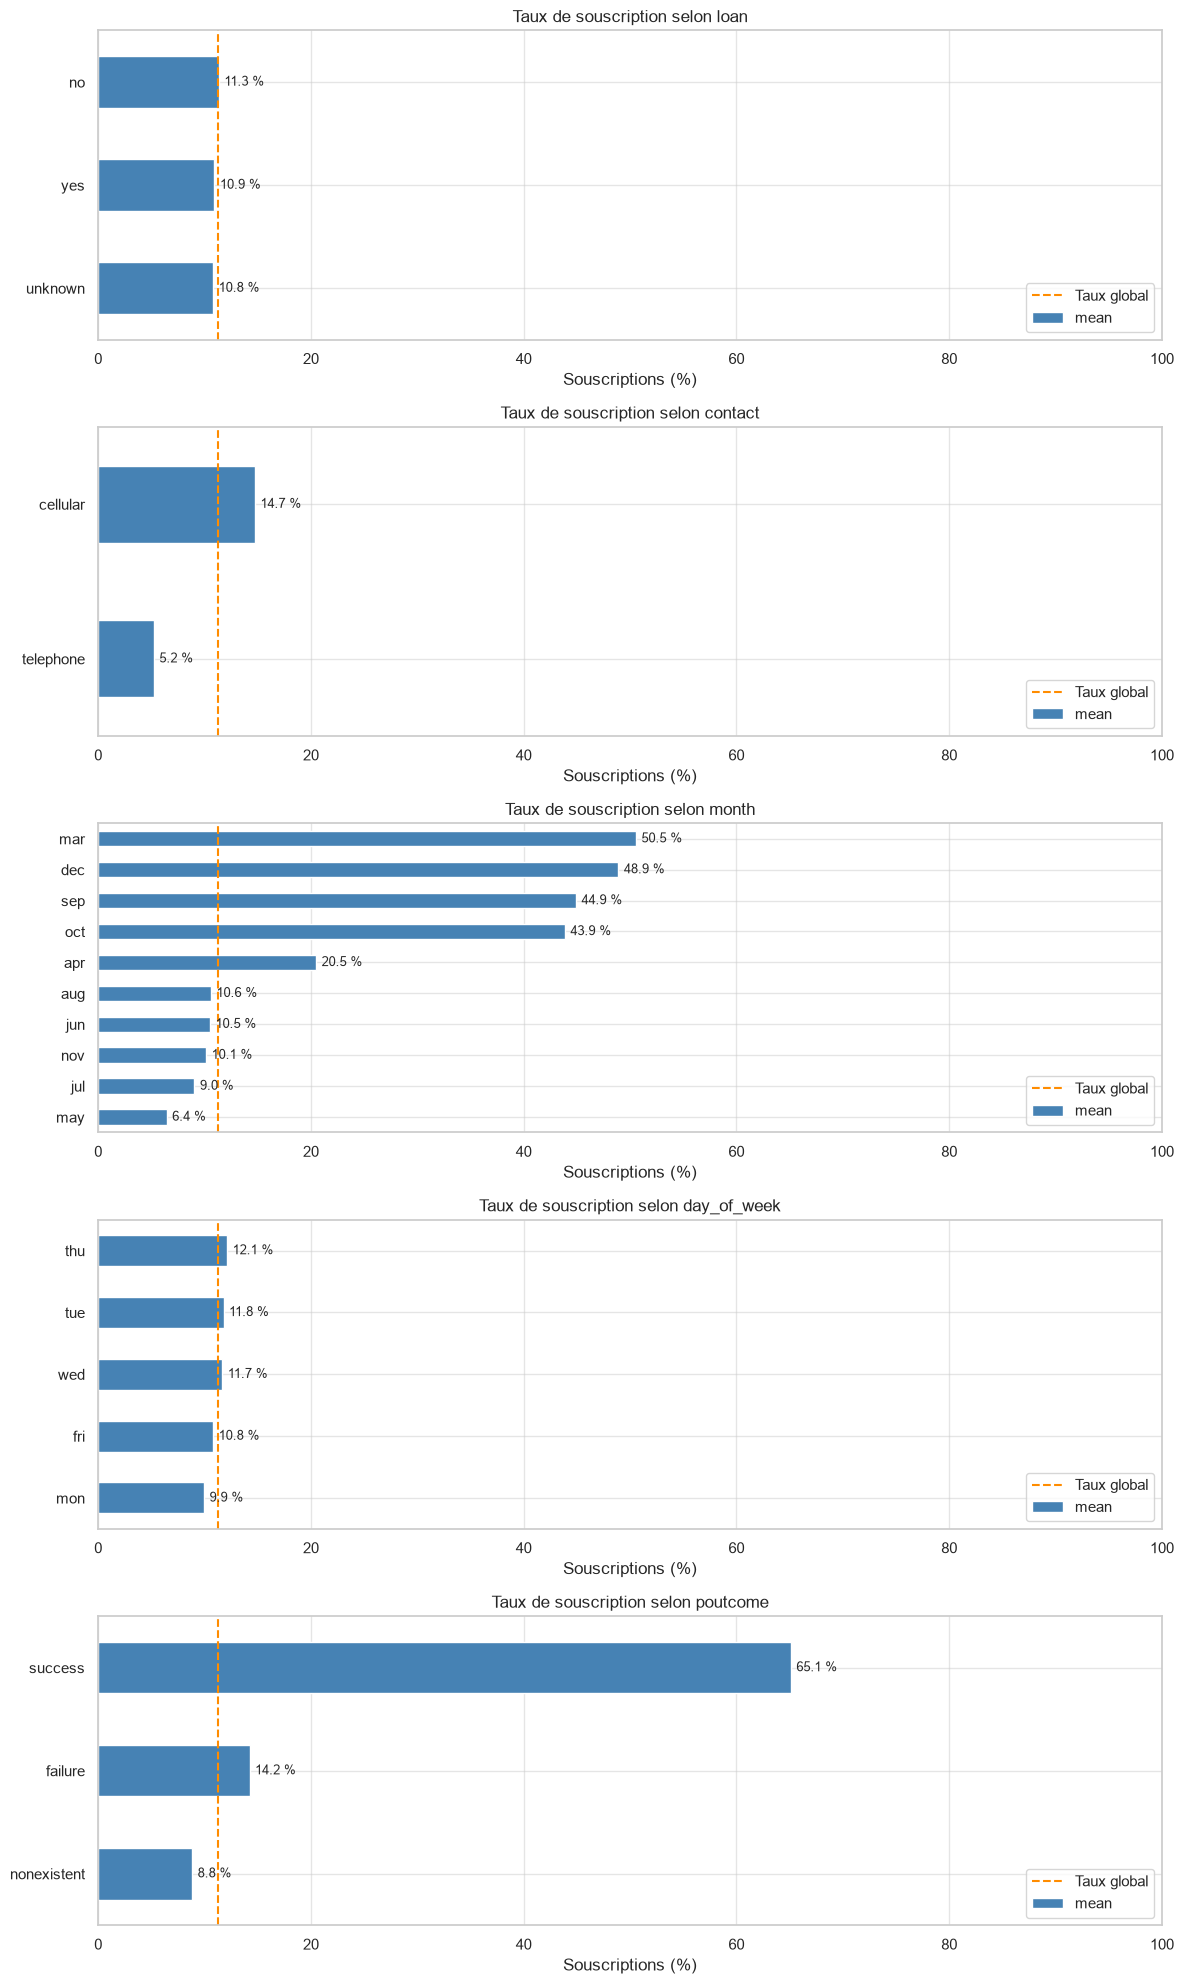

In [20]:
## TAUX DE SOUSCRIPTION PAR MODALITÉ

for debut in range(0, len(colonnes_cat), 5):
    groupe = colonnes_cat[debut:debut + 5]
    fig, axes = plt.subplots(len(groupe), 1, figsize=(12, 4 * len(groupe)), squeeze=False)
    for ligne, variable in enumerate(groupe):
        tableau = donnees_relations.groupby(variable, dropna=False)["y_oui"].agg(["mean", "size"])
        tableau = tableau.sort_values("mean")
        ax = axes[ligne, 0]
        (tableau["mean"] * 100).plot.barh(ax=ax, color="steelblue")
        ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange",
                   linestyle="--", label="Taux global")
        ax.bar_label(ax.containers[0],
                     labels=[f"{taux * 100:.1f} %" for taux in tableau["mean"]],
                     padding=4, fontsize=9)
        ax.set_title(f"Taux de souscription selon {variable}")
        ax.set_xlabel("Souscriptions (%)")
        ax.set_ylabel("")
        ax.set_xlim(0, 100)
        ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

# job : les étudiants (31,4 %) et les retraités (25,2 %) souscrivent le plus, cohérent avec les taux élevés des moins de 25 ans et des 65 ans et plus ; les ouvriers (blue-collar) souscrivent le moins (6,9 %).
# marital : les célibataires souscrivent un peu plus (14,0 %) que les mariés et les divorcés (environ 10 %) ; l’écart recoupe en partie celui de l’âge.
# education : les écarts restent modérés, de 7,8 % (basic.9y) à 13,7 % (university.degree) ; le taux de illiterate (22,2 %) repose sur 18 clients seulement.
# default : les clients au statut unknown souscrivent nettement moins (5,2 %) que les clients sans défaut (12,9 %) ; unknown porte une information et sera gardé comme modalité à part.
# default : la modalité yes ne compte que 3 clients, trop peu pour être exploitée seule.
# housing et loan : les taux restent proches du taux global (10,8 % à 11,6 %) ; ces deux variables semblent peu discriminantes.
# contact : les clients joints sur mobile souscrivent près de trois fois plus (14,7 %) que sur téléphone fixe (5,2 %).
# month : mai concentre le plus d’appels pour le taux le plus bas (6,4 %), tandis que mars, septembre, octobre et décembre dépassent 43 % sur de faibles effectifs ; le mois reflète la période de campagne.
# day_of_week : les taux varient peu selon le jour (9,9 % à 12,1 %) ; cette variable semble peu discriminante.
# poutcome : un succès lors d’une campagne précédente donne le taux le plus élevé (65,1 %), contre 14,2 % après un échec et 8,8 % sans campagne précédente.


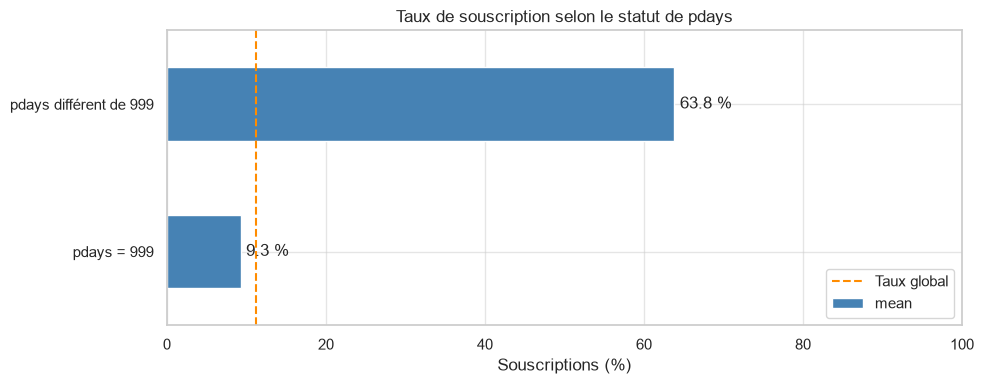

In [21]:
## CROISEMENT DE PDAYS AVEC LA CIBLE
# Croisement spécifique du code 999 de pdays avec la cible.
statut_pdays = df["pdays"].eq(999).map({True: "pdays = 999", False: "pdays différent de 999"})
taux_pdays = donnees_relations.groupby(statut_pdays)["y_oui"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(10, 4))
(taux_pdays["mean"] * 100).plot.barh(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0],
             labels=[f"{taux * 100:.1f} %" for taux in taux_pdays["mean"]], padding=4)
ax.axvline(donnees_relations["y_oui"].mean() * 100, color="darkorange",
           linestyle="--", label="Taux global")
ax.set_title("Taux de souscription selon le statut de pdays")
ax.set_xlabel("Souscriptions (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Les clients recontactés après une campagne précédente (pdays différent de 999) souscrivent à 63,8 %, contre 9,3 % pour les clients jamais recontactés.
# Le code 999 porte donc une information forte sur la cible, mais pdays est incohérent avec previous sur 4 110 lignes : pdays est retiré au profit de previous et poutcome.


### 3.6 Analyse des biais & variables sensibles

Démarche :  
1. Recenser les variables sensibles et leurs effectifs.  
2. Calculer le taux de souscription par groupe et le disparate impact (DI).  
3. Croiser deux variables sensibles pour repérer les écarts cachés.  
4. Rechercher les variables proxies des variables sensibles.

Issue mesurée : la souscription historique (`y = yes`).  
Aucun modèle n’existe encore : ces DI décrivent les étiquettes historiques que le modèle apprendra.  
Seuil d’alerte : DI < 0.80. Les groupes de moins de 30 clients sont signalés comme fragiles.

In [22]:
## 3.6.1 VARIABLES SENSIBLES : MODALITÉS ET EFFECTIFS

# Les variables sensibles retenues sont : age, job, marital, education

# Choix des tranches d’âge, car c'est une variable numérique :
# moins de 25 ans, 25–34 ans, 35–44 ans, 45–54 ans, 55–64 ans, 65 ans et plus

groupes_sensibles = pd.DataFrame({
    "age": tranches_age,
    "job": df["job"],
    "marital": df["marital"],
    "education": df["education"],
})
for variable in groupes_sensibles:
    effectifs = groupes_sensibles[variable].value_counts()
    print(f"{variable} : {effectifs.to_dict()}")

# age : 663 clients de 65 ans et plus et 1 068 de moins de 25 ans, les autres tranches dépassent 3 500 clients.
# job : 330 unknown ; toutes les modalités dépassent 800 clients.
# marital : 80 unknown, effectif faible mais supérieur à 30.
# education : illiterate ne compte que 18 clients, trop peu pour un taux fiable.

age : {'25–34': 13686, '35–44': 13500, '45–54': 8704, '55–64': 3567, 'Moins de 25': 1068, '65 et plus': 663}
job : {'admin.': 10422, 'blue-collar': 9254, 'technician': 6743, 'services': 3969, 'management': 2924, 'retired': 1720, 'entrepreneur': 1456, 'self-employed': 1421, 'housemaid': 1060, 'unemployed': 1014, 'student': 875, 'unknown': 330}
marital : {'married': 24928, 'single': 11568, 'divorced': 4612, 'unknown': 80}
education : {'university.degree': 12168, 'high.school': 9515, 'basic.9y': 6045, 'professional.course': 5243, 'basic.4y': 4176, 'basic.6y': 2292, 'unknown': 1731, 'illiterate': 18}


In [23]:
## 3.6.2 TAUX DE SOUSCRIPTION ET DISPARATE IMPACT PAR VARIABLE

# Il s'agit d’examiner si un groupe est « systématiquement moins sollicité ou moins bien servi par le modèle »

# Nous considérons donc la souscription comme une issue favorable pour le client.
# Ce choix repose sur l’hypothèse que le dépôt à terme répond à ses besoins et lui permet de rémunérer son épargne.
# Un groupe qui souscrit moins est donc considéré comme potentiellement lésé dans l’accès à cette possibilité d’épargne.


# DI (disparate impact) = taux du groupe / taux du groupe le plus avantagé (taux de souscription le plus élevé).
# La référence est choisie hors unknown et hors groupes de moins de 30 clients.

SEUIL_DI = 0.8
EFFECTIF_MIN = 30

def taux_par_groupe(groupes):
    tableau = donnees_relations["y_oui"].groupby(groupes, observed=True).agg(taux="mean", effectif="size")
    fiables = tableau.loc[(tableau["effectif"] >= EFFECTIF_MIN) & ~tableau.index.astype(str).str.contains("unknown")]
    reference = fiables["taux"].idxmax()
    tableau["DI_vs_ref"] = tableau["taux"] / tableau.loc[reference, "taux"]
    tableau["fragile"] = tableau["effectif"] < EFFECTIF_MIN
    return tableau, reference

resultats_di = {}
for variable in groupes_sensibles:
    tableau, reference = taux_par_groupe(groupes_sensibles[variable])
    resultats_di[variable] = tableau
    print(f"\n{variable} — référence : {reference} (taux : {tableau.loc[reference, 'taux']:.1%})")
    print(tableau.round(3).to_string())

# age : référence 65 ans et plus ; les 35–44 et 45–54 ans ont les DI les plus faibles (0.18).
# job : référence student ; blue-collar (0.22), services (0.26) et entrepreneur (0.27) ont les DI les plus faibles.
# education : référence university.degree ; basic.9y a le DI le plus faible (0.57) ; les niveaux basic et high.school sont sous 0.80.
# marital : référence single ; married (0.73) et divorced (0.74) sont sous 0.80.

# Les quatre variables ont des catégories qui passent sous le seuil de 0.80
# Chacune justifie une vérification sur les prédictions du modèle.


age — référence : 65 et plus (taux : 47.2%)
              taux  effectif  DI_vs_ref  fragile
age                                             
Moins de 25  0.240      1068      0.508    False
25–34        0.122     13686      0.258    False
35–44        0.087     13500      0.183    False
45–54        0.087      8704      0.183    False
55–64        0.136      3567      0.287    False
65 et plus   0.472       663      1.000    False

job — référence : student (taux : 31.4%)
                taux  effectif  DI_vs_ref  fragile
job                                               
admin.         0.130     10422      0.413    False
blue-collar    0.069      9254      0.219    False
entrepreneur   0.085      1456      0.271    False
housemaid      0.100      1060      0.318    False
management     0.112      2924      0.357    False
retired        0.252      1720      0.803    False
self-employed  0.105      1421      0.334    False
services       0.081      3969      0.259    False
student    

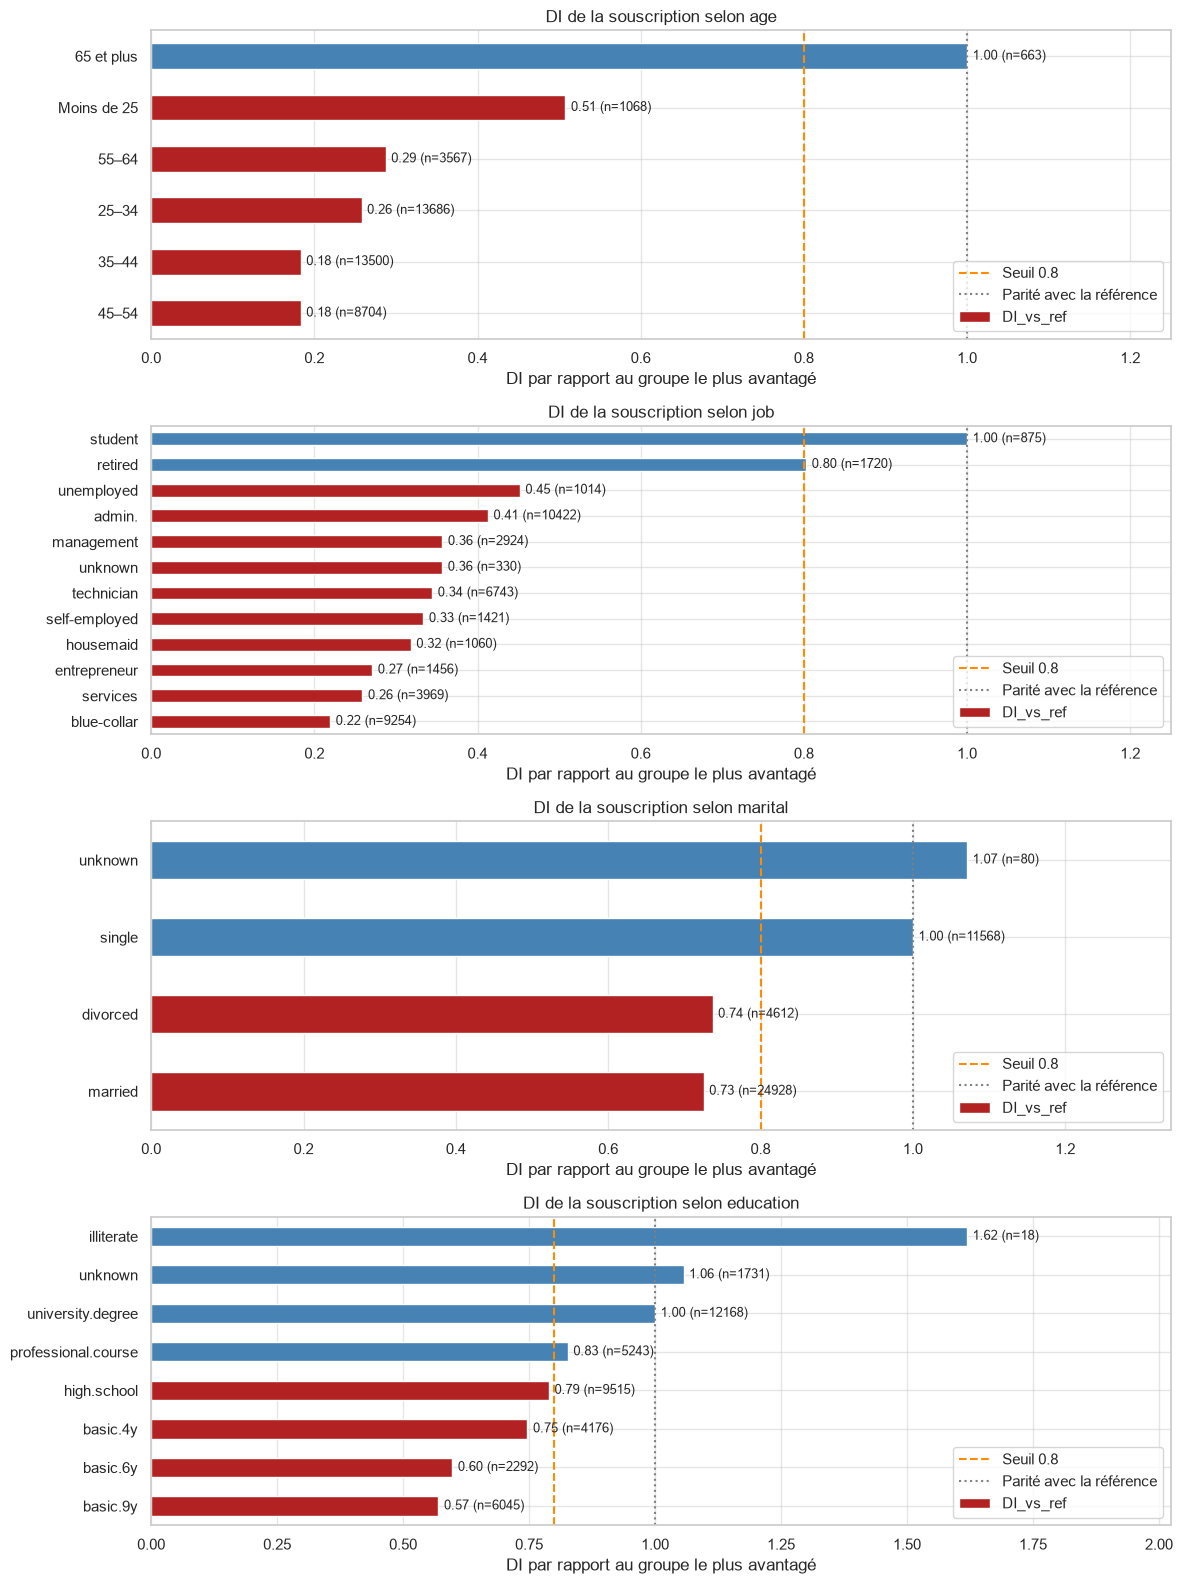

In [24]:
## GRAPHIQUE DES DI
fig, axes = plt.subplots(len(resultats_di), 1, figsize=(12, 4 * len(resultats_di)))
for ax, (variable, tableau) in zip(axes, resultats_di.items()):
    tableau = tableau.sort_values("DI_vs_ref")
    couleurs = np.where(tableau["DI_vs_ref"] < SEUIL_DI, "firebrick", "steelblue")
    tableau["DI_vs_ref"].plot.barh(ax=ax, color=couleurs)
    ax.bar_label(ax.containers[0],
                 labels=[f"{di:.2f} (n={n})" for di, n in zip(tableau["DI_vs_ref"], tableau["effectif"])],
                 padding=4, fontsize=9)
    ax.axvline(SEUIL_DI, color="darkorange", linestyle="--", label=f"Seuil {SEUIL_DI}")
    ax.axvline(1, color="grey", linestyle=":", label="Parité avec la référence")
    ax.set(title=f"DI de la souscription selon {variable}", xlabel="DI par rapport au groupe le plus avantagé", ylabel="",
           xlim=(0, tableau["DI_vs_ref"].max() * 1.25))
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# En rouge, sous le seuil :
# - toutes les tranches de moins de 65 ans
# - toutes les professions, hors student et retired
# - married et divorced
# - les niveaux d'éducation basic et high.school.

# Illiterate et unknown figurent sur le graphique mais sont exclus du choix de la référence : ils sont à interpréter séparément.

In [25]:
## 3.6.3  INTERSECTION

# On analyse ici si certains clients sont doublement lésés
# en raison de l'appartenance à deux catégories lésées.

# On compare les taux de souscription de l'intersection et de chacun de ses deux groupes.
# Les DI ne se comparent pas d'un tableau à l'autre : chaque tableau a sa propre référence.

# On va analyser trois croisements qui possèdent des effectifs suffisants dans les groupes croisés.

Référence du DI de l’intersection : 65 et plus × basic.4y
                       effectif  souscriptions  taux_age_seul  taux_education_seul  taux_intersection  DI_vs_ref  plus_faible_que_les_deux
55–64 × basic.6y            135              4          0.136                0.082              0.030      0.058                      True
35–44 × basic.4y           1105             47          0.087                0.102              0.043      0.084                      True
45–54 × basic.4y           1350             74          0.087                0.102              0.055      0.108                      True
35–44 × basic.9y           2047            120          0.087                0.078              0.059      0.116                      True
25–34 × basic.4y            554             33          0.122                0.102              0.060      0.118                      True
65 et plus × basic.4y       308            156          0.472                0.102              0.506      1

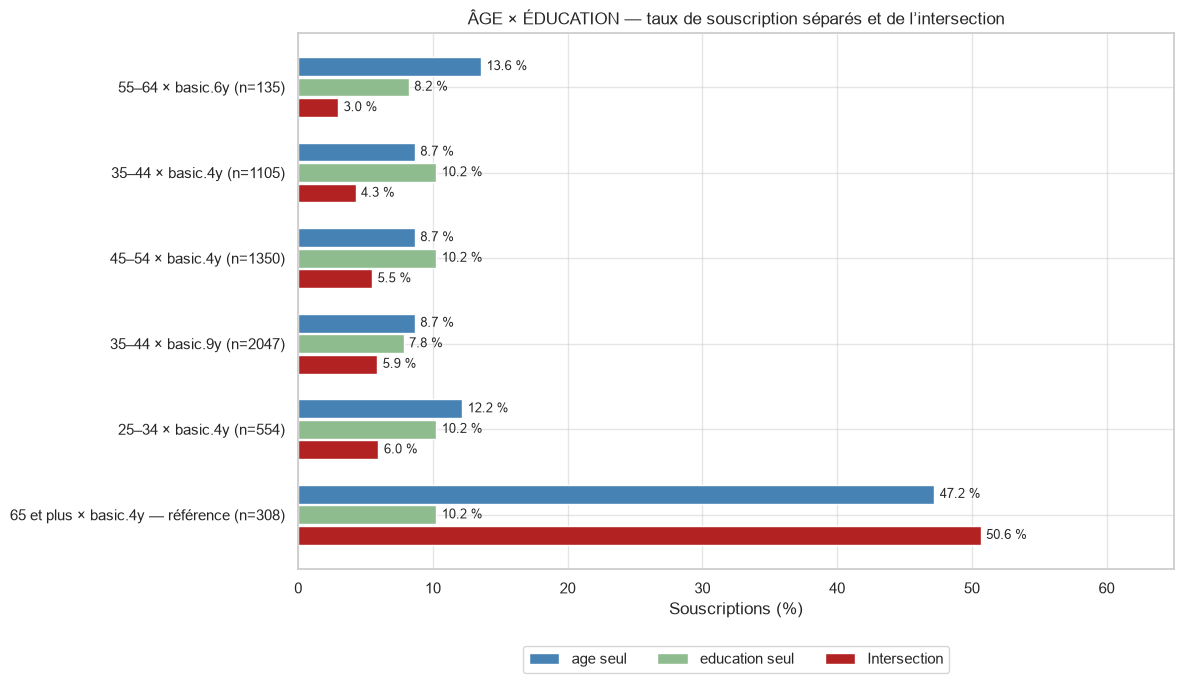

In [26]:
## INTERSECTION ÂGE × ÉDUCATION

groupes_croises = groupes_sensibles["age"].astype(str) + " × " + groupes_sensibles["education"].astype(str)
tableau_croise, reference_croise = taux_par_groupe(groupes_croises)
tableau_croise["souscriptions"] = donnees_relations["y_oui"].groupby(groupes_croises).sum()
fiables_croise = tableau_croise.loc[~tableau_croise["fragile"] & ~tableau_croise.index.str.contains("unknown")]
comparaison = pd.concat([fiables_croise.nsmallest(5, "DI_vs_ref"), tableau_croise.loc[[reference_croise]]]).copy()
modalites = comparaison.index.str.split(" × ")
comparaison["taux_age_seul"] = [resultats_di["age"].loc[m[0], "taux"] for m in modalites]
comparaison["taux_education_seul"] = [resultats_di["education"].loc[m[1], "taux"] for m in modalites]
comparaison["taux_intersection"] = comparaison["taux"]
comparaison["plus_faible_que_les_deux"] = comparaison["taux_intersection"] < comparaison[["taux_age_seul", "taux_education_seul"]].min(axis=1)
print(f"Référence du DI de l’intersection : {reference_croise}")
print(comparaison[["effectif", "souscriptions", "taux_age_seul", "taux_education_seul", "taux_intersection", "DI_vs_ref", "plus_faible_que_les_deux"]].round(3).to_string())

positions = np.arange(len(comparaison))
fig, ax = plt.subplots(figsize=(12, 7))
for decalage, colonne, legende, couleur in [
    (-0.24, "taux_age_seul", "age seul", "steelblue"),
    (0, "taux_education_seul", "education seul", "darkseagreen"),
    (0.24, "taux_intersection", "Intersection", "firebrick"),
]:
    barres = ax.barh(positions + decalage, comparaison[colonne] * 100, height=0.22, label=legende, color=couleur)
    ax.bar_label(barres, fmt="{:.1f} %", padding=4, fontsize=9)
ax.set_yticks(positions, [f"{g}{' — référence' if g == reference_croise else ''} (n={effectif})" for g, effectif in zip(comparaison.index, comparaison["effectif"])])
ax.invert_yaxis()
ax.set(title="ÂGE × ÉDUCATION — taux de souscription séparés et de l’intersection", xlabel="Souscriptions (%)", xlim=(0, 65))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
fig.tight_layout()
plt.show()

# Référence du DI : 65 ans et plus × basic.4y, 50.6 % de souscriptions pour 308 clients.

# Les cinq intersections affichées souscrivent moins que chacun de leurs deux groupes.
# Les 35–44 × basic.4y souscrivent à 4.3 % (47 souscriptions sur 1 105 clients), contre 8.7 % pour les 35–44 ans et 10.2 % pour basic.4y.
# Les 45–54 × basic.4y souscrivent à 5.5 % et les 25–34 × basic.4y à 6.0 %, contre 8.7 % et 12.2 % pour leur tranche d’âge.
# Les 55–64 × basic.6y ont le taux le plus bas (3.0 %), mais il repose sur 4 souscriptions : ce taux est fragile.

# Le croisement avec l’éducation révèle des sous-groupes plus désavantagés que l’âge seul, surtout au niveau basic.4y.

Référence du DI de l’intersection : 65 et plus × divorced
                       effectif  souscriptions  taux_age_seul  taux_marital_seul  taux_intersection  DI_vs_ref  plus_faible_que_les_deux
45–54 × divorced           1459            112          0.087              0.103              0.077      0.154                      True
25–34 × divorced            776             64          0.122              0.103              0.082      0.166                      True
35–44 × married            8884            734          0.087              0.102              0.083      0.166                      True
45–54 × married            6474            562          0.087              0.102              0.087      0.175                     False
Moins de 25 × married       133             12          0.240              0.102              0.090      0.182                      True
65 et plus × divorced       163             81          0.472              0.103              0.497      1.000          

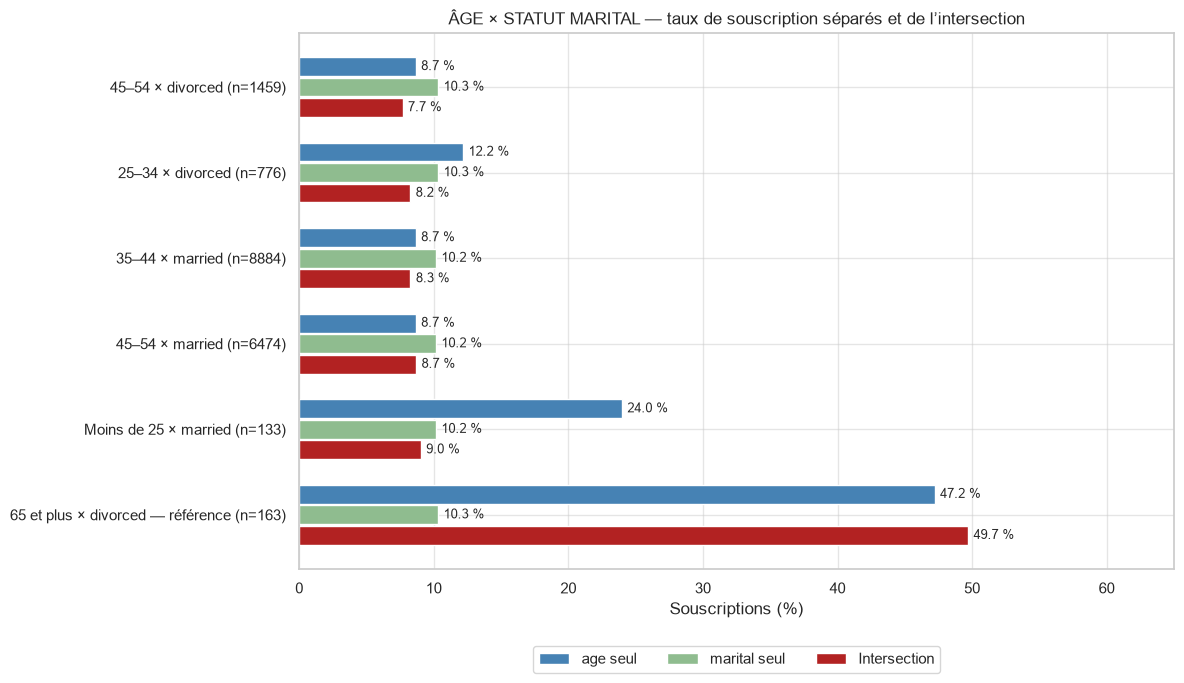

In [27]:
## INTERSECTION ÂGE × STATUT MARITAL

groupes_croises = groupes_sensibles["age"].astype(str) + " × " + groupes_sensibles["marital"].astype(str)
tableau_croise, reference_croise = taux_par_groupe(groupes_croises)
tableau_croise["souscriptions"] = donnees_relations["y_oui"].groupby(groupes_croises).sum()
fiables_croise = tableau_croise.loc[~tableau_croise["fragile"] & ~tableau_croise.index.str.contains("unknown")]
comparaison = pd.concat([fiables_croise.nsmallest(5, "DI_vs_ref"), tableau_croise.loc[[reference_croise]]]).copy()
modalites = comparaison.index.str.split(" × ")
comparaison["taux_age_seul"] = [resultats_di["age"].loc[m[0], "taux"] for m in modalites]
comparaison["taux_marital_seul"] = [resultats_di["marital"].loc[m[1], "taux"] for m in modalites]
comparaison["taux_intersection"] = comparaison["taux"]
comparaison["plus_faible_que_les_deux"] = comparaison["taux_intersection"] < comparaison[["taux_age_seul", "taux_marital_seul"]].min(axis=1)
print(f"Référence du DI de l’intersection : {reference_croise}")
print(comparaison[["effectif", "souscriptions", "taux_age_seul", "taux_marital_seul", "taux_intersection", "DI_vs_ref", "plus_faible_que_les_deux"]].round(3).to_string())

positions = np.arange(len(comparaison))
fig, ax = plt.subplots(figsize=(12, 7))
for decalage, colonne, legende, couleur in [
    (-0.24, "taux_age_seul", "age seul", "steelblue"),
    (0, "taux_marital_seul", "marital seul", "darkseagreen"),
    (0.24, "taux_intersection", "Intersection", "firebrick"),
]:
    barres = ax.barh(positions + decalage, comparaison[colonne] * 100, height=0.22, label=legende, color=couleur)
    ax.bar_label(barres, fmt="{:.1f} %", padding=4, fontsize=9)
ax.set_yticks(positions, [f"{g}{' — référence' if g == reference_croise else ''} (n={effectif})" for g, effectif in zip(comparaison.index, comparaison["effectif"])])
ax.invert_yaxis()
ax.set(title="ÂGE × STATUT MARITAL — taux de souscription séparés et de l’intersection", xlabel="Souscriptions (%)", xlim=(0, 65))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
fig.tight_layout()
plt.show()

# Référence du DI : 65 ans et plus × divorced, 49.7 % de souscriptions pour 163 clients (DI = 1).
# Les 25–34 × divorced souscrivent à 8.2 %, contre 12.2 % pour les 25–34 ans et 10.3 % pour divorced.
# Les moins de 25 × married souscrivent à 9.0 %, contre 24.0 % pour les moins de 25 ans ; l’écart est fort mais repose sur 12 souscriptions.
# Chez les 35–54 ans, le statut marital change peu le taux :
# - 45–54 × married : 8.7 %, comme les 45–54 ans seuls
# - 35–44 × married : 8.3 %, contre 8.7 % pour les 35–44 ans
# - 45–54 × divorced : 7.7 %, contre 8.7 % pour les 45–54 ans

# Le statut marital aggrave peu le désavantage lié à l’âge, sauf chez les moins de 35 ans.

Référence du DI de l’intersection : student × single
                         effectif  souscriptions  taux_job_seul  taux_marital_seul  taux_intersection  DI_vs_ref  plus_faible_que_les_deux
services × divorced           532             33          0.081              0.103              0.062      0.194                      True
blue-collar × married        6687            421          0.069              0.102              0.063      0.197                      True
services × married           2294            166          0.081              0.102              0.072      0.226                      True
blue-collar × divorced        728             53          0.069              0.103              0.073      0.227                     False
entrepreneur × divorced       179             14          0.085              0.103              0.078      0.244                      True
student × single              824            264          0.314              0.140              0.320      1.000 

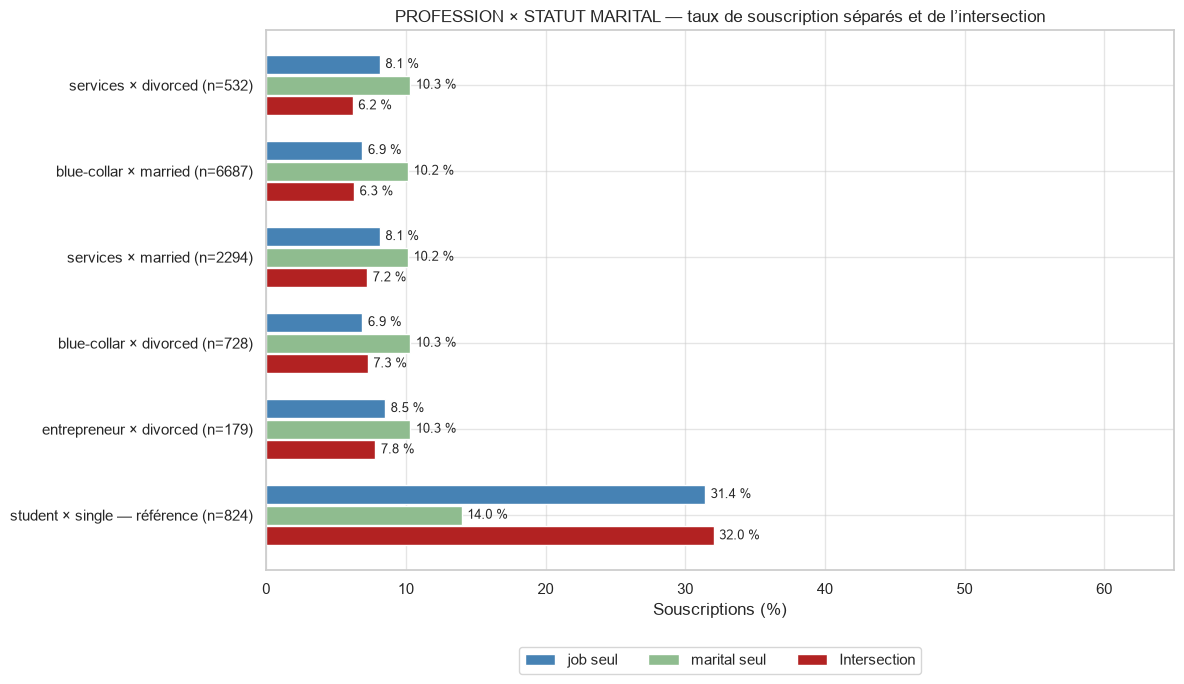

In [28]:
## INTERSECTION PROFESSION × STATUT MARITAL

groupes_croises = groupes_sensibles["job"].astype(str) + " × " + groupes_sensibles["marital"].astype(str)
tableau_croise, reference_croise = taux_par_groupe(groupes_croises)
tableau_croise["souscriptions"] = donnees_relations["y_oui"].groupby(groupes_croises).sum()
fiables_croise = tableau_croise.loc[~tableau_croise["fragile"] & ~tableau_croise.index.str.contains("unknown")]
comparaison = pd.concat([fiables_croise.nsmallest(5, "DI_vs_ref"), tableau_croise.loc[[reference_croise]]]).copy()
modalites = comparaison.index.str.split(" × ")
comparaison["taux_job_seul"] = [resultats_di["job"].loc[m[0], "taux"] for m in modalites]
comparaison["taux_marital_seul"] = [resultats_di["marital"].loc[m[1], "taux"] for m in modalites]
comparaison["taux_intersection"] = comparaison["taux"]
comparaison["plus_faible_que_les_deux"] = comparaison["taux_intersection"] < comparaison[["taux_job_seul", "taux_marital_seul"]].min(axis=1)
print(f"Référence du DI de l’intersection : {reference_croise}")
print(comparaison[["effectif", "souscriptions", "taux_job_seul", "taux_marital_seul", "taux_intersection", "DI_vs_ref", "plus_faible_que_les_deux"]].round(3).to_string())

positions = np.arange(len(comparaison))
fig, ax = plt.subplots(figsize=(12, 7))
for decalage, colonne, legende, couleur in [
    (-0.24, "taux_job_seul", "job seul", "steelblue"),
    (0, "taux_marital_seul", "marital seul", "darkseagreen"),
    (0.24, "taux_intersection", "Intersection", "firebrick"),
]:
    barres = ax.barh(positions + decalage, comparaison[colonne] * 100, height=0.22, label=legende, color=couleur)
    ax.bar_label(barres, fmt="{:.1f} %", padding=4, fontsize=9)
ax.set_yticks(positions, [f"{g}{' — référence' if g == reference_croise else ''} (n={effectif})" for g, effectif in zip(comparaison.index, comparaison["effectif"])])
ax.invert_yaxis()
ax.set(title="PROFESSION × STATUT MARITAL — taux de souscription séparés et de l’intersection", xlabel="Souscriptions (%)", xlim=(0, 65))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
fig.tight_layout()
plt.show()

# Référence du DI : student × single, 32.0 % de souscriptions pour 824 clients (DI = 1).
# Les services × divorced souscrivent à 6.2 %, contre 8.1 % pour services et 10.3 % pour divorced.
# Les blue-collar × married souscrivent à 6.3 %, contre 6.9 % pour blue-collar : l’écart reste faible.
# Les blue-collar × divorced souscrivent un peu plus que les blue-collar seuls (7.3 % contre 6.9 %).

# Le statut marital aggrave peu le désavantage lié à la profession.

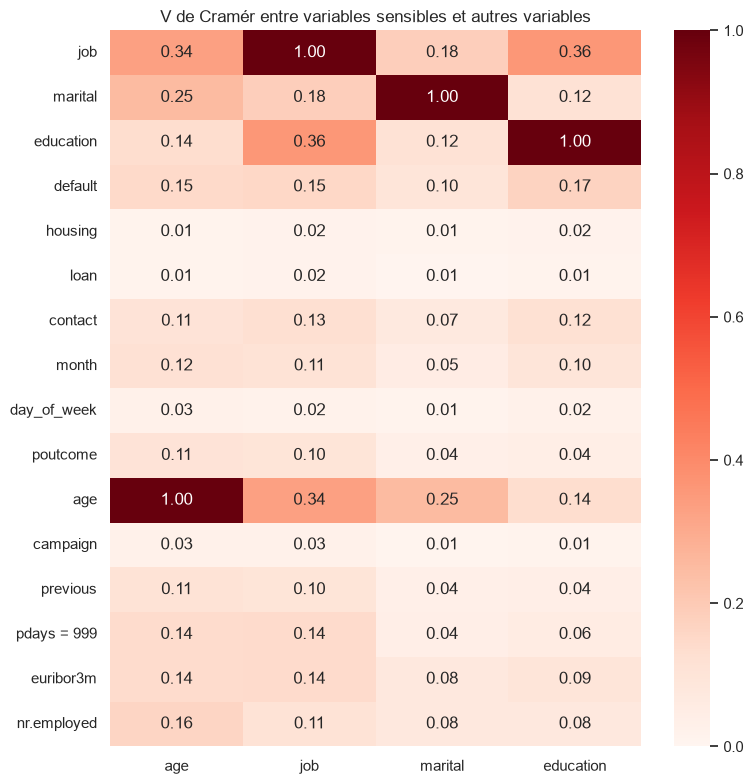

In [29]:
## 3.6.4 VARIABLES PROXIES

# Une variable proxy peut renseigner indirectement sur une autre variable
# Donc une variable sensible retirée des données peut réapparaitre sous la forme d'une autre variable liée qu'on appelle proxy

# Le V de Cramér mesure la force du lien entre deux variables catégorielles : il varie de 0 (aucun lien) à 1 (association parfaite).
# Calcul du V de Cramér entre chaque variable sensible et les autres variables, numériques découpées en classes.
from scipy.stats import chi2_contingency

def v_cramer(a, b):
    tableau = pd.crosstab(a, b)
    chi2 = chi2_contingency(tableau)[0]
    return np.sqrt(chi2 / (tableau.values.sum() * (min(tableau.shape) - 1)))

variables_candidates = {
    **{colonne: df[colonne] for colonne in colonnes_cat},
    "age": groupes_sensibles["age"],
    "campaign": pd.qcut(df["campaign"], 4, duplicates="drop"),
    "previous": df["previous"].clip(upper=2),
    "pdays = 999": df["pdays"].eq(999),
    "euribor3m": pd.qcut(df["euribor3m"], 5, duplicates="drop"),
    "nr.employed": df["nr.employed"],
}
matrice_proxies = pd.DataFrame({
    sensible: {nom: v_cramer(groupes_sensibles[sensible], valeurs)
               for nom, valeurs in variables_candidates.items()}
    for sensible in groupes_sensibles
})
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(matrice_proxies, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=ax)
ax.set_title("V de Cramér entre variables sensibles et autres variables")
fig.tight_layout()
plt.show()

# La profession renseigne en partie sur l’âge : les catégories étudiant et retraité donnent des indices sur l’âge du client (0.34).
# La profession est aussi liée au niveau d’éducation : la répartition des métiers varie selon le diplôme (0.36).
# Le statut marital renseigne un peu sur l’âge : les célibataires sont davantage représentés chez les jeunes (0.25).
# Les autres variables étudiées sont moins liées aux variables sensibles (0.18 au maximum, entre profession et statut marital).

# La profession et le statut marital sont donc des proxies possibles de l’âge
# la profession est aussi un proxy possible du niveau d’éducation.

# Retirer l’âge ne garantit pas que le modèle cessera de distinguer les profils selon l’âge
# car il conserve des indices dans la profession et le statut marital.

# Les variables non sensibles sont peu liées aux variables sensibles (0.17 au maximum, entre default et education).
# Retirer les quatre variables sensibles ensemble limite donc le risque qu'elles réapparaissent par un proxy.

### 3.6.5 CONCLUSION

Nous considérons la souscription comme favorable, sous l’hypothèse que le produit répond aux besoins du client.

Les DI font ressortir des **groupes potentiellement désavantagés**, pour chacune des variables sensibles, en particulier :
- les **adultes d’âge intermédiaire** (0.18)
- les **ouvriers** (0.22)
- les **personnes mariées** (0.73)
- les **clients au niveau d'éducation basic.9y** (0.57)

Les références (les groupes les plus favorisés) sont les seniors, les étudiants, les célibataires et les diplômés universitaires.

Les intersections, comparées sur les taux de souscription, donnent des résultats différents selon le croisement.
Le croisement de **l’âge et de l’éducation** révèle des **désavantages nettement plus marqués**, surtout au niveau basic.4y : les 35–44 ans de ce niveau souscrivent à 4.3 %, contre 8.7 % pour les 35–44 ans et 10.2 % pour basic.4y.
Le croisement de l’âge et du statut marital fait ressortir les **moins de 35 ans** : les 25–34 ans divorcés souscrivent à 8.2 % contre 12.2 % pour leur tranche d’âge, les moins de 25 ans mariés à 9.0 % contre 24.0 % (12 souscriptions seulement).
Pour les **autres croisements**, l’**intersection confirme surtout le désavantage déjà visible** avec l’âge ou la profession : les 45–54 ans mariés souscrivent à 8.7 % comme leur tranche d’âge, les ouvriers mariés à 6.3 % contre 6.9 % pour les ouvriers.

Concernant d'éventuelles variables proxies, la **profession est liée à l’âge et au niveau d’éducation** (V de Cramér : 0.34 et 0.36), et le **statut marital est lié à l’âge** (V de Cramér : 0.25). Retirer une variable sensible peut donc laisser une partie de son information dans les autres variables.

Pour la suite, nous comparerons un scénario conservant les variables sensibles et un scénario les retirant, en examinant les performances, les DI de sélection et le rappel par groupe.


age — référence : 45–54 (non-souscription : 91.3%)
             taux_non  effectif  fragile  DI_vs_ref
age                                                
65 et plus      0.528       663    False      0.578
Moins de 25     0.760      1068    False      0.832

job — référence : blue-collar (non-souscription : 93.1%)
         taux_non  effectif  fragile  DI_vs_ref
job                                            
student     0.686       875    False      0.736
retired     0.748      1720    False      0.803

marital — référence : married (non-souscription : 89.8%)
         taux_non  effectif  fragile  DI_vs_ref
marital                                        
unknown      0.85        80    False      0.946
single       0.86     11568    False      0.957

education — référence : basic.9y (non-souscription : 92.2%)
            taux_non  effectif  fragile  DI_vs_ref
education                                         
illiterate     0.778        18     True      0.844
unknown        0.855      

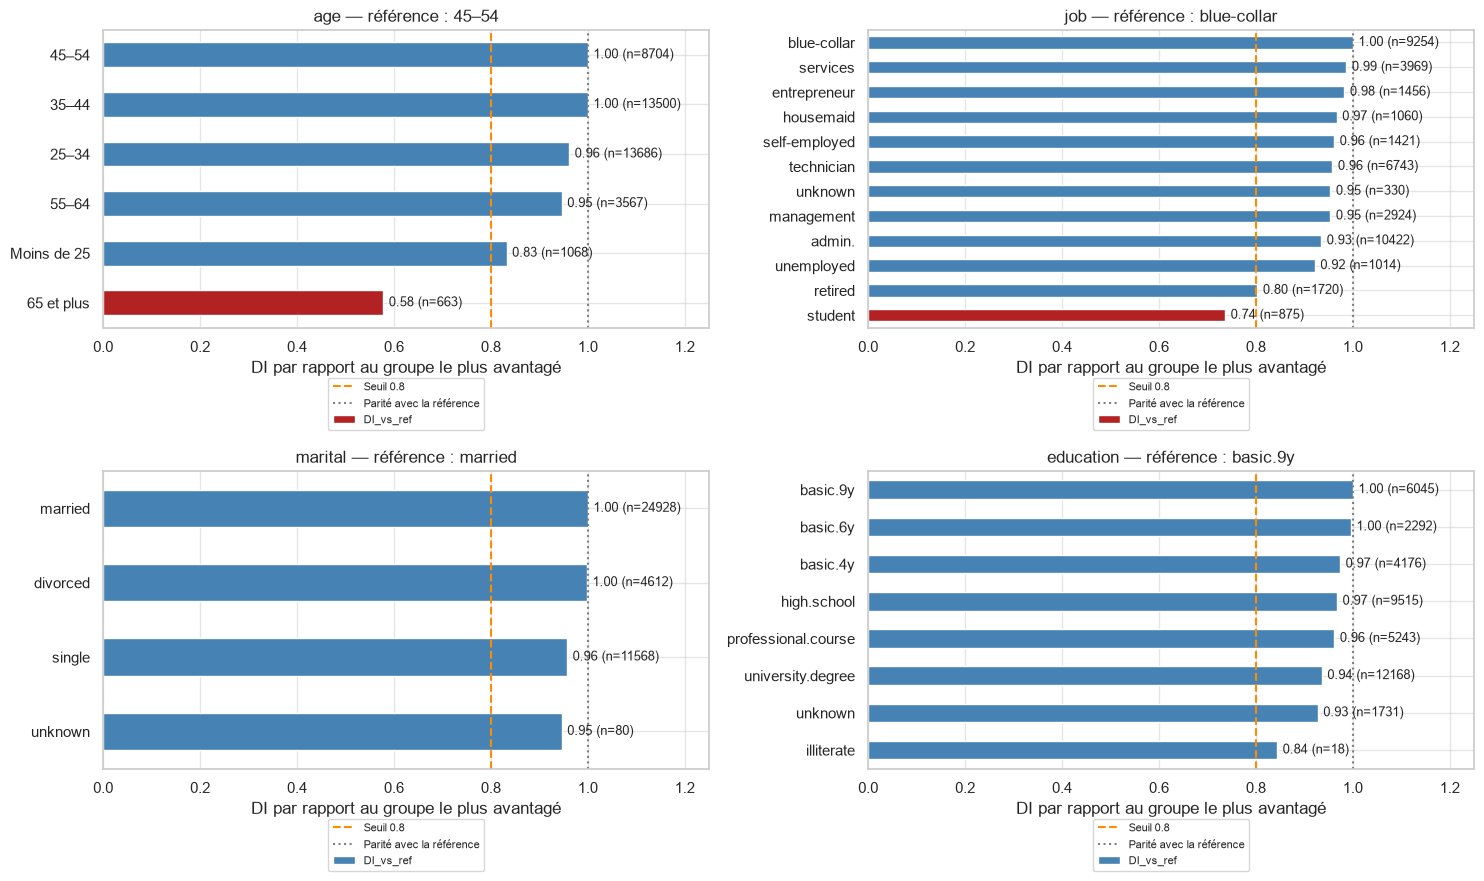

In [30]:
## ANALYSE COMPLÉMENTAIRE — ET SI SOUSCRIRE ÉTAIT DÉFAVORABLE ?
# Souscrire pourrait être défavorable si la pression commerciale pousse à acheter un produit dont le client n’a pas besoin.
# Les taux élevés chez les personnes âgées et illettrées motivent cette hypothèse de risque pour des publics potentiellement fragiles.
# Ces données ne permettent pas d’établir que le produit est inadapté ou que ces personnes ont été davantage ciblées.
# Nous prenons ici la non-souscription comme issue favorable et comparons chaque groupe au meilleur taux de non-souscription.
# La référence exclut unknown et les groupes de moins de 30 clients ; les tableaux affichent les deux DI les plus faibles par variable.

y_non = df["y"].eq("no").astype(int)
resultats_di_non = {}
references_di_non = {}
for variable in groupes_sensibles:
    tableau = y_non.groupby(groupes_sensibles[variable], observed=True).agg(taux_non="mean", effectif="size")
    tableau["fragile"] = tableau["effectif"] < EFFECTIF_MIN
    fiables = tableau.loc[~tableau["fragile"] & (tableau.index.astype(str) != "unknown")]
    reference = fiables["taux_non"].idxmax()
    tableau["DI_vs_ref"] = tableau["taux_non"] / tableau.loc[reference, "taux_non"]
    resultats_di_non[variable] = tableau
    references_di_non[variable] = reference
    print(f"\n{variable} — référence : {reference} (non-souscription : {tableau.loc[reference, 'taux_non']:.1%})")
    print(tableau.nsmallest(2, "DI_vs_ref").round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (variable, tableau) in zip(axes.flat, resultats_di_non.items()):
    tableau = tableau.sort_values("DI_vs_ref")
    couleurs = np.where(tableau["DI_vs_ref"] < SEUIL_DI, "firebrick", "steelblue")
    tableau["DI_vs_ref"].plot.barh(ax=ax, color=couleurs)
    ax.bar_label(ax.containers[0],
                 labels=[f"{di:.2f} (n={n})" for di, n in zip(tableau["DI_vs_ref"], tableau["effectif"])],
                 padding=4, fontsize=9)
    ax.axvline(SEUIL_DI, color="darkorange", linestyle="--", label=f"Seuil {SEUIL_DI}")
    ax.axvline(1, color="grey", linestyle=":", label="Parité avec la référence")
    ax.set(title=f"{variable} — référence : {references_di_non[variable]}",
           xlabel="DI par rapport au groupe le plus avantagé", ylabel="",
           xlim=(0, tableau["DI_vs_ref"].max() * 1.25))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=8)
fig.tight_layout()
plt.show()

# Les 65 ans et plus (DI 0.58) et les étudiants (0.74) passent sous 0.80 ; les retraités restent juste au-dessus (0.803).
# Aucune modalité de marital ou education ne passe sous 0.80 ; illiterate atteint 0.84 avec seulement 18 clients.
# Cette lecture complémentaire signale un risque de pression commerciale à examiner pour les groupes concernés.
# Nous conservons la souscription favorable comme hypothèse principale, sous réserve que le produit réponde aux besoins du client.


### 3.7 📝 Synthèse EDA

#### Enseignements

- **La cible est déséquilibrée** : 36 548 non-souscriptions (88,73 %) et 4 640 souscriptions (11,27 %). Un mauvais modèle peut donc atteindre environ 89 % d'accuracy.
- **`duration` est une fuite d'information** : c'est la variable numérique la plus corrélée à la souscription (+0,41), avec une médiane de 449 s chez les souscripteurs contre 164 s. Sa valeur n'est connue qu'après l'appel : elle ne peut pas servir à décider qui appeler.
- **L'historique de campagne est très lié à la souscription** : 65,1 % de souscription après un succès précédent, 14,2 % après un échec et 8,8 % sans campagne précédente. Le taux monte avec le nombre de contacts antérieurs : 8,8 % sans contact, 21,2 % avec 1, 46,4 % avec 2, 58,7 % avec 3 et plus. 86,3 % des clients n'ont aucun contact antérieur. `previous` et `poutcome` concordent sur toutes les lignes. `pdays` est incohérent avec eux : 4 110 clients déjà contactés (`previous` > 0) ont `pdays` = 999, le code qui signifie « jamais contacté ».
- **Les variables sensibles font apparaître des groupes potentiellement désavantagés** : les adultes d'âge intermédiaire (DI 0,18), les ouvriers (0,22), les clients de niveau basic.9y (0,57) et les personnes mariées (0,73). Le croisement âge × éducation creuse les écarts : les 35–44 ans de niveau basic.4y souscrivent à 4,3 %. La profession est liée à l'âge (V de Cramér 0,34) et à l'éducation (0,36), le statut marital à l'âge (0,25).
- **Le contexte économique est associé à la souscription** : `emp.var.rate`, `euribor3m` et `nr.employed` sont très corrélés entre eux (0,91 à 0,97) et associés à la cible (−0,30 à −0,35). Les souscriptions se concentrent sur les périodes de taux bas et d'emploi en recul.

#### Hypothèses de travail pour la modélisation

**Nettoyage**

- Supprimer les 12 doublons, puis vérifier « zéro doublon » par une assertion (lignes entièrement identiques à une autre).
- Conserver les valeurs extrêmes de `age`, `duration` et `campaign` (valeurs plausibles, aucune erreur de saisie avérée).

**Split et validation**

- Faire un split train/test stratifié sur `y` et une validation croisée stratifiée (la classe « oui » ne représente que 11,27 %).

**Prétraitement**

- Garder `unknown` comme modalité à part entière pour toutes les variables catégorielles, sans imputation (par exemple `default = unknown` souscrit à 5,2 % contre 12,9 % : l'inconnu porte une information).
- Regrouper les 3 `default = yes` avec `unknown` (3 clients, trop peu pour que le modèle apprenne quelque chose de fiable).
- Garder `age` en numérique pour tous les modèles (la souscription suit une relation en U avec l'âge : 24,0 % avant 25 ans, 8,7 % de 35 à 54 ans, 47,2 % à 65 ans et plus ; des tranches d'âge la captureraient mieux dans une régression logistique, mais celle-ci sert seulement de référence et le prétraitement reste identique pour tous les modèles).

**Choix des variables**

- Exclure `duration` de tous les scénarios, sauf S1 (connue seulement après l'appel : fuite d'information).
- Retirer `pdays` et garder `previous` et `poutcome` (`pdays` est incohérent sur 4 110 lignes ; `previous` et `poutcome` concordent et portent déjà l'information).
- Garder `contact` (type de téléphone connu avant l'appel ; 14,7 % de souscription sur mobile contre 5,2 % sur fixe).
- Retirer `day_of_week`, `month` et `campaign` (elles décrivent la campagne en cours ; le jour fait peu varier la souscription : 9,9 à 12,1 %).
- Garder les indicateurs économiques, et tester une version avec un seul des trois indicateurs redondants (`emp.var.rate`, `euribor3m` et `nr.employed` sont corrélés de 0,91 à 0,97).

**Scénarios à tester (a minima)**

- Scénario : toutes les variables, `duration` comprise (performance de référence).
- Scénario : variables retenues ci-dessus, sans `duration` (coût de l'exclusion de la fuite d'information).
- Scénario : variables retenues ci-dessus, sans `duration`, `age`, `job`, `marital` et `education` (coût du retrait des variables sensibles).
- Scénario : variables retenues ci-dessus, sans `duration`, `age`, `job`, `marital`, `education` et l'historique `previous` et `poutcome` (faisabilité d'un modèle minimal).

**Entraînement**

- Utiliser `class_weight="balanced"` (la classe « oui » ne représente que 11,27 %).

#### Risques de biais identifiés

- Chaque variable sensible (âge, profession, statut marital, éducation) compte des groupes sous le seuil de DI de 0,80. Le modèle risque de reproduire ces écarts.
- Retirer une variable sensible peut laisser une partie de son information dans d'autres variables, surtout la profession et le statut marital.
- Les variables non sensibles sont peu liées aux variables sensibles (V de Cramér de 0,17 au maximum, entre `default` et `education`). Retirer les quatre variables sensibles ensemble limite donc le risque de proxy.
- Certains groupes ont des effectifs trop faibles pour un taux fiable : `illiterate` compte 18 clients.
- Une fois tout le travail terminé, vérifier si les modèles sont discriminants.
    - Méthode simple : comparer la part de clients sélectionnés par le modèle dans chaque groupe sensible.
    - Méthode chiffrée : calculer le disparate impact de ces sélections et repérer les groupes toujours sous le seuil de 0,80.

#### Révision des cibles 1.4

Pas de révision des cibles après cet EDA. La révision se fera après l'entraînement et la comparaison des modèles.

---
## 4. Préparation des données

Construction d'un pipeline reproductible de préprocessing


In [31]:
# 4.1 Train/test split
from sklearn.model_selection import train_test_split

# Suppression des 12 doublons
df_prepare = df.drop_duplicates().copy()
assert not df_prepare.duplicated().any(), "Doublons résiduels"

# Split train / test avec stratify=y, car la classe cible est déséquilibrée
X = df_prepare.drop(columns=["y"])
y = df_prepare["y"].map({"no": 0, "yes": 1})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Doublons supprimés : {len(df) - len(df_prepare)}")
print(f"Train : {len(X_train)} lignes — souscriptions : {y_train.mean():.2%}")
print(f"Test  : {len(X_test)} lignes — souscriptions : {y_test.mean():.2%}")

# Train : 32940 lignes (80%)
# Test : 8236 lignes (20%)
# Les deux ont un taux de souscription de 11.27% grâce à stratify

# Les données de test serviront tout à la fin de l'entraînement pour mesurer la performance finale
# sur des données jamais utilisées pour entraîner, comparer et ajuster le modèle.

Doublons supprimés : 12
Train : 32940 lignes — souscriptions : 11.27%
Test  : 8236 lignes — souscriptions : 11.27%


In [32]:
# 4.2 Recette de préprocessing

# Aucune valeur manquante (NaN) : aucune case à remplir par une valeur estimée, c’est-à-dire pas d’imputation
# On garde unknown comme modalité, car unknown porte une information.
# education est partiellement ordonnée : professional.course est difficile à situer et unknown n’a pas de rang.
# On encode donc education comme une variable nominale, comme les autres variables catégorielles.

# Choix techniques retenus pour cette recette :
# Pour les variables numériques, on utilise le StandardScaler
# parce qu’il les centre et les met à la même échelle pour la régression logistique.
# Pour les variables catégorielles, on utilise le OneHotEncoder
# parce qu’il crée une colonne 0/1 par modalité, sans imposer d’ordre.
# Avec handle_unknown="ignore", une catégorie jamais vue à l’entraînement ne provoque pas d'erreur
# elle est encodée par des 0 dans toutes les colonnes créées pour cette variable.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

def regrouper_default(donnees):
    donnees = donnees.copy()
    if "default" in donnees.columns:
        # Regroupement de default = yes avec unknown  car seulement 3 clients dans yes
        # pas assez pour apprendre quelque chose de fiable
        donnees["default"] = donnees["default"].replace({"yes": "unknown"})
    return donnees

# On utilise une fonction à laquelle on passe les listes de noms des colonnes
# pour appliquer les mêmes traitements aux variables retenues dans chaque scénario.
def make_preprocessor(num_features=None, cat_features=None):
    """Construit la même recette sur les colonnes du scénario."""
    blocks = []
    if num_features:
        num_pipe = Pipeline([
            ("scaler", StandardScaler()),
        ])
        blocks.append(("num", num_pipe, num_features))
    if cat_features:
        cat_pipe = Pipeline([
            ("regroupement", FunctionTransformer(
                regrouper_default, feature_names_out="one-to-one"
            )),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])
        blocks.append(("cat", cat_pipe, cat_features))
    assert blocks, "Aucune colonne : vérifier le périmètre du scénario"
    return ColumnTransformer(blocks, remainder="drop")


### 4.3 Scénarios de jeux de données

| Scénario | Variables conservées | Justification |
|---|---|---|
| S1 — Référence avec fuite | Les 20 variables explicatives, dont `duration` ; cible `y` exclue | Mesurer une performance de référence, pour observer ensuite l'impact de la présence d'une fuite d'information
| S2 — Sans `duration` | S1 sans `duration` (19 variables) | Isoler l’effet du retrait de la fuite d’information en comparant S2 à S1 |
| S3 — Périmètre retenu après EDA | S2 sans `pdays`, `day_of_week`, `month` et `campaign` (15 variables) | Application des exclusions de l’EDA : `pdays` est incohérent avec `previous` sur 4 110 lignes, donc `pdays` est exclu. `day_of_week`, `month` et `campaign` décrivent la campagne en cours et doivent donc être exclues comme `duration`. |
| S4 — Sans variables sensibles | S3 sans `age`, `job`, `marital` et `education` (11 variables) | Mesurer le coût du retrait des quatre variables sensibles par rapport à S3, puis comparer les DI de sélection et le rappel par groupe. L’EDA relève des groupes potentiellement désavantagés et des liens entre ces variables. |
| S5 à S7 — Variantes économiques | S4 avec un seul des trois indicateurs `emp.var.rate`, `euribor3m`, `nr.employed` : une variante par indicateur conservé (9 variables chacune). `cons.price.idx` et `cons.conf.idx` restent présents. | Tester la réduction de la redondance prévue dans l’EDA : les trois indicateurs sont corrélés de 0,91 à 0,97. Comparer chaque variante à S4. |
| S8 — Modèle minimal | S4 sans `previous` et `poutcome` (9 variables) : `default`, `housing`, `loan`, `contact`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Tester la faisabilité d’un modèle reposant uniquement sur un socle de variables réduit, sans variables sensibles ni historique de campagne. |


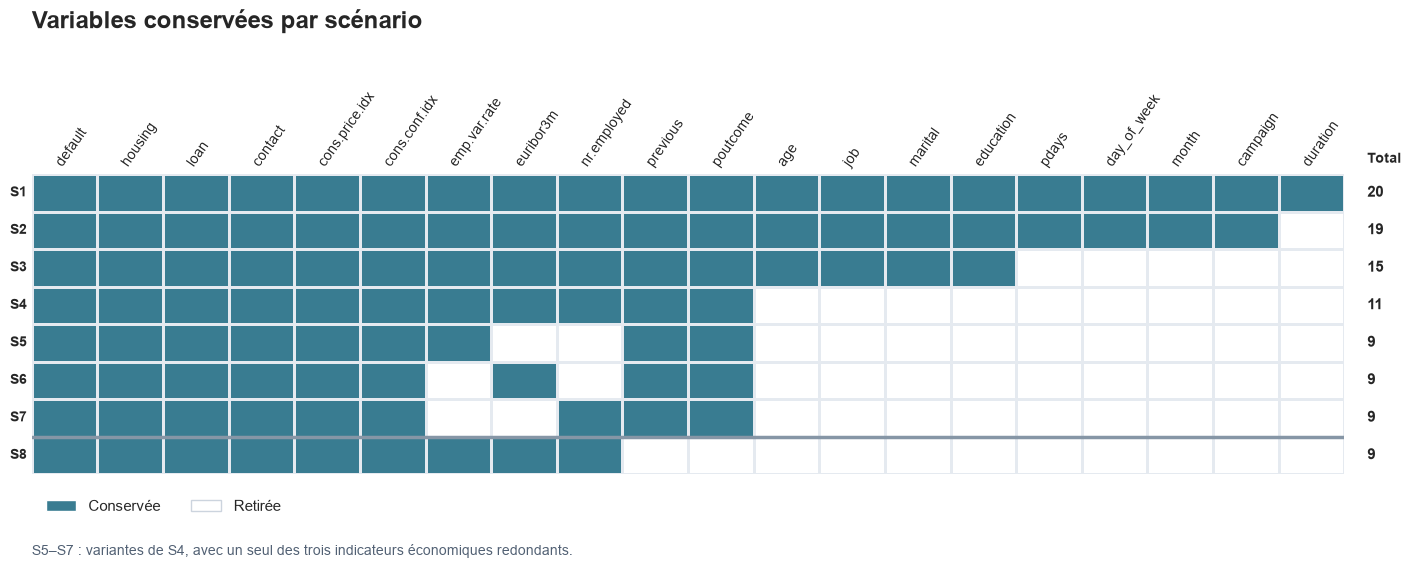

In [33]:
# Variables conservées dans chaque scénario
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

variables_scenarios = [
    "default", "housing", "loan", "contact", "cons.price.idx", "cons.conf.idx",
    "emp.var.rate", "euribor3m", "nr.employed", "previous", "poutcome",
    "age", "job", "marital", "education", "pdays", "day_of_week", "month",
    "campaign", "duration",
]
variables_par_scenario = {"S1": set(variables_scenarios)}
variables_par_scenario["S2"] = variables_par_scenario["S1"] - {"duration"}
variables_par_scenario["S3"] = variables_par_scenario["S2"] - {
    "pdays", "day_of_week", "month", "campaign"
}
variables_par_scenario["S4"] = variables_par_scenario["S3"] - {
    "age", "job", "marital", "education"
}
indicateurs_redondants = {"emp.var.rate", "euribor3m", "nr.employed"}
for scenario, indicateur in zip(["S5", "S6", "S7"],
                               ["emp.var.rate", "euribor3m", "nr.employed"]):
    variables_par_scenario[scenario] = (
        variables_par_scenario["S4"] - indicateurs_redondants
    ) | {indicateur}

variables_par_scenario["S8"] = variables_par_scenario["S4"] - {"previous", "poutcome"}

presence_variables = pd.DataFrame(
    [[int(variable in retenues) for variable in variables_scenarios]
     for retenues in variables_par_scenario.values()],
    index=variables_par_scenario, columns=variables_scenarios,
)
with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.heatmap(
        presence_variables, ax=ax, cmap=ListedColormap(["#ffffff", "#397c91"]),
        vmin=0, vmax=1, cbar=False, linewidths=2, linecolor="#e5eaf0",
        xticklabels=True, yticklabels=True,
    )
    ax.xaxis.tick_top()
    ax.tick_params(axis="both", length=0, labelsize=10)
    plt.setp(ax.get_xticklabels(), rotation=55, ha="left", rotation_mode="anchor")
    plt.setp(ax.get_yticklabels(), rotation=0, fontweight="bold")
    ax.set(xlabel="", ylabel="")
    ax.set_title("Variables conservées par scénario", loc="left",
                 fontsize=17, fontweight="bold", pad=105)
    ax.text(20.35, -0.3, "Total", fontsize=10, fontweight="bold", clip_on=False)
    for ligne, total in enumerate(presence_variables.sum(axis=1)):
        ax.text(20.35, ligne + 0.5, str(total), va="center", fontsize=11,
                fontweight="bold", clip_on=False)
    ax.axhline(7, color="#8696a6", linewidth=2.5)
    ax.legend(handles=[Patch(facecolor="#397c91", label="Conservée"),
                       Patch(facecolor="white", edgecolor="#ccd4de", label="Retirée")],
              loc="upper left", bbox_to_anchor=(0, -0.04), ncol=2, frameon=False)
    fig.text(0.065, 0.025, "S5–S7 : variantes de S4, avec un seul des trois indicateurs économiques redondants.",
             fontsize=10, color="#526174")
    fig.subplots_adjust(left=0.065, right=0.94, top=0.66, bottom=0.16)
    plt.show()



### 4.4 📝 Synthèse préparation

La préparation repose sur les constats de l’EDA. La qualité des données permet des traitements simples : les 12 doublons sont supprimés, les modalités `unknown` sont conservées et aucune imputation n’est nécessaire. Seules les trois occurrences de `default = yes` sont regroupées avec `unknown`, leur effectif étant trop faible. Aucune variable dérivée n’est créée.

Le préprocesseur combine `ColumnTransformer` et `Pipeline` avec deux branches : standardisation des variables numériques par `StandardScaler` et encodage des variables catégorielles par `OneHotEncoder`. Aucun ordre n’est imposé aux catégories, y compris pour `education`, dont l’ordre n'est pas évident pour toutes les valeurs.

La fonction `make_preprocessor` rend cette recette réutilisable : chaque scénario lui transmet les listes de variables retenues et conserve les mêmes traitements. Les scénarios reprennent les comparaisons demandées dans le sujet et les exclusions proposées après l’EDA. Les différences entre les modèles seront donc uniquement le fait des différences de variables, comme le préprocessing est identique.

Après suppression des doublons, les données ont été séparées en 80 % pour l’entraînement et 20 % pour l’évaluation finale. La stratification conserve environ 11,27 % de souscriptions dans chaque jeu. `random_state=42` permet de retrouver le même découpage à chaque exécution. Ce même découpage est utilisé pour tous les scénarios afin de comparer leurs résultats sur les mêmes données.


### 4.5 Assertions de qualité

Des `assert` vérifient la donnée préparée avant la modélisation : doublons, valeurs manquantes, plages de valeurs, cible, split, variables des scénarios et sortie du préprocessing.  
Une assertion qui échoue arrête le notebook.

In [34]:
# 4.5 Assertions de qualité
from scipy.sparse import issparse

# Données préparées
assert len(df_prepare) > 0, "Dataset vide après préparation"
assert not df_prepare.duplicated().any(), "Doublons résiduels"
assert df_prepare.notna().all().all(), "Valeurs manquantes résiduelles"

# Plages larges : seules les valeurs impossibles sont bloquées
assert df_prepare["age"].between(15, 120).all(), "Âge hors plage plausible"
assert (df_prepare["duration"] >= 0).all(), "Durée d'appel négative"
assert (df_prepare["campaign"] >= 1).all(), "Nombre de contacts de la campagne inférieur à 1"
assert (df_prepare["previous"] >= 0).all(), "Nombre de contacts antérieurs négatif"

# Cible
assert "y" not in X.columns, "Cible présente dans les variables explicatives"
assert y.notna().all() and set(y.unique()) == {0, 1}, "Cible binaire 0/1 attendue"

# Split train / test
assert len(X_train) + len(X_test) == len(df_prepare), "Split incomplet"
assert X_train.index.intersection(X_test.index).empty, "Lignes communes entre train et test"
assert X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index), "X et y désalignés"
assert abs(y_train.mean() - y.mean()) < 0.005 and abs(y_test.mean() - y.mean()) < 0.005, "Stratification non respectée"

# Scénarios
assert all(variables <= set(X.columns) for variables in variables_par_scenario.values()), "Variable de scénario absente des données"
assert [s for s, variables in variables_par_scenario.items() if "duration" in variables] == ["S1"], "duration présente hors S1"
assert all(not variables_par_scenario[s] & {"age", "job", "marital", "education"} for s in ["S4", "S5", "S6", "S7", "S8"]), "Variable sensible présente de S4 à S8"
assert all(len(variables_par_scenario[s] & indicateurs_redondants) == 1 for s in ["S5", "S6", "S7"]), "S5 à S7 : un seul indicateur économique attendu"
assert {s: len(variables) for s, variables in variables_par_scenario.items()} == {
    "S1": 20, "S2": 19, "S3": 15, "S4": 11, "S5": 9, "S6": 9, "S7": 9, "S8": 9
}, "Nombre de variables différent du tableau 4.3"

# Recette de préprocessing, ajustée sur le train et appliquée au test pour chaque scénario
colonnes_num = set(X.select_dtypes("number").columns)
for scenario, variables in variables_par_scenario.items():
    preprocesseur = make_preprocessor(sorted(variables & colonnes_num), sorted(variables - colonnes_num)).fit(X_train)
    X_test_prepare = preprocesseur.transform(X_test)
    X_test_prepare = X_test_prepare.toarray() if issparse(X_test_prepare) else X_test_prepare
    assert X_test_prepare.shape[0] == len(X_test), f"{scenario} : lignes perdues au préprocessing"
    assert not np.isnan(X_test_prepare).any(), f"{scenario} : valeurs manquantes après préprocessing"
    assert "cat__default_yes" not in preprocesseur.get_feature_names_out(), f"{scenario} : default = yes non regroupé"

print("Toutes les assertions de qualité passent")

Toutes les assertions de qualité passent


---
## 5. Modélisation & entraînement

### 5.0 Familles de modèles candidates

Les données sont tabulaires :
- 41 188 lignes
- 20 variables explicatives avant sélection et une cible `y` connue (« yes » / « no »)

Le problème consiste à identifier, avant les appels, les clients les plus susceptibles de souscrire un dépôt à terme, afin de réduire le nombre de clients contactés tout en préservant les souscriptions.

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| **ML classique** (sklearn, XGBoost) | **OUI** : **classification supervisée** sur des variables **numériques et catégorielles**, avec un volume compatible avec un entraînement local | **FAIBLE À MODÉRÉ** selon le modèle ; entraînement sur **CPU** et **inférence peu coûteuse** | **ÉLEVÉE** pour une **régression logistique** ou un **arbre simple** ; **MODÉRÉE** pour les **forêts aléatoires et boosting** | **FAIBLE** : exécution locale, aucune API externe nécessaire | **RETENUE** : comparer une **régression logistique**, un **arbre de décision** et une **forêt aléatoire** pour **apprendre les relations entre variables et souscription** |
| **Deep Learning** (Keras / PyTorch) | **POSSIBLE** sur le tabulaire, mais **aucun besoin** de traitement d'images, de texte libre ou d'audio | **MODÉRÉ** pour un petit réseau tabulaire : entraînement et réglage du réseau ; **GPU non indispensable** | **FAIBLE** : **explications a posteriori nécessaires** | **FAIBLE** : exécution locale, aucune API externe nécessaire | **ÉCARTÉE** à ce stade : **complexité de conception et de réglage**, **sans bénéfice établi** pour ce besoin de ciblage |
| **SLM local** (Ollama, modèles ≤ 7B) | **PEU ADAPTÉ** : **aucun besoin de compréhension ou de génération de texte** | **MODÉRÉ À ÉLEVÉ** : chargement et inférence du modèle local ; **mémoire et calcul** à provisionner, sans facturation par appel API | **FAIBLE** pour justifier un score de souscription ; une explication générée **ne garantit pas la fidélité au calcul** | **FAIBLE** : exécution locale, dépendance au modèle choisi et à sa licence | **ÉCARTÉE** : **aucun besoin de traitement linguistique** pour ce score de souscription à partir de variables structurées |
| **LLM API + RAG** | **PEU ADAPTÉ** : **aucun corpus documentaire** à interroger ni réponse textuelle à produire | **ÉLEVÉ** estimé pour le traitement des clients : **appels API** récurrents et gestion de l'index documentaire ; pas d'entraînement du LLM de zéro | **FAIBLE** pour expliquer une prédiction individuelle de souscription | **FORTE** : dépendance au fournisseur du LLM hébergé en API | **ÉCARTÉE** : la **recherche documentaire ne répond pas au besoin** de classement des clients selon leur probabilité de souscription |
| **Architecture agentique** (multi-LLM, tools) | **PEU ADAPTÉE** : **pas de besoin** d'**orchestration autonome d'actions** | **TRÈS ÉLEVÉ** estimé pour une architecture multi-LLM : **appels multiples**, exécution des outils et orchestration à chaque traitement | **Traçabilité possible** des actions, **justification** du score **difficile** | **FORTE** : dépendance aux fournisseurs des modèles et outils hébergés ; faible en exécution entièrement locale | **ÉCARTÉE** : **aucune séquence autonome d'actions n'est requise** pour produire le score de ciblage |




### 5.0.1 📝 Synthèse familles

Le ML classique supervisé est retenu pour la classification binaire sur ces données tabulaires. Les autres familles ajoutent une complexité sans besoin identifié de traitement non structuré, de génération, de recherche documentaire ou d'actions autonomes. Par sobriété et par abscence de besoin, on se tournera donc vers les modèles les plus simples.

Le choix des modèles privilégiera le coût de calcul, l'explicabilité pour les conseillers et la cible de latence p95 < 200 ms, à mesurer ; la comparaison portera sur le rappel de la classe « oui » sous contrainte de sélection d'au maximum 50 % des clients.


### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| **Régression logistique** | Modèle **linéaire** de classification | **RÉFÉRENCE** : estimer la probabilité de souscription à partir d'une combinaison pondérée des variables ; disposer d'un modèle simple pour évaluer l'apport des autres candidats | **FAIBLE / FAIBLE** : entraînement sur CPU et calcul rapide du score | **ÉLEVÉE** : les coefficients indiquent le sens et le poids des associations avec la souscription, en tenant compte de l'encodage et de l'échelle des variables |
| **Arbre de décision** | **Arbre** de classification | Apprendre des **règles de décision** et des **relations non linéaires** entre les caractéristiques des clients et la souscription | **FAIBLE / FAIBLE** avec une profondeur limitée : entraînement sur CPU et parcours d'un seul arbre à l'inférence | **ÉLEVÉE** si l'arbre reste peu profond : le chemin de décision peut être lu sous forme de règles |
| **Forêt aléatoire** | **Forêt d'arbres** de classification | Combiner plusieurs arbres pour capter des **interactions entre variables** et **limiter le surapprentissage** d'un arbre isolé | **MODÉRÉ / FAIBLE À MODÉRÉ** : entraînement et interrogation de plusieurs arbres, selon leur nombre et leur profondeur | **MODÉRÉE** : importance des variables pour une vue globale ; outils d'interprétation pour expliquer une prédiction individuelle |


### 5.2 Entraînement & validation croisée

In [35]:
# 5.2.1 Import et configuration des modèles candidats retenus


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Pour commencer, les trois modèles gardent des hyperparamètres proches des valeurs par défaut
# Le réglage des hyperparamètres se fera dans une section suivante (5.5) sur le modèle retenu

# les souscripteurs ne représentent que 11,27 % des clients, donc on ajoute class_weight="balanced"
# ce qui donne à chaque souscripteur environ 7,9 fois plus de poids pendant l’entraînement.

modeles = {
    # max_iter=1000 laisse à la régression logistique assez d'itérations pour converger.
    "Régression logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    # max_depth=5 limite la profondeur de l'arbre, pour que ses règles restent lisibles.
    "Arbre de décision": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    # n_jobs=-1 répartit l'entraînement des arbres de la forêt sur tous les cœurs du processeur.
    "Forêt aléatoire": RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
}

In [36]:
# 5.2.2 Découpage de validation croisée
from sklearn.model_selection import StratifiedKFold

# Avec la validation croisée, on évalue chaque modèle sur 5 groupes de clients pour vérifier que ses scores restent proches.
# Chaque pli sert une fois à la validation, les 4 autres à l'entraînement.
# Chaque pli conserve la même proportion de souscripteurs.

# cv définit le découpage ; les données lui seront fournies pendant l'entraînement.
# shuffle mélange les lignes et random_state rend le découpage reproductible.
# Tous les scénarios et modèles utilisent les mêmes plis pour être comparables.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [37]:
# 5.2.3 Entraînement et validation croisée : scénarios × modèles
from sklearn.model_selection import cross_val_predict

# Le but est d'obtenir, pour chaque scénario et chaque modèle, une probabilité de souscription pour chaque client du train.
# Ces probabilités serviront ensuite à calculer les scores des modèles.
probas_cv = {}

# Les 8 scénarios utilisent des ensembles différents de colonnes pour prédire la souscription.
# La boucle récupère le nom du scénario et les colonnes à utiliser pour entraîner les modèles.
for scenario, variables in variables_par_scenario.items():
    # Pour chaque scénario, on entraîne les 3 modèles.
    for nom_modele, modele in modeles.items():
        # On prépare seulement les variables du scénario : mise à l'échelle des numériques, encodage des catégorielles.
        pipe = Pipeline([
            ("prep", make_preprocessor(
                sorted(variables & colonnes_num), sorted(variables - colonnes_num)
            )),
            ("clf", modele),
        ])
        # cross_val_predict appelle fit sur 4 plis, puis predict_proba sur le pli restant.
        # L'opération est répétée pour que chaque client reçoive une prédiction sans avoir servi à l'entraînement.
        probas_cv[(scenario, nom_modele)] = cross_val_predict(
            pipe, X_train, y_train, cv=cv, method="predict_proba"
        )[:, 1]

print(f"{len(probas_cv)} combinaisons entraînées")

24 combinaisons entraînées


### 5.3 Métriques retenues & justification

**Métrique principale : rappel parmi les 50 % de clients au score le plus élevé**  
Cette métrique mesure directement le critère de succès défini au départ : conserver au moins 80 % des souscriptions en contactant au maximum 50 % des clients.
Le modèle classe les clients par probabilité de souscription décroissante. La moitié la mieux classée est sélectionnée.  
Le rappel est la part des souscripteurs présents dans cette moitié. Cible : ≥ 0,80.  
La part de clients sélectionnés est fixée à 50 %. Un rappel élevé obtenu en sélectionnant tous les clients est ainsi impossible.

**Métrique complémentaire : ROC-AUC**  
Le ROC-AUC mesure la qualité du classement des clients sur tous les seuils de sélection possibles. Il indique si le modèle reste bon quand la part de clients sélectionnés change.  
0,5 correspond à un classement au hasard, 1 à un classement parfait.

**Accuracy : écartée**  
La cible est déséquilibrée : 11,27 % de souscriptions. Un modèle qui répond toujours « non » obtient environ 89 % d'accuracy. L'accuracy ne permet donc pas de juger les modèles.

**Précision et F1 : écartés**  
Le rappel mesure la part des souscripteurs que le modèle retrouve. La précision mesure la part des clients sélectionnés qui souscrivent. Le F1 combine ces deux mesures.  

Dans notre cas, chaque modèle sélectionne exactement la moitié des clients : sur 1 000 clients, chacun en sélectionne 500. Un modèle qui retrouve davantage de souscripteurs dans ces 500 clients améliore à la fois son rappel et sa précision. Son F1 augmente donc aussi.
Le F1 donne ainsi le même classement des modèles que le rappel. On retient le rappel parce qu'il répond directement à l'objectif : retrouver au moins 80 % des souscripteurs en contactant la moitié des clients.


In [38]:
# Définition des métriques
from sklearn.metrics import roc_auc_score

def rappel_top50(y_vrai, probas):
    """Part des souscripteurs retrouvés parmi les 50 % de clients au score le plus élevé."""
    # Les clients sont classés par probabilité décroissante, puis la première moitié est sélectionnée.
    # Le nombre de clients sélectionnés est fixe : les ex aequo, fréquents avec un arbre, ne font pas dépasser 50 %.
    selection = np.argsort(-probas, kind="stable")[: len(probas) // 2]
    return np.asarray(y_vrai)[selection].sum() / np.asarray(y_vrai).sum()

metriques = {"rappel_top50": rappel_top50, "roc_auc": roc_auc_score}

### 5.4 Comparaison des modèles : tableau de scores CV

#### 5.4.1 Comparaison des modèles à 50%

In [39]:
# On compare les probabilités de chaque modèle aux souscriptions réelles de tous les clients du train.
# On calcule un rappel et un ROC-AUC par combinaison de scénario et de modèle.
# On pourrait aussi calculer les scores par pli et leur écart-type pour mesurer leur variation.
lignes = []
for (scenario, nom_modele), probas in probas_cv.items():
    ligne = {"scenario": scenario, "modele": nom_modele}
    for nom_metrique, metrique in metriques.items():
        ligne[nom_metrique] = metrique(y_train, probas)
    lignes.append(ligne)

tableau_cv = pd.DataFrame(lignes).round(3)
tableau_cv

# Le scénario S1 contient la fuite d’information liée à la durée de l’appel.
# Comme attendu, la régression logistique et la forêt aléatoire atteignent un rappel de 0,995.
# L’arbre de décision est légèrement en dessous, avec un rappel de 0,986.
# Les ROC-AUC sont également très élevés : 0,937, 0,942 et 0,932 respectivement.

# Le scénario S2
# Dans S2, on a retiré duration, la principale fuite d’information.
# Le rappel chute autour de 0,80, mais les résultats sont plus honnêtes sans cette fuite.
# Le ROC-AUC reste élevé, entre 0,777 et 0,790 selon le modèle.

# S3 retire les variables de campagne potentiellement indisponibles avant les appels et pdays, incohérent.
# Les rappels baissent peu : régression 0,814 → 0,809 ; arbre 0,795 → 0,784 ; forêt 0,802 → 0,800.
# Les ROC-AUC passent respectivement de 0,790 à 0,780, de 0,779 à 0,774 et de 0,777 à 0,762.
# On peut donc retirer ces variables avec une faible perte de performance.

# S4 retire age, job, marital et education à la suite de l’audit éthique, pour limiter les données personnelles utilisées.
# Les rappels restent proches pour la régression (0,809 → 0,812) et l’arbre (0,784 → 0,787).
# La forêt baisse davantage : rappel 0,800 → 0,750 et ROC-AUC 0,762 → 0,729.
# On retient ce retrait : ces données ne sont pas nécessaires pour conserver le rappel de la régression.

# S5 à S7 gardent un seul indicateur : emp.var.rate, euribor3m ou nr.employed, respectivement.
# S5 conserve le rappel de la régression à 0,812 et améliore ceux de l’arbre (0,808) et de la forêt (0,786).
# S6 et S7 font moins bien pour la régression et l’arbre ; S7 égale S5 pour la forêt.
# On privilégie donc emp.var.rate seul : garder les trois indicateurs n’apporte pas de gain ici.

# S8 retire previous et poutcome de S4 : ce modèle minimal conserve presque le rappel de la régression (0,811 contre 0,812).
# Par rapport à S4, les rappels de l’arbre et de la forêt augmentent à 0,802 et 0,764.
# S8 dépasse S6 et S7 pour la régression et l’arbre, mais S5 reste meilleur pour les trois modèles.
# Ce résultat est intéressant : retirer l’historique des contacts préserve ou améliore le rappel face à S4.


,scenario,modele,rappel_top50,roc_auc
0,S1,Régression logistique,0.995,0.937
1,S1,Arbre de décision,0.986,0.932
2,S1,Forêt aléatoire,0.995,0.942
3,S2,Régression logistique,0.814,0.790
4,S2,Arbre de décision,0.795,0.779
5,S2,Forêt aléatoire,0.802,0.777
6,S3,Régression logistique,0.809,0.780
7,S3,Arbre de décision,0.784,0.774
8,S3,Forêt aléatoire,0.800,0.762
9,S4,Régression logistique,0.812,0.779


In [40]:
# Classement des modèles des scénarios S4 à S8

# S1 à S3 servent de références pour mesurer l’effet des exclusions de variables.
# S4 à S8 sont les scénarios retenus pour choisir le modèle à utiliser.
# On les classe par rappel décroissant, puis par ROC-AUC en cas d’égalité.
classement_s4_s8 = (
    tableau_cv[tableau_cv["scenario"].isin(["S4", "S5", "S6", "S7", "S8"])]
    .sort_values(["rappel_top50", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
classement_s4_s8.index += 1
classement_s4_s8

# La régression logistique occupe les trois premières places avec S5, S4 et S8.
# Les rappels sont presque identiques (0,811 à 0,812), avec des ROC-AUC proches (0,770 à 0,780).
# S8 offre donc un résultat comparable avec moins de variables et mérite d’être étudié pour la suite.

# Les arbres de décision de S5 et S8 occupent les quatrième et cinquième places.
# Leurs rappels atteignent 0,808 et 0,802, avec des ROC-AUC de 0,787 et 0,780.
# On pourra tester leurs hyperparamètres pour voir si ces scores peuvent encore progresser.

# Les forêts aléatoires occupent les cinq dernières places du classement.
# Leurs rappels vont de 0,748 à 0,786 et leurs ROC-AUC de 0,729 à 0,766.
# Avec les réglages testés, leur complexité n’apporte pas de gain face à la régression ou à l’arbre.


,scenario,modele,rappel_top50,roc_auc
1,S5,Régression logistique,0.812,0.780
2,S4,Régression logistique,0.812,0.779
3,S8,Régression logistique,0.811,0.770
4,S5,Arbre de décision,0.808,0.787
5,S8,Arbre de décision,0.802,0.780
6,S6,Régression logistique,0.800,0.770
7,S6,Arbre de décision,0.797,0.784
8,S7,Régression logistique,0.795,0.770
9,S7,Arbre de décision,0.793,0.779
10,S4,Arbre de décision,0.787,0.778


#### Comparaison des modèles à 25% et 75% — Bonus


In [41]:
# On réutilise les probabilités déjà calculées, sans entraîner de nouveaux modèles.
# On sélectionne les 25 %, 50 % ou 75 % de clients les mieux classés dans tout le train.
# Le rappel mesure la part des souscripteurs retrouvés parmi ces clients.
def rappel_selection(y_vrai, probas, proportion):
    selection = np.argsort(-probas, kind="stable")[: int(len(probas) * proportion)]
    return np.asarray(y_vrai)[selection].sum() / np.asarray(y_vrai).sum()

lignes_bonus = []
for (scenario, nom_modele), probas in probas_cv.items():
    ligne = {"scenario": scenario, "modele": nom_modele}
    for proportion in (0.25, 0.50, 0.75):
        colonne = f"rappel_top{int(proportion * 100)}"
        ligne[colonne] = rappel_selection(y_train, probas, proportion)
    lignes_bonus.append(ligne)

tableau_bonus = pd.DataFrame(lignes_bonus)
# On affiche le rappel pour les 24 combinaisons à chaque proportion de clients sélectionnés.
display(tableau_bonus.round(3))

# On compare les classements à 25 %, 50 % et 75 % pour voir si les premiers changent.
# Le ROC-AUC départage les rappels égaux, comme dans le classement à 50 %.
comparaison_bonus = tableau_bonus.merge(
    tableau_cv[["scenario", "modele", "roc_auc"]], on=["scenario", "modele"]
)
for proportion in (25, 50, 75):
    classement_bonus = comparaison_bonus.sort_values(
        [f"rappel_top{proportion}", "roc_auc"], ascending=False
    ).reset_index(drop=True)
    classement_bonus.index += 1
    print(f"Classement avec {proportion} % des clients sélectionnés — tous les scénarios")
    display(classement_bonus[["scenario", "modele", f"rappel_top{proportion}"]].round(3))
    # On affiche aussi le classement complet de S4 à S8, les scénarios retenus pour le choix final.
    print(f"Classement complet de S4 à S8 avec {proportion} % des clients sélectionnés")
    display(classement_bonus[
        classement_bonus["scenario"].isin(["S4", "S5", "S6", "S7", "S8"])
    ][["scenario", "modele", f"rappel_top{proportion}"]].round(3))

# À 25 %, les arbres occupent les quatre premières places, avec des rappels proches de 0,65 à 0,66.
# Les arbres S5 et S8 atteignent 0,655 et 0,652 et figurent aussi parmi les meilleurs à 50 %.
# La régression reste proche, notamment avec S4 et S7 à 0,652 et S5 à 0,648.

# À 75 %, les cinq arbres arrivent en tête, avec des rappels très proches de 0,920 à 0,924.
# S5 atteint 0,924 et S8 atteint 0,923 ; leur avance sur la régression S5 à 0,917 reste faible.
# Les premières places des arbres ne correspondent donc pas à un grand écart de performance.

# On privilégie les arbres S5 et S8 pour tester les hyperparamètres, car ils sont bien placés aux trois proportions.
# On vérifiera si ces réglages améliorent le rappel, notamment à 50 %, notre objectif principal.
# La régression S5 reste une alternative proche si le réglage des arbres n’apporte pas de gain.


,scenario,modele,rappel_top25,rappel_top50,rappel_top75
0,S1,Régression logistique,0.915,0.995,0.999
1,S1,Arbre de décision,0.917,0.986,0.993
2,S1,Forêt aléatoire,0.935,0.995,0.999
3,S2,Régression logistique,0.663,0.814,0.926
4,S2,Arbre de décision,0.645,0.795,0.918
5,S2,Forêt aléatoire,0.653,0.802,0.918
6,S3,Régression logistique,0.653,0.809,0.912
7,S3,Arbre de décision,0.653,0.784,0.917
8,S3,Forêt aléatoire,0.636,0.800,0.906
9,S4,Régression logistique,0.652,0.812,0.915


Classement avec 25 % des clients sélectionnés — tous les scénarios


,scenario,modele,rappel_top25
1,S1,Forêt aléatoire,0.935
2,S1,Arbre de décision,0.917
3,S1,Régression logistique,0.915
4,S6,Arbre de décision,0.664
5,S2,Régression logistique,0.663
6,S4,Arbre de décision,0.657
7,S5,Arbre de décision,0.655
8,S3,Régression logistique,0.653
9,S2,Forêt aléatoire,0.653
10,S3,Arbre de décision,0.653


Classement complet de S4 à S8 avec 25 % des clients sélectionnés


,scenario,modele,rappel_top25
4,S6,Arbre de décision,0.664
6,S4,Arbre de décision,0.657
7,S5,Arbre de décision,0.655
11,S8,Arbre de décision,0.652
12,S4,Régression logistique,0.652
13,S7,Régression logistique,0.652
14,S5,Régression logistique,0.648
15,S7,Arbre de décision,0.647
18,S6,Régression logistique,0.634
19,S7,Forêt aléatoire,0.634


...

,scenario,modele,rappel_top50
5,S4,Régression logistique,0.812
6,S5,Régression logistique,0.812
7,S8,Régression logistique,0.811
9,S5,Arbre de décision,0.808
11,S8,Arbre de décision,0.802
12,S6,Régression logistique,0.800
14,S6,Arbre de décision,0.797
16,S7,Régression logistique,0.795
17,S7,Arbre de décision,0.793
18,S4,Arbre de décision,0.787


Classement avec 75 % des clients sélectionnés — tous les scénarios


,scenario,modele,rappel_top75
1,S1,Forêt aléatoire,0.999
2,S1,Régression logistique,0.999
3,S1,Arbre de décision,0.993
4,S2,Régression logistique,0.926
5,S5,Arbre de décision,0.924
6,S7,Arbre de décision,0.923
7,S8,Arbre de décision,0.923
8,S4,Arbre de décision,0.921
9,S6,Arbre de décision,0.920
10,S2,Arbre de décision,0.918


Classement complet de S4 à S8 avec 75 % des clients sélectionnés


,scenario,modele,rappel_top75
5,S5,Arbre de décision,0.924
6,S7,Arbre de décision,0.923
7,S8,Arbre de décision,0.923
8,S4,Arbre de décision,0.921
9,S6,Arbre de décision,0.920
12,S5,Régression logistique,0.917
14,S4,Régression logistique,0.915
16,S7,Forêt aléatoire,0.907
17,S5,Forêt aléatoire,0.907
19,S8,Régression logistique,0.901


### 5.5 Optimisation des hyperparamètres

On retient l’arbre de décision du scénario S5 pour tester et régler ses hyperparamètres.

In [43]:
# 5.5.1 Baseline : arbre de décision S5 avec les hyperparamètres par défaut utilisés pour la comparaison avec les autres familles de modèles
from sklearn.base import clone

# Variables du scénario S5
variables_s5 = variables_par_scenario["S5"]
# Même arbre que dans la comparaison des modèles, sans changement : max_depth=5, class_weight="balanced"
pipe_arbre_s5 = Pipeline([
    ("prep", make_preprocessor(
        sorted(variables_s5 & colonnes_num), sorted(variables_s5 - colonnes_num)
    )),
    ("clf", clone(modeles["Arbre de décision"])),
])
# Mêmes plis cv que dans la comparaison des modèles, pour que les réglages suivants restent comparables
probas_baseline = cross_val_predict(
    pipe_arbre_s5, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

# Mêmes métriques : rappel parmi les 50 % de clients au score le plus élevé et ROC-AUC
tableau_baseline = pd.DataFrame([{
    "configuration": "max_depth=5",
    **{nom: metrique(y_train, probas_baseline) for nom, metrique in metriques.items()},
}]).round(3)
tableau_baseline


,configuration,rappel_top50,roc_auc
0,max_depth=5,0.808,0.787


In [44]:
# 5.5.2 Profondeur maximale de l'arbre

# max_depth fixe le nombre maximal de questions successives posées pour classer un client.
# Un arbre de profondeur d a au plus 2^d feuilles, et chaque feuille donne le même score à tous ses clients.
# Plus l'arbre est profond, plus le classement est fin, mais plus il risque d'apprendre le bruit du train.

# Profondeurs testées, de très faible à illimitée : None laisse l'arbre pousser jusqu'à des feuilles pures
profondeurs = [2, 3, 4, 5, 6, 8, 10, 15, None]

lignes = []
for profondeur in profondeurs:
    # Seul max_depth change ; les autres réglages restent ceux de la baseline
    pipe = clone(pipe_arbre_s5).set_params(clf__max_depth=profondeur)
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth={profondeur}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
    })

tableau_profondeur = pd.DataFrame(lignes).round(3)
tableau_profondeur

# Le meilleur rappel en validation croisée atteint 0,809 avec une profondeur de 6.
# Le gain reste faible par rapport à la profondeur de 5, qui atteint 0,808 et le meilleur ROC-AUC à 0,787.
# À partir de 8, le rappel en validation croisée baisse tandis que le rappel sur le train augmente.
# Cet écart croissant signale un surapprentissage malgré la hausse du nombre de feuilles.
# Une profondeur de 5 ou 6 offre donc un bon compromis entre finesse du classement et généralisation.


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles
0,max_depth=2,0.793,0.760,0.798,4
1,max_depth=3,0.807,0.776,0.807,8
2,max_depth=4,0.807,0.784,0.809,16
3,max_depth=5,0.808,0.787,0.816,32
4,max_depth=6,0.809,0.786,0.819,63
5,max_depth=8,0.797,0.778,0.826,177
6,max_depth=10,0.784,0.766,0.832,369
7,max_depth=15,0.765,0.747,0.836,752
8,max_depth=None,0.763,0.745,0.836,767


In [45]:
# 5.5.3 Taille minimale des feuilles

# min_samples_leaf fixe le nombre minimal de clients dans chaque feuille.
# Une feuille avec peu de clients donne un score peu fiable, car il repose sur quelques cas seulement.
# Plus ce minimum est élevé, plus l'arbre est contraint, et plus il risque de manquer des groupes de clients utiles.

# Valeurs testées, de 1 (valeur par défaut) à 500 clients par feuille
tailles_feuilles = [1, 10, 20, 50, 100, 200, 500]

lignes = []
for taille in tailles_feuilles:
    # Seul min_samples_leaf change ; la profondeur reste celle retenue au test précédent
    pipe = clone(pipe_arbre_s5).set_params(clf__max_depth=5, clf__min_samples_leaf=taille)
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth=5, min_samples_leaf={taille}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
    })

tableau_feuilles = pd.DataFrame(lignes).round(3)
tableau_feuilles

# Le meilleur rappel en validation croisée atteint 0,809 avec 10 ou 20 clients minimum par feuille, contre 0,808 sans minimum.
# Ce gain de 0,001 reste dans le bruit de la validation croisée ; le ROC-AUC passe de 0,787 à 0,788.
# À partir de 50 clients par feuille, le rappel baisse légèrement, jusqu'à 0,802 avec 500 clients.
# Avec une profondeur de 5, le nombre de feuilles varie peu (de 32 à 25) : les feuilles sont déjà grandes, et ce paramètre agit donc peu.
# On garde 20 clients minimum par feuille : même rappel, et aucune feuille ne repose sur quelques clients seulement.


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles
0,"max_depth=5, min_samples_leaf=1",0.808,0.787,0.816,32
1,"max_depth=5, min_samples_leaf=10",0.809,0.788,0.816,32
2,"max_depth=5, min_samples_leaf=20",0.809,0.788,0.816,32
3,"max_depth=5, min_samples_leaf=50",0.803,0.783,0.816,31
4,"max_depth=5, min_samples_leaf=100",0.805,0.782,0.812,31
5,"max_depth=5, min_samples_leaf=200",0.803,0.782,0.812,30
6,"max_depth=5, min_samples_leaf=500",0.802,0.778,0.811,25


In [46]:
# 5.5.4 Nombre maximal de feuilles

# max_leaf_nodes fixe directement le nombre maximal de feuilles, donc de scores différents.
# L'arbre crée d'abord les divisions qui améliorent le plus le classement, quelle que soit leur profondeur.
# Ce paramètre remplace ici la limite de profondeur : max_depth passe à None, et l'arbre descend là où c'est utile.

# Valeurs testées, de 8 feuilles à 100 feuilles
nombres_feuilles = [8, 16, 24, 32, 48, 64, 100]

lignes = []
for nombre in nombres_feuilles:
    # Seul max_leaf_nodes limite la taille de l'arbre ; les 20 clients minimum par feuille du test précédent sont conservés
    pipe = clone(pipe_arbre_s5).set_params(
        clf__max_depth=None, clf__min_samples_leaf=20, clf__max_leaf_nodes=nombre
    )
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth=None, min_samples_leaf=20, max_leaf_nodes={nombre}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
        # Profondeur atteinte par l'arbre, puisqu'elle n'est plus limitée
        "profondeur": pipe.named_steps["clf"].get_depth(),
    })

tableau_nb_feuilles = pd.DataFrame(lignes).round(3)
tableau_nb_feuilles

# Le meilleur rappel en validation croisée atteint 0,816 avec 24 feuilles, contre 0,809 pour l'arbre de profondeur 5 retenu jusqu'ici.
# Le ROC-AUC reste à 0,788, et le rappel sur le train est identique au rappel en validation croisée (0,816).
# Le résultat varie d'une valeur à l'autre : 0,800 avec 16 feuilles et 0,811 avec 32. Une part du gain peut donc venir du bruit de la validation croisée.
# Au-delà de 32 feuilles, le rappel en validation croisée baisse jusqu'à 0,805 avec 100 feuilles, et le rappel sur le train monte jusqu'à 0,824.
# On garde 24 feuilles au maximum pour la suite : meilleur rappel, avec moins de feuilles que l'arbre de profondeur 5 (24 contre 32).


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
0,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=8",0.793,0.775,0.798,8,4
1,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=16",0.800,0.783,0.800,16,7
2,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24",0.816,0.788,0.816,24,7
3,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=32",0.811,0.787,0.816,32,8
4,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=48",0.808,0.786,0.818,48,9
5,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=64",0.808,0.786,0.820,64,10
6,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=100",0.805,0.784,0.824,100,12


In [47]:
# 5.5.5 Poids des classes

# class_weight fixe le poids de chaque classe pendant l'entraînement.
# Les souscripteurs ne représentent que 11,27 % des clients : sans poids, l'arbre choisit ses divisions surtout pour les non-souscripteurs.
# "balanced" donne à chaque souscripteur environ 7,9 fois plus de poids ; {0: 1, 1: 3} donne un poids intermédiaire de 3.

# Valeurs testées : aucun poids, poids intermédiaire, poids équilibré
poids_classes = [None, {0: 1, 1: 3}, "balanced"]

lignes = []
for poids in poids_classes:
    # Seul class_weight change ; la taille de l'arbre reste celle retenue au test précédent
    pipe = clone(pipe_arbre_s5).set_params(
        clf__max_depth=None, clf__min_samples_leaf=20, clf__max_leaf_nodes=24, clf__class_weight=poids
    )
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight={poids}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
        # Profondeur atteinte par l'arbre, puisqu'elle n'est plus limitée
        "profondeur": pipe.named_steps["clf"].get_depth(),
    })

tableau_poids = pd.DataFrame(lignes).round(3)
tableau_poids

# Le poids équilibré donne le meilleur rappel en validation croisée : 0,816, contre 0,798 avec un poids de 3 et 0,794 sans poids.
# On garde class_weight="balanced" pour la suite.


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
0,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=None",0.794,0.779,0.800,24,9
1,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight={0: 1, 1: 3}",0.798,0.783,0.806,24,7
2,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced",0.816,0.788,0.816,24,7


In [48]:
# 5.5.6 Critère de division

# criterion fixe la formule qui mesure la qualité d'une division, pour choisir la meilleure question à chaque nœud.
# "gini" (valeur par défaut) et "entropy" mesurent tous les deux le mélange de souscripteurs et de non-souscripteurs dans une feuille.
# Les deux formules choisissent souvent les mêmes divisions, mais peuvent différer sur les nœuds où plusieurs questions se valent.

# Valeurs testées : les deux formules
criteres = ["gini", "entropy"]

lignes = []
for critere in criteres:
    # Seul criterion change ; les autres réglages restent ceux retenus aux tests précédents
    pipe = clone(pipe_arbre_s5).set_params(
        clf__max_depth=None, clf__min_samples_leaf=20, clf__max_leaf_nodes=24,
        clf__class_weight="balanced", clf__criterion=critere
    )
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion={critere}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
        # Profondeur atteinte par l'arbre, puisqu'elle n'est plus limitée
        "profondeur": pipe.named_steps["clf"].get_depth(),
    })

tableau_critere = pd.DataFrame(lignes).round(3)
tableau_critere

# gini donne le meilleur rappel en validation croisée : 0,816, contre 0,809 pour entropy, avec un ROC-AUC proche (0,788 contre 0,789).
# On garde criterion="gini" pour la suite.


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
0,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini",0.816,0.788,0.816,24,7
1,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=entropy",0.809,0.789,0.816,24,7


In [49]:
# 5.5.7 Élagage

# ccp_alpha règle l'élagage : après la construction, l'arbre retire les branches qui améliorent peu la qualité des feuilles.
# Plus ccp_alpha est élevé, plus l'arbre retire de branches, et plus il a peu de feuilles.
# 0 (valeur par défaut) ne retire aucune branche.

# Valeurs testées, de aucun élagage à un élagage fort
valeurs_elagage = [0, 0.0001, 0.0005, 0.001, 0.002, 0.005]

lignes = []
for alpha in valeurs_elagage:
    # Seul ccp_alpha change ; les autres réglages restent ceux retenus aux tests précédents
    pipe = clone(pipe_arbre_s5).set_params(
        clf__max_depth=None, clf__min_samples_leaf=20, clf__max_leaf_nodes=24,
        clf__class_weight="balanced", clf__criterion="gini", clf__ccp_alpha=alpha
    )
    probas = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    # Score sur les clients qui ont servi à l'entraînement : un écart croissant avec le score CV signale le surapprentissage
    probas_train = pipe.fit(X_train, y_train).predict_proba(X_train)[:, 1]
    lignes.append({
        "configuration": f"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha={alpha}",
        **{nom: metrique(y_train, probas) for nom, metrique in metriques.items()},
        "rappel_top50_train": rappel_top50(y_train, probas_train),
        # Nombre de feuilles de l'arbre entraîné sur tout le train, donc nombre de scores différents possibles
        "feuilles": pipe.named_steps["clf"].get_n_leaves(),
        # Profondeur atteinte par l'arbre, puisqu'elle n'est plus limitée
        "profondeur": pipe.named_steps["clf"].get_depth(),
    })

tableau_elagage = pd.DataFrame(lignes).round(3)
tableau_elagage

# L'élagage fait baisser le rappel en validation croisée dès qu'il retire des branches : de 0,816 sans élagage à 0,777 avec ccp_alpha=0.005.
# On garde ccp_alpha=0 : la limite de 24 feuilles contrôle déjà la taille de l'arbre.


,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
0,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0",0.816,0.788,0.816,24,7
1,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.0001",0.816,0.788,0.816,24,7
2,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.0005",0.809,0.786,0.813,16,6
3,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.001",0.808,0.783,0.813,12,5
4,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.002",0.795,0.775,0.798,7,4
5,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.005",0.777,0.753,0.781,4,3


In [50]:
# 5.5.8 Comparaison des tests d'hyperparamètres

# Chaque nouveau test ajoute son tableau à cette liste, dans l'ordre où il a été lancé
tableaux_tests = {
    "Baseline": tableau_baseline,
    "Profondeur": tableau_profondeur,
    "Taille minimale des feuilles": tableau_feuilles,
    "Nombre maximal de feuilles": tableau_nb_feuilles,
    "Poids des classes": tableau_poids,
    "Critère de division": tableau_critere,
    "Élagage": tableau_elagage,
}

# Tous les tests dans l'ordre
tests_realises = pd.concat(
    [tableau.assign(test=nom) for nom, tableau in tableaux_tests.items()], ignore_index=True
)
tests_realises.index += 1
tests_realises = tests_realises[["test", "configuration", "rappel_top50", "roc_auc", "rappel_top50_train", "feuilles", "profondeur"]]
display(tests_realises)

# Classement par rappel décroissant, puis par ROC-AUC en cas d'égalité, comme pour la comparaison des modèles
classement_tests = tests_realises.sort_values(["rappel_top50", "roc_auc"], ascending=False).reset_index(drop=True)
classement_tests.index += 1
classement_tests


,test,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
1,Baseline,max_depth=5,0.808,0.787,NaN,NaN,NaN
2,Profondeur,max_depth=2,0.793,0.760,0.798,4.0,NaN
3,Profondeur,max_depth=3,0.807,0.776,0.807,8.0,NaN
4,Profondeur,max_depth=4,0.807,0.784,0.809,16.0,NaN
5,Profondeur,max_depth=5,0.808,0.787,0.816,32.0,NaN
6,Profondeur,max_depth=6,0.809,0.786,0.819,63.0,NaN
7,Profondeur,max_depth=8,0.797,0.778,0.826,177.0,NaN
8,Profondeur,max_depth=10,0.784,0.766,0.832,369.0,NaN
9,Profondeur,max_depth=15,0.765,0.747,0.836,752.0,NaN
10,Profondeur,max_depth=None,0.763,0.745,0.836,767.0,NaN


,test,configuration,rappel_top50,roc_auc,rappel_top50_train,feuilles,profondeur
1,Nombre maximal de feuilles,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24",0.816,0.788,0.816,24.0,7.0
2,Poids des classes,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced",0.816,0.788,0.816,24.0,7.0
3,Critère de division,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini",0.816,0.788,0.816,24.0,7.0
4,Élagage,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0",0.816,0.788,0.816,24.0,7.0
5,Élagage,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=gini, ccp_alpha=0.0001",0.816,0.788,0.816,24.0,7.0
6,Nombre maximal de feuilles,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=32",0.811,0.787,0.816,32.0,8.0
7,Critère de division,"max_depth=None, min_samples_leaf=20, max_leaf_nodes=24, class_weight=balanced, criterion=entropy",0.809,0.789,0.816,24.0,7.0
8,Taille minimale des feuilles,"max_depth=5, min_samples_leaf=10",0.809,0.788,0.816,32.0,NaN
9,Taille minimale des feuilles,"max_depth=5, min_samples_leaf=20",0.809,0.788,0.816,32.0,NaN
10,Profondeur,max_depth=6,0.809,0.786,0.819,63.0,NaN


In [51]:
# 5.5.9 Vérification du bruit

# Tous les tests précédents utilisent le même découpage des plis (random_state=42).
# En gardant la meilleure valeur à chaque test, le réglage final peut s'être adapté à ce découpage précis.
# On compare donc la baseline et le réglage final sur 10 autres découpages des plis.

pipe_final = clone(pipe_arbre_s5).set_params(
    clf__max_depth=None, clf__min_samples_leaf=20, clf__max_leaf_nodes=24
)
configurations_comparees = {"baseline": pipe_arbre_s5, "réglage final": pipe_final}

lignes = []
for graine in range(10):
    # Chaque pli garde la même proportion de souscripteurs ; seule la répartition des clients entre les plis change
    cv_graine = StratifiedKFold(n_splits=5, shuffle=True, random_state=graine)
    lignes.append({
        "découpage": graine,
        **{nom: rappel_top50(y_train, cross_val_predict(
            pipe, X_train, y_train, cv=cv_graine, method="predict_proba"
        )[:, 1]) for nom, pipe in configurations_comparees.items()},
    })

tableau_bruit = pd.DataFrame(lignes).set_index("découpage")
# Écart de rappel entre le réglage final et la baseline, pour chaque découpage
tableau_bruit["écart"] = tableau_bruit["réglage final"] - tableau_bruit["baseline"]
display(tableau_bruit.round(3))

# Moyenne, écart-type, minimum et maximum sur les 10 découpages
tableau_bruit.agg(["mean", "std", "min", "max"]).round(3)

# Sur les 10 découpages, le rappel moyen est de 0,809 pour la baseline et de 0,808 pour le réglage final.
# Le réglage final fait mieux sur 5 découpages sur 10, avec des écarts de -0,006 à +0,004.
# Le gain observé avec random_state=42 (0,816 contre 0,808) vient donc du bruit de la validation croisée.


,baseline,réglage final,écart
découpage,,,
0,0.811,0.811,-0.001
1,0.808,0.811,0.003
2,0.812,0.811,-0.001
3,0.810,0.810,0.000
4,0.807,0.804,-0.003
5,0.801,0.802,0.001
6,0.811,0.808,-0.002
7,0.807,0.810,0.003
8,0.804,0.807,0.004


,baseline,réglage final,écart
mean,0.809,0.808,-0.000
std,0.004,0.003,0.003
min,0.801,0.802,-0.006
max,0.814,0.811,0.004


In [52]:
# 5.5.10 Recherche sur grille avec GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

# GridSearchCV teste toutes les combinaisons de la grille, au lieu de régler un paramètre après l'autre.
# Il repart de la baseline et évalue chaque combinaison par validation croisée, sur les mêmes plis cv.

# Valeurs testées : 4 profondeurs × 3 tailles minimales de feuille × 2 nombres maximaux de feuilles = 24 combinaisons
grille = {
    "clf__max_depth": [4, 5, 6, None],
    "clf__min_samples_leaf": [1, 20, 100],
    "clf__max_leaf_nodes": [None, 24],
}

# GridSearchCV calcule le rappel pli par pli puis fait la moyenne, alors que les cellules précédentes le calculent sur les 5 plis réunis
# Les chiffres peuvent donc différer d'environ 0,001 pour une même configuration
scores = {
    "rappel_top50": make_scorer(rappel_top50, response_method="predict_proba"),
    "roc_auc": "roc_auc",
}

# refit désigne la métrique qui choisit la meilleure combinaison
recherche = GridSearchCV(
    clone(pipe_arbre_s5), param_grid=grille, scoring=scores, refit="rappel_top50", cv=cv, n_jobs=-1
)
recherche.fit(X_train, y_train)

# Les 24 combinaisons, classées par rappel moyen décroissant
# std_test_rappel_top50 est l'écart-type du rappel entre les 5 plis
tableau_grille = (
    pd.DataFrame(recherche.cv_results_)
    [["param_clf__max_depth", "param_clf__min_samples_leaf", "param_clf__max_leaf_nodes",
      "mean_test_rappel_top50", "std_test_rappel_top50", "mean_test_roc_auc", "rank_test_rappel_top50"]]
    .sort_values(["rank_test_rappel_top50", "mean_test_roc_auc"], ascending=[True, False])
    .reset_index(drop=True)
    .round(3)
)
tableau_grille.index += 1
print(f"Meilleure combinaison : {recherche.best_params_}")
tableau_grille

# La meilleure combinaison (max_depth=5, max_leaf_nodes=24) atteint un rappel de 0,813, contre 0,811 pour la baseline (max_depth=5 seul).
# Les dix premières combinaisons se tiennent entre 0,810 et 0,813 : cet écart est plus petit que la variation du rappel d'un pli à l'autre (0,007 à 0,013).
# La recherche sur grille donne donc des résultats similaires à la baseline, comme le réglage paramètre par paramètre.


Meilleure combinaison : {'clf__max_depth': 5, 'clf__max_leaf_nodes': 24, 'clf__min_samples_leaf': 1}


,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__max_leaf_nodes,mean_test_rappel_top50,std_test_rappel_top50,mean_test_roc_auc,rank_test_rappel_top50
1,5,20,24,0.813,0.012,0.790,1
2,5,1,24,0.813,0.012,0.789,1
3,6,20,24,0.812,0.008,0.789,3
4,5,20,None,0.812,0.013,0.790,4
5,None,20,24,0.812,0.007,0.789,5
6,6,1,24,0.812,0.007,0.789,5
7,6,20,None,0.811,0.008,0.789,7
8,5,1,None,0.811,0.013,0.789,8
9,6,1,None,0.810,0.011,0.787,9
10,None,1,24,0.810,0.007,0.789,10


#### 5.5.11 Conclusion de l'optimisation des hyperparamètres

L'ajustement des hyperparamètres n'apporte pas de gain par rapport à la baseline : sur 10 découpages des plis, les deux configurations obtiennent le même rappel (0,809 et 0,808).  
On garde donc l'arbre de la baseline, avec `max_depth=5` et `class_weight="balanced"`, qui est aussi le plus simple.


### 5.6 Conclusion commune : choix du modèle

À 50 % d’appels, **la régression logistique arrive en tête** : S4 (81,2 % de rappel), S5 (81,2 %) et S8 (81,1 %). **Les arbres de décision suivent** : S5 (80,8 %) et S8 (80,2 %).

Ainsi, si la banque reste à ce volume de 50% d'appel, on retient la **régression logistique S8**, car c'est celle qui utilise le moins de variables, avec 9 variables et sans historique de campagne.

À 25 % d'appels, **les arbres arrivent en tête** : S6 (66,4 %) et S4 (65,7 %), suivis de S5 (65,5 %) et S8 (65,2 %). **Les régressions restent proches** : S4 (65,2 %) et S7 (65,2 %).
À 75 % d'appels, **les arbres arrivent également en tête** : S5 (92,4 %) et S8 (92,3 %), et **la régression reste aussi proche** : S5 (91,7 %).

Si le volume d’appels peut varier, même si les arbres sont plus performants, **on décide tout de même de garder une régression logistique, celle du S5** (64,8 % de rappel à 25 % d’appels, 81,2 % à 50 % d’appels et 91,7 % à 75 % d’appels). L’arbre S5 **gagne peu** à 25 % d’appels (+0,7 point) et à 75 % d’appels (+0,7 point), et **perd légèrement** à 50 % d’appels (−0,4 point). Ces écarts nous paraissent trop faibles pour changer de modèle.

L’arbre limité à 5 niveaux reste explicable, mais une **régression logistique est le type de modèle le plus simple à expliquer**.

Ces résultats de validation croisée restent à confirmer sur le test.


### 5.7 Évaluation finale sur le test set

In [53]:
# Évaluation finale de la régression logistique S5 retenue
from sklearn.base import clone

scenario_retenu = "S5"
nom_modele_retenu = "Régression logistique"
variables_retenues = variables_par_scenario[scenario_retenu]

# Le préprocessing et le modèle sont ajustés sur tout le train.
pipe_final = Pipeline([
    ("prep", make_preprocessor(
        sorted(variables_retenues & colonnes_num),
        sorted(variables_retenues - colonnes_num),
    )),
    ("clf", clone(modeles[nom_modele_retenu])),
])
pipe_final.fit(X_train, y_train)

# Les probabilités du test servent uniquement à l’évaluation finale.
probas_test = pipe_final.predict_proba(X_test)[:, 1]

# On compare les rappels du test aux résultats de validation croisée.
probas_validation = probas_cv[(scenario_retenu, nom_modele_retenu)]
resultats_finaux = []
for jeu, cible, probas in [
    ("Validation croisée", y_train, probas_validation),
    ("Test", y_test, probas_test),
]:
    resultats_finaux.append({
        "jeu": jeu,
        "scenario": scenario_retenu,
        "modele": nom_modele_retenu,
        **{
            f"rappel_top{int(proportion * 100)}": rappel_selection(cible, probas, proportion)
            for proportion in (0.25, 0.50, 0.75)
        },
        "roc_auc": roc_auc_score(cible, probas),
    })

tableau_final = pd.DataFrame(resultats_finaux).set_index("jeu")
display(tableau_final.round(3))

# Le rappel à 50 % d’appels est comparé à l’objectif métier de 80 %.
rappel_test = tableau_final.loc["Test", "rappel_top50"]
print(f"Rappel sur le test à 50 % d’appels : {rappel_test:.2%}")
print(f"Objectif de rappel ≥ 80 % : {'atteint' if rappel_test >= 0.80 else 'non atteint'}")


,scenario,modele,rappel_top25,rappel_top50,rappel_top75,roc_auc
jeu,,,,,,
Validation croisée,S5,Régression logistique,0.648,0.812,0.917,0.780
Test,S5,Régression logistique,0.667,0.823,0.919,0.791


Rappel sur le test à 50 % d’appels : 82.33%
Objectif de rappel ≥ 80 % : atteint


### 5.8 📝 Synthèse modélisation

**L’objectif est atteint sur le test** : la régression logistique S5 retrouve 82,33 % des souscripteurs en appelant 50 % des clients.  
**Les résultats restent proches de la validation croisée**, avec une légère amélioration (81,2 % de rappel à 50 % d’appels en validation).  
Le modèle retrouve aussi 66,7 % des souscripteurs à 25 % d’appels et 91,9 % à 75 % d’appels.  
**On conserve donc la régression logistique S5**, qui offre un bon compromis entre performance, simplicité et explicabilité.


---
## 6. Analyse des scénarios & arbitrages

### 6.0 Mesure des temps d’inférence

La latence p95 correspond au temps sous lequel se terminent 95 % des prédictions unitaires mesurées. Le coût d’inférence est estimé en secondes CPU par 1 000 clients traités en lot. Les mesures incluent le prétraitement et dépendent du poste utilisé ; elles excluent les échanges réseau et une éventuelle API.

In [54]:
from time import perf_counter, process_time
from sklearn.base import clone
import platform
import os
import subprocess

# On identifie le processeur du poste qui réalise les mesures.
processeur = platform.processor() or platform.machine()
if platform.system() == "Darwin":
    identification_cpu = subprocess.run(
        ["sysctl", "-n", "machdep.cpu.brand_string"],
        capture_output=True, text=True, check=False,
    )
    if identification_cpu.returncode == 0 and identification_cpu.stdout.strip():
        processeur = identification_cpu.stdout.strip()
print(f"Processeur : {processeur}")
print(f"Cœurs logiques : {os.cpu_count()}")
print(f"Système : {platform.system()} {platform.release()}")

# On retient le meilleur rappel par scénario et le ROC-AUC départage les égalités.
meilleurs_par_scenario = (
    tableau_cv.sort_values(
        ["scenario", "rappel_top50", "roc_auc"], ascending=[True, False, False]
    )
    .drop_duplicates("scenario")
    .reset_index(drop=True)
)

# On ajoute l’arbre S5 ajusté aux modèles à mesurer.
configurations_latence = [
    (ligne.scenario, ligne.modele, clone(modeles[ligne.modele]))
    for ligne in meilleurs_par_scenario.itertuples(index=False)
]
configurations_latence.append((
    "S5", "Arbre ajusté",
    clone(modeles["Arbre de décision"]).set_params(
        max_depth=None, min_samples_leaf=20, max_leaf_nodes=24,
        class_weight="balanced",
    ),
))

# On utilise les mêmes clients du train pour comparer les temps d’inférence.
clients_latence = X_train.sample(n=min(100, len(X_train)), random_state=RANDOM_STATE)
clients_lot = X_train.sample(n=min(1000, len(X_train)), random_state=RANDOM_STATE)
lignes_latence = []
for scenario, nom_modele, modele in configurations_latence:
    variables = variables_par_scenario[scenario]
    pipeline_mesure = Pipeline([
        ("prep", make_preprocessor(
            sorted(variables & colonnes_num), sorted(variables - colonnes_num)
        )),
        ("clf", modele),
    ])
    # On entraîne sur tout le train avant de mesurer les prédictions.
    pipeline_mesure.fit(X_train, y_train)
    # On effectue une première prédiction pour échauffer le pipeline.
    pipeline_mesure.predict_proba(clients_lot)

    # On mesure le temps écoulé pour chaque client, prétraitement inclus.
    durees_ms = []
    for position in range(len(clients_latence)):
        client = clients_latence.iloc[[position]]
        debut = perf_counter()
        pipeline_mesure.predict_proba(client)
        durees_ms.append((perf_counter() - debut) * 1000)

    # On mesure cinq lots pour estimer le temps CPU par mille clients.
    couts_cpu = []
    for repetition in range(5):
        debut_cpu = process_time()
        pipeline_mesure.predict_proba(clients_lot)
        couts_cpu.append((process_time() - debut_cpu) * 1000 / len(clients_lot))
    lignes_latence.append({
        "scenario": scenario,
        "modele": nom_modele,
        "latence_p95_ms": np.percentile(durees_ms, 95),
        "cpu_s_par_1000": np.median(couts_cpu),
    })

tableau_latences = pd.DataFrame(lignes_latence).set_index("scenario")
display(tableau_latences.round({"latence_p95_ms": 1, "cpu_s_par_1000": 3}))


Processeur : Apple M1
Cœurs logiques : 8
Système : Darwin 25.3.0


,modele,latence_p95_ms,cpu_s_par_1000
scenario,,,
S1,Forêt aléatoire,18.1,0.028
S2,Régression logistique,2.4,0.003
S3,Régression logistique,2.1,0.003
S4,Régression logistique,1.9,0.002
S5,Régression logistique,1.8,0.002
S6,Régression logistique,1.8,0.002
S7,Régression logistique,1.8,0.002
S8,Régression logistique,2.3,0.002
S5,Arbre ajusté,1.8,0.002


### 6.1 Tableau comparatif

Pour faciliter la lecture après les nombreux essais, ce **tableau présente uniquement le meilleur modèle de chaque scénario selon le rappel à 50 % d’appels**. Les comparaisons entre les familles de modèles sont déjà résumées dans la comparaison des modèles et la conclusion sur le choix du modèle.

| Scénario | Modèle | Rappel à 50 % d’appels (CV) | ROC-AUC (CV) | Rappel à 25 % d’appels (CV) | Rappel à 75 % d’appels (CV) | Coût inférence (CPU·s/1 000 clients) | Latence p95 (ms) | Explicabilité | Dépendance fournisseur | Biais | Verdict |
|---|---|---|---| --- | --- |---|---|---|---|---|---|
| **S1** — Référence, toutes les variables | **Forêt aléatoire** | 99,5 % | 0,942 | 93,5 % | 99,9 % | 0,033 | 18,3 | Moyenne | Aucune (exécution locale possible) | Variables sensibles présentes, avec des biais de souscription observés au détriment de certains groupes, sans mitigation. | **ÉCARTÉ** : `duration` est connue après l’appel et crée une **fuite d’information** ; modèle entrainté comme référence pour mesurer l'effet de `duration` |
| **S2** — Sans `duration` | **Régression logistique** | 81,4 % | 0,790 | 66,3 % | 92,6 % | 0,004 | 3,7 | Élevée | Idem S1. | Idem S1. | **ÉCARTÉ** : **variables de campagne courante potentiellement indisponibles** avant les appels (`month`, `day_of_week`, `campaign`), avec un risque de fuite d’information. |
| **S3** — Exclusions EDA | **Régression logistique** | 80,9 % | 0,780 | 65,3 % | 91,2 % | 0,004 | 3,4 | Élevée | Idem S1. | Idem S1. | **ÉCARTÉ** : exclusions issues de l’EDA appliquées (`pdays` incohérent et variables de campagne courante), mais **variables sensibles encore présentes**. |
| **S4** — Sans variables sensibles | **Régression logistique** | 81,2 % | 0,779 | 65,2 % | 91,5 % | 0,003 | 3,1 | Élevée | Idem S1. | Variables sensibles retirées ; risque de proxy limité par les faibles associations observées (V de Cramér ≤ 0,17), sans garantie d’absence de biais. | **ÉCARTÉ** : performances très proches de S8, avec davantage de variables (11 contre 9). |
| **S5** — Un seul indicateur : `emp.var.rate` | **Régression logistique** | 81,2 % | 0,780 | 64,8 % | 91,7 % | 0,002 | 2,6 | Élevée | Idem S1. | Idem S4. | **BON CANDIDAT**. |
| **S6** — Un seul indicateur : `euribor3m` | **Régression logistique** | 80,0 % | 0,770 | 63,4 % | 90,0 % | 0,002 | 2,4 | Élevée | Idem S1. | Idem S4. | **ÉCARTÉ** : **rappel de 80,0 %, juste au seuil métier** et inférieur aux scénarios S4, S5 et S8 ; écart faible, potentiellement lié au bruit. |
| **S7** — Un seul indicateur : `nr.employed` | **Régression logistique** | 79,5 % | 0,770 | 65,2 % | 89,4 % | 0,002 | 1,8 | Élevée | Idem S1. | Idem S4. | **ÉCARTÉ** : **rappel de 79,5 %, légèrement sous le seuil métier de 80 %** et inférieur aux scénarios S4, S5 et S8 ; écart faible, potentiellement lié au bruit. |
| **S8** — Modèle minimal | **Régression logistique** | 81,1 % | 0,770 | 62,6 % | 90,1 % | 0,002 | 1,7 | Élevée | Idem S1. | Idem S4. | **BON CANDIDAT**. |

Nous retenons **la régression logistique S5 plutôt que S8** : **leurs rappels à 50 % d’appels sont proches** (81,2 % contre 81,1 %), mais **S5 obtient de meilleurs rappels à 25 % (64,8 % contre 62,6 %) et à 75 % (91,7 % contre 90,1 %)**. S5 offre donc **de meilleures performances observées lorsque le volume d’appels varie**.


---
## 7. Interprétation pour la communication client (préparation soutenance)

### 7.1 Feature importance / SHAP

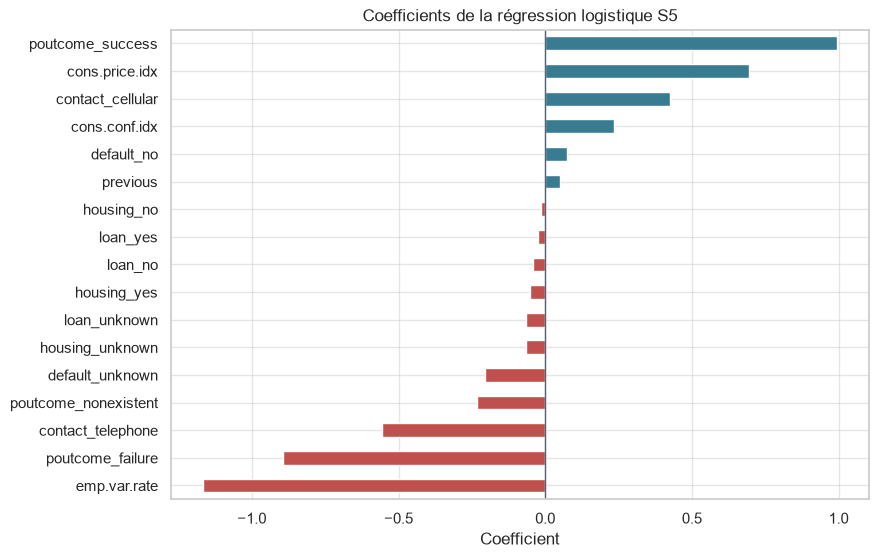

,coefficient
emp.var.rate,-1.167
poutcome_success,0.995
poutcome_failure,-0.895
cons.price.idx,0.693
contact_telephone,-0.557
contact_cellular,0.425
cons.conf.idx,0.236
poutcome_nonexistent,-0.232
default_unknown,-0.206
default_no,0.073


In [55]:
# 7.1.1 Coefficients de la régression logistique S5

# La régression logistique donne un coefficient par colonne après préprocessing.
# Les variables numériques sont standardisées, donc leurs coefficients sont comparables entre eux.
# Un coefficient positif augmente la probabilité de souscrire, un coefficient négatif la diminue.
# Chaque modalité d'une variable catégorielle a son propre coefficient, issu du OneHotEncoder.
noms_colonnes = pd.Index(
    pipe_final.named_steps["prep"].get_feature_names_out()
).str.replace(r"^(num|cat)__", "", regex=True)

coefficients = pd.Series(
    pipe_final.named_steps["clf"].coef_[0], index=noms_colonnes
).sort_values()

fig, ax = plt.subplots(figsize=(9, 0.3 * len(coefficients) + 1))
coefficients.plot.barh(
    ax=ax, color=np.where(coefficients > 0, "#397c91", "#c0504d")
)
ax.axvline(0, color="#526174", linewidth=1)
ax.set(xlabel="Coefficient", ylabel="",
       title="Coefficients de la régression logistique S5")
plt.show()

display(coefficients.sort_values(key=abs, ascending=False).round(3).to_frame("coefficient"))

# poutcome_success, cons.price.idx et contact_cellular favorisent le plus la souscription prédite.
# emp.var.rate, poutcome_failure et contact_telephone réduisent le plus la souscription prédite.
# cons.conf.idx, poutcome_nonexistent et default_unknown ont un effet plus faible sur le score.
# Les autres coefficients sont proches de zéro et contribuent peu au score.


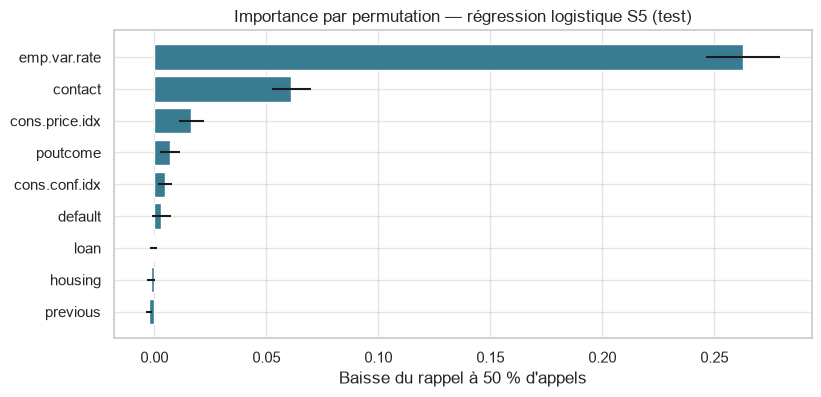

,baisse_rappel_moyenne,ecart_type
emp.var.rate,0.2628,0.0165
contact,0.0611,0.0086
cons.price.idx,0.0164,0.0056
poutcome,0.0068,0.0045
cons.conf.idx,0.0046,0.0032
default,0.0031,0.0041
loan,-0.0004,0.0016
housing,-0.0015,0.0016
previous,-0.0024,0.0014


In [56]:
# 7.1.2 Importance par permutation sur le test

from sklearn.inspection import permutation_importance

# On mélange une variable à la fois dans le test, puis on mesure la baisse du rappel à 50 % d'appels.
# Plus le rappel baisse, plus le modèle s'appuie sur cette variable.
# On obtient une importance par variable d'origine, toutes modalités confondues.
# Le mélange est répété 10 fois par variable pour mesurer la variabilité.
def score_rappel_top50(estimateur, X, y):
    return rappel_selection(y, estimateur.predict_proba(X)[:, 1], 0.50)

permutation = permutation_importance(
    pipe_final, X_test, y_test, scoring=score_rappel_top50,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

# Les variables hors S5 ne sont pas utilisées par le modèle : leur importance vaut 0.
importance_permutation = pd.DataFrame({
    "baisse_rappel_moyenne": permutation.importances_mean,
    "ecart_type": permutation.importances_std,
}, index=X_test.columns).loc[sorted(variables_retenues)].sort_values("baisse_rappel_moyenne")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(importance_permutation.index, importance_permutation["baisse_rappel_moyenne"],
        xerr=importance_permutation["ecart_type"], color="#397c91")
ax.set(xlabel="Baisse du rappel à 50 % d'appels", ylabel="",
       title="Importance par permutation — régression logistique S5 (test)")
plt.show()

display(importance_permutation.sort_values("baisse_rappel_moyenne", ascending=False).round(4))

# emp.var.rate est la variable la plus importante : son mélange fait perdre 26 points de rappel.
# contact arrive ensuite, avec une perte de 6 points de rappel après mélange.
# cons.price.idx apporte moins, avec une perte de 1,6 point de rappel après mélange.
# Les autres variables ont peu d’influence sur le rappel à 50 % d’appels.


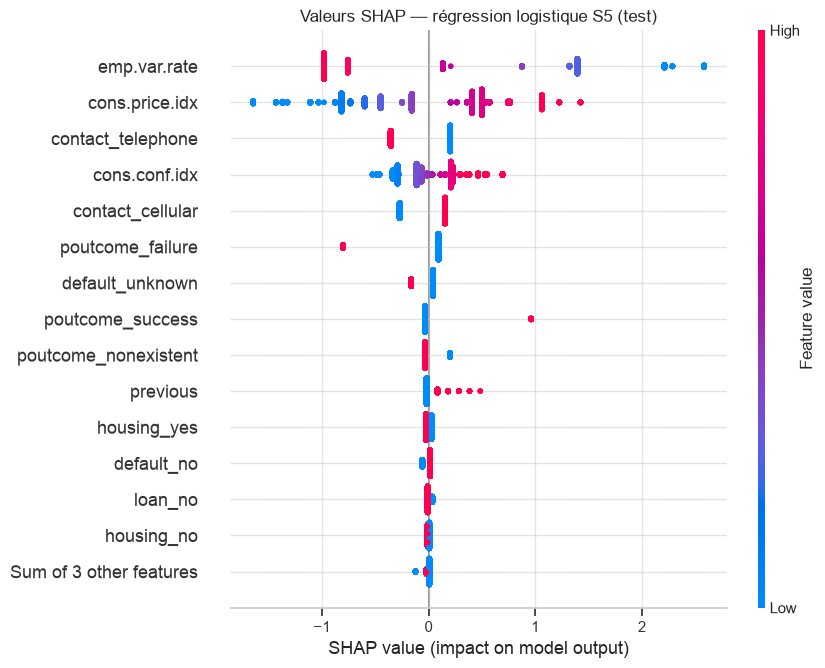

Client le mieux classé — probabilité de souscrire : 97.8%, souscription réelle : non


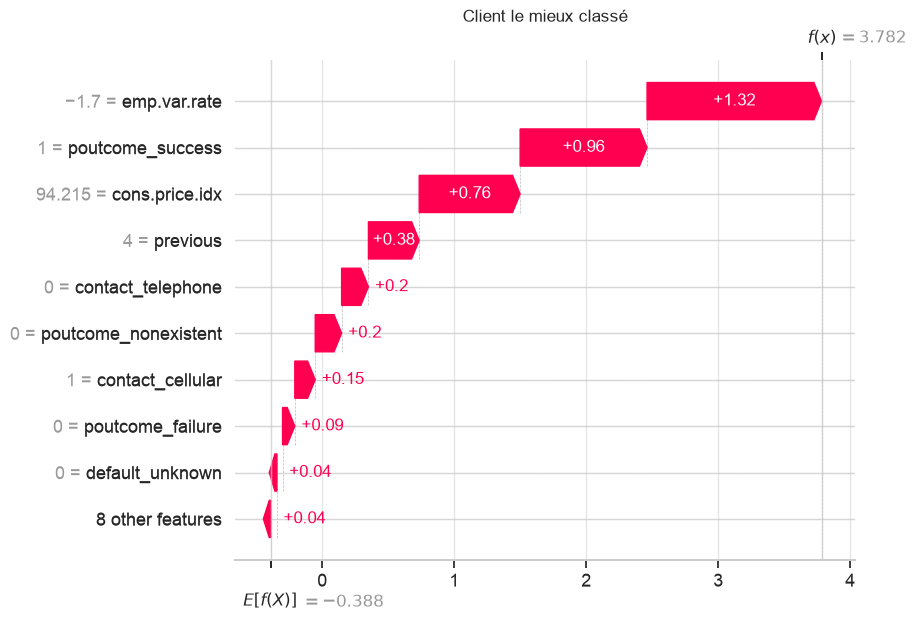

Client le moins bien classé — probabilité de souscrire : 10.0%, souscription réelle : non


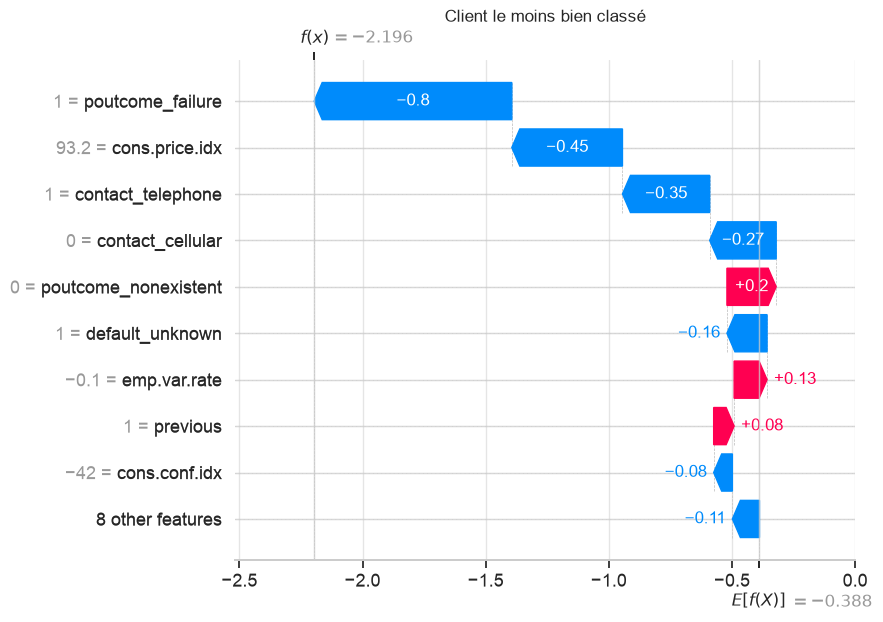

In [57]:
# 7.1.3 Valeurs SHAP

import shap
from scipy.sparse import issparse

# SHAP décompose la prédiction de chaque client en une contribution par colonne.
# Pour une régression logistique, LinearExplainer calcule ces contributions directement.
# Les contributions s'expriment en log-odds, l'échelle interne de la régression logistique.
# Le train sert de référence : une contribution mesure l'écart à un client moyen du train.
def preparer(donnees):
    matrice = pipe_final.named_steps["prep"].transform(donnees)
    matrice = matrice.toarray() if issparse(matrice) else matrice
    return pd.DataFrame(matrice, columns=noms_colonnes, index=donnees.index)

reference = shap.maskers.Independent(preparer(X_train), max_samples=len(X_train))
explainer = shap.LinearExplainer(pipe_final.named_steps["clf"], reference)
valeurs_shap = explainer(preparer(X_test))

# Les graphiques affichent les valeurs d'origine des colonnes numériques, sans la standardisation.
donnees_affichage = preparer(X_test)
colonnes_numeriques = sorted(variables_retenues & colonnes_num)
donnees_affichage[colonnes_numeriques] = X_test[colonnes_numeriques]
valeurs_shap.data = donnees_affichage.to_numpy()

# Vue globale : chaque point est un client du test.
# La position horizontale donne la contribution, la couleur donne la valeur de la colonne.
shap.plots.beeswarm(valeurs_shap, max_display=15, show=False)
plt.title("Valeurs SHAP — régression logistique S5 (test)")
plt.show()

# Vue locale : décomposition de la prédiction pour deux clients du test.
# Le client le mieux classé par le modèle, puis le moins bien classé.
for titre, position in [("Client le mieux classé", probas_test.argmax()),
                        ("Client le moins bien classé", probas_test.argmin())]:
    print(f"{titre} — probabilité de souscrire : {probas_test[position]:.1%}, "
          f"souscription réelle : {'oui' if y_test.iloc[position] == 1 else 'non'}")
    shap.plots.waterfall(valeurs_shap[position], max_display=10, show=False)
    plt.title(titre)
    plt.show()

# emp.var.rate et cons.price.idx contribuent le plus aux scores des clients du test.
# Un faible emp.var.rate et un cons.price.idx élevé poussent le score vers la souscription.

# Pour le client le mieux classé, emp.var.rate et poutcome_success augmentent le plus le score.
# Sa probabilité prédite atteint 97,8 %, alors qu’il n’a réellement pas souscrit.

# Le client le moins bien classé a la plus faible probabilité prédite de souscrire : 10,0 %.
# Son graphique explique ce score faible ; ce client n’a réellement pas souscrit.

# SHAP confirme le rôle dominant de emp.var.rate, déjà observé avec la permutation.
# cons.price.idx et contact restent parmi les principales contributions, avec un ordre différent.
# Le sens des contributions est cohérent avec les coefficients de la régression logistique.


#### 7.1.4 Conclusion feature importance / SHAP

Les coefficients, l’importance par permutation et SHAP donnent des résultats cohérents sur les principales variables utilisées par le modèle.

- **`emp.var.rate` — taux de variation de l’emploi** : c’est la variable la plus importante. Une valeur plus faible augmente la probabilité prédite de souscrire ; une valeur plus élevée la diminue.
- **`contact` — mode de contact** : le contact par mobile (`contact_cellular`) augmente la probabilité prédite ; le téléphone fixe (`contact_telephone`) la diminue.
- **`cons.price.idx` — indice des prix à la consommation** : une valeur plus élevée augmente la probabilité prédite ; une valeur plus faible la diminue.
- **`poutcome` — résultat de la campagne précédente** : un succès (`poutcome_success`) augmente la probabilité prédite ; un échec (`poutcome_failure`) la diminue. Cette variable a des coefficients marqués, mais son apport au rappel à 50 % d’appels reste faible.

On remarque que deux indicateurs majeurs, `emp.var.rate` et `cons.price.idx`, décrivent la conjoncture économique plutôt que des données liées au client ; `contact` décrit le canal de communication.


**Les autres variables ont globalement moins d’importance pour la prédiction**, notamment les prêts immobilier et personnel (`housing`, `loan`), le défaut de crédit (`default`) et le nombre de contacts antérieurs (`previous`). L’indice de confiance des consommateurs (`cons.conf.idx`) contribue plus modestement au score.


### 7.2 Analyse des erreurs et stratégies de fallback

In [58]:
# 7.2 Analyse des erreurs et profils à escalader

,Pas appelé,Appelé
N'a pas souscrit,3954,3354
A souscrit,164,764


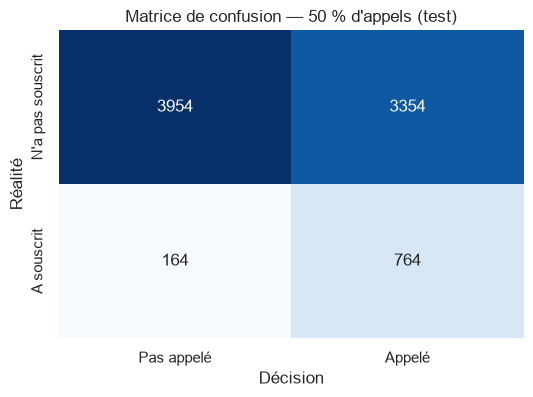

Clients appelés            : 4118 sur 8236
Souscripteurs retrouvés    : 764 sur 928 (82.3%)
Souscripteurs ratés        : 164
Appels inutiles            : 3354
Souscription parmi appelés : 18.6% (contre 11.3% sans ciblage)
Probabilité du dernier client appelé : 0.298


In [59]:
# 7.2.1 Matrice de confusion à 50 % d'appels sur le test
from sklearn.metrics import confusion_matrix

# Les clients du test sont classés par probabilité décroissante, puis la moitié la mieux classée est appelée.
# C'est la même sélection que pour le rappel à 50 % d'appels.
appele = np.zeros(len(probas_test), dtype=int)
appele[np.argsort(-probas_test, kind="stable")[: len(probas_test) // 2]] = 1

# La matrice croise la souscription réelle et la décision d'appel.
matrice = pd.DataFrame(
    confusion_matrix(y_test, appele),
    index=["N'a pas souscrit", "A souscrit"],
    columns=["Pas appelé", "Appelé"],
)
display(matrice)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set(title="Matrice de confusion — 50 % d'appels (test)", xlabel="Décision", ylabel="Réalité")
plt.show()

(vrais_negatifs, faux_positifs), (faux_negatifs, vrais_positifs) = matrice.to_numpy()
print(f"Clients appelés            : {appele.sum()} sur {len(appele)}")
print(f"Souscripteurs retrouvés    : {vrais_positifs} sur {vrais_positifs + faux_negatifs} ({vrais_positifs / (vrais_positifs + faux_negatifs):.1%})")
print(f"Souscripteurs ratés        : {faux_negatifs}")
print(f"Appels inutiles            : {faux_positifs}")
print(f"Souscription parmi appelés : {vrais_positifs / appele.sum():.1%} (contre {y_test.mean():.1%} sans ciblage)")
print(f"Probabilité du dernier client appelé : {probas_test[appele == 1].min():.3f}")

# Sur les 928 souscripteurs du test, le modèle en retrouve 764 en appelant la moitié des clients, soit un rappel de 82,3 %.
# Les 164 souscripteurs restants ne sont pas appelés : ce sont les erreurs qui coûtent des souscriptions.
# Les appels inutiles sont nombreux : 3 354 clients appelés ne souscrivent pas, soit 4 appels sur 5.
# Ce coût est attendu, car seuls 11,3 % des clients souscrivent : le ciblage fait monter ce taux à 18,6 % parmi les clients appelés.
# Le dernier client appelé a une probabilité de 0,298 : la coupure à 50 % d'appels correspond donc à ce seuil sur le test.



age — rappel de l'ensemble du test : 82.3%
             clients  part_appelee  souscripteurs  souscripteurs_rates  rappel  fragile
age                                                                                    
45–54           1727         0.395            129                   38   0.705    False
55–64            721         0.472             89                   20   0.775    False
35–44           2734         0.457            252                   51   0.798    False
25–34           2720         0.570            346                   53   0.847    False
Moins de 25      214         0.818             50                    2   0.960    False
65 et plus       120         1.000             62                    0   1.000    False

job — rappel de l'ensemble du test : 82.3%
               clients  part_appelee  souscripteurs  souscripteurs_rates  rappel  fragile
job                                                                                      
blue-collar       1813      

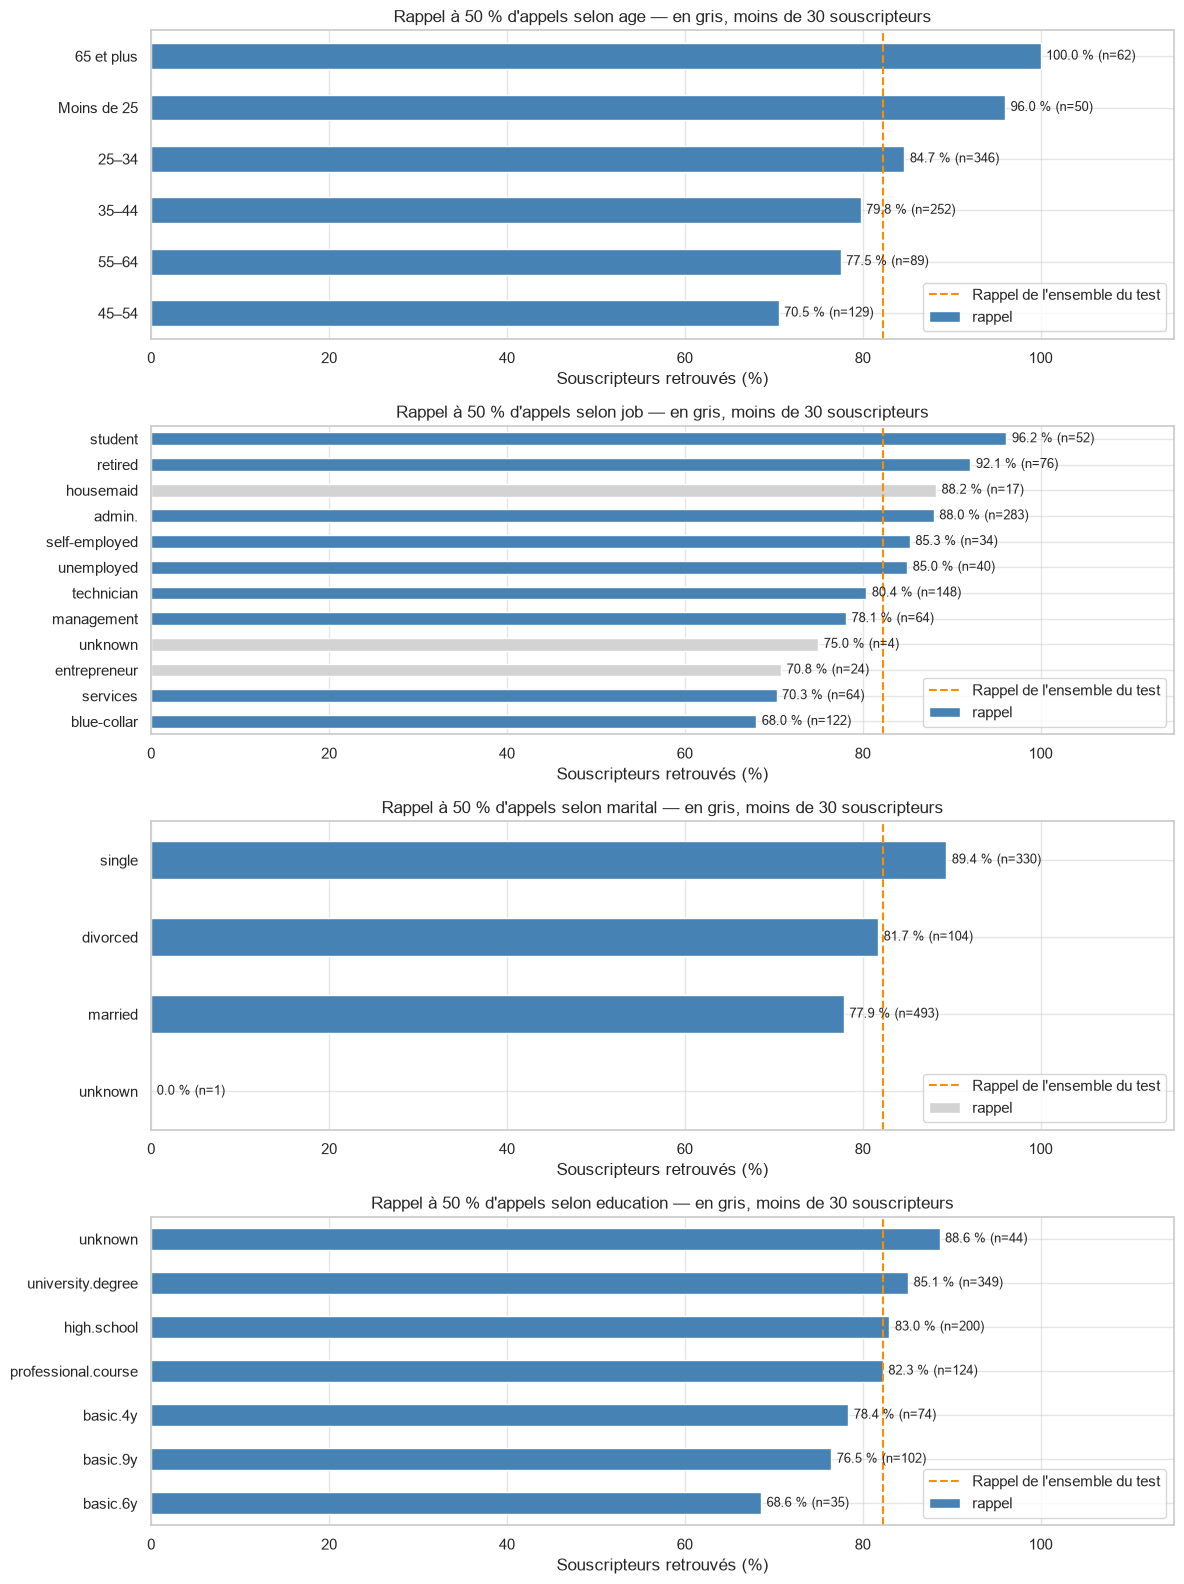

In [60]:
# 7.2.2 Souscripteurs ratés par profil sur le test

# Pour chaque groupe, on calcule la part de clients appelés et le rappel du groupe, puis on les compare à l'ensemble du test.
# Un rappel plus faible que celui de l'ensemble signifie que le modèle rate davantage de souscripteurs dans ce groupe.
# Le modèle S5 n'utilise pas les variables sensibles, mais elles restent disponibles dans X_test pour cette analyse.
profils_test = pd.DataFrame({
    "age": tranches_age.loc[X_test.index],
    "job": X_test["job"],
    "marital": X_test["marital"],
    "education": X_test["education"],
})
resultats_test = pd.DataFrame({"appele": appele, "souscrit": y_test.to_numpy()}, index=X_test.index)
resultats_test["rate"] = resultats_test["souscrit"].eq(1) & resultats_test["appele"].eq(0)
rappel_global = vrais_positifs / (vrais_positifs + faux_negatifs)

# Un groupe de moins de 30 souscripteurs dans le test donne un rappel peu fiable : il est signalé comme fragile.
erreurs_par_profil = {}
for variable in profils_test:
    tableau = resultats_test.groupby(profils_test[variable], observed=True).agg(
        clients=("appele", "size"),
        part_appelee=("appele", "mean"),
        souscripteurs=("souscrit", "sum"),
        souscripteurs_rates=("rate", "sum"),
    )
    tableau["rappel"] = 1 - tableau["souscripteurs_rates"] / tableau["souscripteurs"]
    tableau["fragile"] = tableau["souscripteurs"] < EFFECTIF_MIN
    erreurs_par_profil[variable] = tableau.sort_values("rappel")
    print(f"\n{variable} — rappel de l'ensemble du test : {rappel_global:.1%}")
    print(erreurs_par_profil[variable].round(3).to_string())

fig, axes = plt.subplots(len(erreurs_par_profil), 1, figsize=(12, 4 * len(erreurs_par_profil)))
for ax, (variable, tableau) in zip(axes, erreurs_par_profil.items()):
    couleurs = np.where(tableau["fragile"], "lightgrey", "steelblue")
    (tableau["rappel"] * 100).plot.barh(ax=ax, color=couleurs)
    ax.bar_label(ax.containers[0],
                 labels=[f"{r * 100:.1f} % (n={n})" for r, n in zip(tableau["rappel"], tableau["souscripteurs"])],
                 padding=4, fontsize=9)
    ax.axvline(rappel_global * 100, color="darkorange", linestyle="--", label="Rappel de l'ensemble du test")
    ax.set(title=f"Rappel à 50 % d'appels selon {variable} — en gris, moins de 30 souscripteurs",
           xlabel="Souscripteurs retrouvés (%)", ylabel="", xlim=(0, 115))
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Les souscripteurs ratés se concentrent dans les groupes déjà désavantagés à l'EDA.
# Le rappel tombe à 70,5 % chez les 45–54 ans et à 68,0 % chez les ouvriers, contre 82,3 % sur l'ensemble du test.
# Les mariés (77,9 %) et les niveaux basic.6y (68,6 %) et basic.9y (76,5 %) sont aussi en dessous de l'ensemble.

# À l'inverse, le modèle retrouve presque tous les souscripteurs de 65 ans et plus (100 %) et de moins de 25 ans (96,0 %).
# Les étudiants (96,2 %) et les retraités (92,1 %) sont aussi bien retrouvés, et ces groupes sont les plus souvent appelés.

# Le modèle n'utilise aucune variable sensible, mais il reproduit les écarts observés dans les données.
# Les autres variables portent donc une partie de cette information.

# Les groupes fragiles, comme entrepreneur (24 souscripteurs), ont trop peu de souscripteurs pour interpréter leur rappel.


,clients,souscripteurs,taux_souscription,proba_min,proba_max,rappel_cumule
tranche,,,,,,
1,824,410,0.498,0.739,0.978,0.442
2,824,152,0.184,0.577,0.738,0.606
3,823,107,0.130,0.437,0.577,0.721
4,824,54,0.066,0.349,0.437,0.779
5,823,41,0.050,0.298,0.349,0.823
6,824,42,0.051,0.288,0.298,0.869
7,824,32,0.039,0.278,0.288,0.903
8,823,28,0.034,0.267,0.278,0.933
9,824,29,0.035,0.225,0.267,0.964


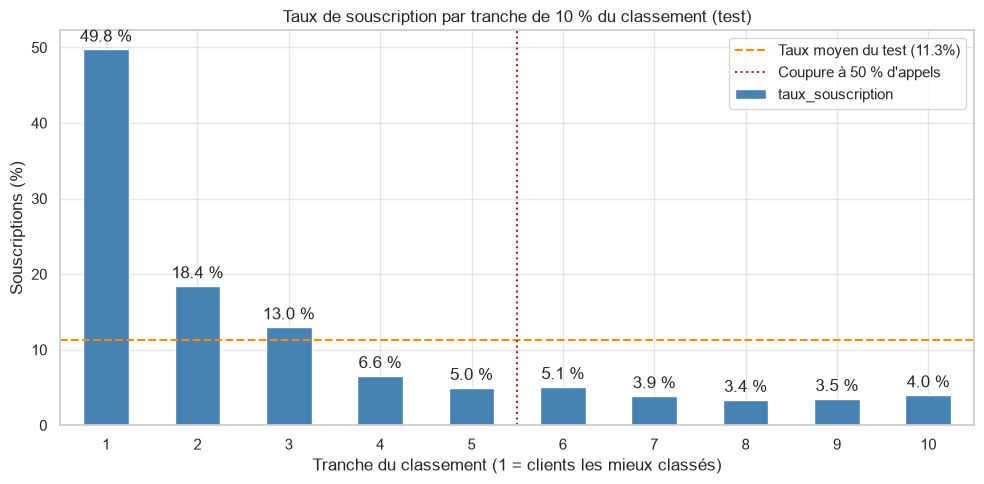

In [61]:
# 7.2.3 Taux de souscription par tranche de 10 % du classement sur le test

# Les clients du test sont classés par probabilité décroissante, puis découpés en 10 tranches de même taille.
# La tranche 1 contient les 10 % de clients les mieux classés, la tranche 10 les 10 % les moins bien classés.
# Un taux proche du taux moyen signale une tranche où le modèle ne départage plus les clients.
rangs = np.empty(len(probas_test), dtype=int)
rangs[np.argsort(-probas_test, kind="stable")] = np.arange(len(probas_test))
tranches_classement = rangs * 10 // len(probas_test) + 1

tableau_tranches = pd.DataFrame({
    "tranche": tranches_classement, "souscrit": y_test.to_numpy(), "proba": probas_test,
}).groupby("tranche").agg(
    clients=("souscrit", "size"),
    souscripteurs=("souscrit", "sum"),
    taux_souscription=("souscrit", "mean"),
    proba_min=("proba", "min"),
    proba_max=("proba", "max"),
)
# Part des souscripteurs du test retrouvés en appelant les tranches 1 à n
tableau_tranches["rappel_cumule"] = tableau_tranches["souscripteurs"].cumsum() / tableau_tranches["souscripteurs"].sum()
display(tableau_tranches.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
(tableau_tranches["taux_souscription"] * 100).plot.bar(
    ax=ax, color="steelblue", rot=0, label="Taux de souscription de la tranche"
)
ax.bar_label(ax.containers[0], labels=[f"{t * 100:.1f} %" for t in tableau_tranches["taux_souscription"]], padding=3)
ax.axhline(y_test.mean() * 100, color="darkorange", linestyle="--", label=f"Taux moyen du test ({y_test.mean():.1%})")
ax.axvline(4.5, color="firebrick", linestyle=":", label="Coupure à 50 % d'appels")
ax.set(title="Taux de souscription par tranche de 10 % du classement (test)",
       xlabel="Tranche du classement (1 = clients les mieux classés)", ylabel="Souscriptions (%)")
ax.legend()
fig.tight_layout()
plt.show()

# La tranche 1 concentre 49,8 % de souscripteurs, soit 4,4 fois le taux moyen du test (11,3 %).
# Les tranches 2 (18,4 %) et 3 (13,0 %) restent au-dessus du taux moyen.
# En appelant ces 30 % de clients, on retrouve déjà 72,1 % des souscripteurs.

# À partir de la tranche 4, le taux passe sous le taux moyen et devient presque plat, entre 3,4 % et 6,6 %.
# Le modèle ne départage donc plus les clients au-delà des 30 % les mieux classés.

# Les tranches 4 et 5 sont appelées dans la coupure à 50 %, avec seulement 5,0 % à 6,6 % de souscripteurs.
# Elles ajoutent environ 10 points de rappel (72,1 % → 82,3 %) pour 1 647 appels supplémentaires.
# Ces tranches forment la zone où le classement est peu fiable.

# Si la banque veut d'abord économiser des appels, elle peut appeler seulement les 30 % de clients les mieux classés.
# Elle retrouve alors 72,1 % des souscripteurs avec deux cinquièmes d'appels en moins (on passe de 50 % à 30 % des clients appelés).


#### 7.2.4 Stratégies de fallback

Le modèle ne répond pas « oui » ou « non » pour chaque client : il trie tous les clients du plus prometteur au moins prometteur. Les trois leviers s'appliquent donc à cette liste triée.

| Levier | Pour le besoin métier comme il a été défini | Fondement |
|---|---|---|
| **Seuil** | On choisit combien de clients appeler en haut de la liste. En appelant 30 % des clients, on retrouve 72,1 % des souscripteurs ; en appelant 50 %, on en retrouve 82,3 %. Au-delà des 30 % les mieux classés, le modèle ne départage plus les clients : seuls 4,5 % d'entre eux souscrivent, contre 11,3 % sur l'ensemble des clients. | Taux de souscription par tranche de 10 % du classement |
| **Abstention** | Si les données d'un client sont fausses ou incomplètes, on ne lui donne pas de score. | Contrôle des données à l'entrée du modèle |
| **Escalade humaine** | Un conseiller regarde de plus près les profils que le modèle rate le plus : les ouvriers (68,0 % des souscripteurs retrouvés) et les 45–54 ans (70,5 %), contre 82,3 % sur l'ensemble. | Souscripteurs ratés par profil : les erreurs se concentrent dans les groupes déjà désavantagés à l'EDA. Les mariés (77,9 %) et les niveaux basic.6y (68,6 %) et basic.9y (76,5 %) sont aussi sous l'ensemble. Le modèle n'utilise aucune variable sensible, mais il reproduit ces écarts. |


### 7.3 Message au client (langage métier)

**On retient un modèle simple, fondé sur neuf variables sans données sensibles, qui retrouve 82,3 % des souscripteurs en sélectionnant la moitié des clients et porte ainsi leur taux de souscription à 18,6 %.**
Le modèle retenu classe les clients pour donner la priorité aux plus susceptibles de souscrire. Sur le jeu de test, appeler la moitié des clients permet de retrouver 82,3 % des souscripteurs : l’objectif métier fixé de 80 % est atteint. Le taux de souscription parmi les clients sélectionnés atteint 18,6 %, contre 11,3 % sur l’ensemble du test. Le modèle retenu est simple à expliquer (régression logisitique) et utilise neuf variables, sans l’âge, la profession, la situation familiale ni le niveau d’éducation, qui sont toutes des variables sensibles.

**Le classement repose surtout sur le contexte économique et le mode de contact, puis sur le résultat de la campagne précédente. Les données propres aux clients ont peu d'influence sur la prédiction.**
Le taux de variation de l’emploi est la variable la plus influente : une valeur plus faible augmente la probabilité prédite de souscrire. Un indice des prix à la consommation plus élevé et un contact par mobile augmentent aussi cette probabilité. Un succès lors de la campagne précédente favorise le score, mais contribue peu à retrouver davantage de souscripteurs parmi les 50 % de clients sélectionnés. Les prêts immobilier et personnel, le défaut de crédit et le nombre de contacts antérieurs ont globalement moins d’influence sur la prédiction.

**Les 30 % de clients les mieux classés regroupent 72,1 % des souscripteurs ; passer à 50 % ajoute 1 647 appels pour atteindre 82,3 %, avec des taux de souscription faibles et proches dans les tranches suivantes.**
Les 30 % de clients les mieux classés regroupent déjà 72,1 % des souscripteurs. Passer de 30 % à 50 % de clients appelés permet d’atteindre 82,3 %, avec 1 647 appels supplémentaires sur le test. Au-delà des 30 % les mieux classés, les taux de souscription restent faibles et proches entre les tranches du classement.

**Malgré le retrait des variables sensibles, les ouvriers et les 45–54 ans restent moins bien retrouvés et nécessitent un examen par les conseillers.**
Le modèle retrouve 68,0 % des souscripteurs chez les ouvriers et 70,5 % chez les 45–54 ans, contre 82,3 % sur l’ensemble du test. Les personnes mariées et les clients de niveau d’éducation de base sont aussi moins bien retrouvés. Ces écarts persistent malgré le retrait de l’âge, de la profession, de la situation familiale et du niveau d’éducation, les quatre variables sensibles identifiées. Un conseiller doit examiner de plus près les profils des ouvriers et des 45–54 ans ; aucun score ne doit être attribué si les données du client sont fausses ou incomplètes.



### 7.4 Synthèse interprétation

**Variables-clés** : les coefficients, l’importance par permutation et SHAP confirment le rôle dominant de `emp.var.rate` (taux de variation de l’emploi), avec une valeur faible qui augmente le score de souscription. `contact` (mode de contact) et `cons.price.idx` (indice des prix à la consommation) figurent aussi parmi les principales variables : le mobile et un indice des prix élevé augmentent le score. Un succès de la campagne précédente (`poutcome`) augmente également le score, avec un apport plus faible au rappel à 50 % d’appels. Les autres variables contribuent globalement moins.

**Profils mal prédits** : le rappel atteint 68,0 % chez les ouvriers et 70,5 % chez les 45–54 ans, contre 82,3 % sur l’ensemble du test. Les personnes mariées (77,9 %) et les niveaux d’éducation `basic.6y` (68,6 %) et `basic.9y` (76,5 %) sont également moins bien retrouvés. Les écarts observés dans les données se retrouvent dans les erreurs du modèle malgré le retrait des variables sensibles. Les rappels des groupes comptant moins de 30 souscripteurs sont signalés comme fragiles.

**Vigilance opérationnelle** : la sélection dépend du volume d’appels choisi. À 50 % d’appels, le modèle retrouve 764 des 928 souscripteurs du test ; les 164 autres sont manqués et 3 354 appels concernent des clients qui ne souscrivent pas. Les tranches au-delà des 30 % les mieux classés sont peu discriminantes. Les leviers retenus sont le **seuil** de sélection, l’**abstention** si les données d’un client sont fausses ou incomplètes, et l’**escalade humaine** pour les profils les plus souvent manqués. La forte contribution du contexte économique invite aussi à vérifier la pertinence du modèle sur une autre période.


---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

🎯 Transformer le modèle en **service exploitable** : API, UI, conteneurs, tracking d'expériences.

> ⚠️ **Cette section ne contient PAS le code de l'API/UI.** Le code vit dans le **repo Git** associé.  
> Dans le notebook, on met uniquement :
> 1. **Description architecturale** (texte)
> 2. **1 schéma** d'architecture (Mermaid, draw.io export, ou image)
> 3. **Lien vers le repo Git** + dossiers concernés
> 4. **Captures d'écran clés** (UI, dashboard, OpenAPI Swagger, workflow CI/CD vert)
> 5. **Justifications des choix techniques** (pourquoi FastAPI plutôt que Flask, pourquoi MLflow plutôt que `experiments.md`, etc.)

⚠️ Attendus certif (présents dans le repo, **référencés** dans cette section du notebook) :  
- API FastAPI avec routes `/predict`, `/train`, `/health`  
- Validation Pydantic des entrées  
- Logging structuré (Loguru)  
- Tests pytest  
- Conteneurisation Docker  
- CI/CD GitHub Actions  
- Tracking MLflow

### 8.1 Persistance du modèle

**Régression logistique du scénario S5** : l'API sert le modèle retenu après la comparaison des modèles, une régression logistique entraînée sur les 9 variables du scénario S5.

**Deux fichiers produits par `training/train.py`** : le script refait l'entraînement hors du notebook, avec le même découpage train / test et la même recette. Il écrit dans `models/` :

| Fichier | Contenu |
|---|---|
| `pipeline.joblib` | Le préprocessing et le modèle, réunis en un seul objet. L'API reçoit les données brutes d'un client et leur applique exactement la transformation de l'entraînement. |
| `pipeline.json` | La fiche d'identité du modèle : version, date, commit Git, empreinte du fichier de données, version de scikit-learn, hyperparamètres et scores sur le test. Il contient aussi, pour chaque tranche de 10 % du classement du test, le score minimal et le taux réel de souscription. |

**Suivi des entraînements avec MLflow** : chaque entraînement est enregistré dans MLflow, avec ses paramètres, ses scores et le modèle. `pipeline.json` note l'identifiant de cet enregistrement. On retrouve ainsi l'entraînement qui a produit le modèle servi.

**Mêmes scores que l'évaluation finale du notebook** : le script retrouve les scores sur le jeu de test. Les 50 % de clients les mieux classés regroupent 82,3 % des souscripteurs, et le ROC AUC vaut 0,791.

### 8.2 API de service

**Code dans le dossier `api/`** du repo [eval-usecase-marketing](https://github.com/franckcwalter/eval-usecase-marketing).

**Trois routes servies par FastAPI**

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | Indique que le service tourne et donne la version du modèle servi | — |
| `/predict` | POST | Renvoie le score d'un client, sa tranche de 10 % et le taux réel de souscription de cette tranche | Pydantic |
| `/rank` | POST | Reçoit un CSV de clients et le renvoie trié par score, avec le rang, la tranche de 10 % et le taux réel de la tranche de chaque client | Pydantic, ligne par ligne |

![Documentation Swagger de l'API](assets/swagger.png)

**Appel à `/predict` pour un client**

Requête `POST /predict` :

```json
{
  "contact": "cellular",
  "default": "no",
  "housing": "yes",
  "loan": "no",
  "poutcome": "nonexistent",
  "previous": 0,
  "emp.var.rate": -1.8,
  "cons.price.idx": 92.893,
  "cons.conf.idx": -46.2
}
```

Réponse `200` :

```json
{
  "score": 0.577,
  "tranche": "10-20 %",
  "taux_reel_tranche": 0.1845,
  "model_version": "1.0.0",
  "request_id": "99f8338d-b3a8-40c2-9acf-a7cd36346eb5"
}
```

**Un score pour classer, et le taux réel de sa tranche pour le lire** : le modèle donne plus de poids aux souscripteurs pendant l'entraînement. Ses scores sont donc plus hauts que les chances réelles : 0,40 en moyenne, pour 11,3 % de souscripteurs. L'API accompagne chaque score du taux de souscription mesuré sur le jeu de test dans sa tranche. Le client de l'exemple a un score de 0,577 : il tombe dans la tranche 10-20 %, où 18,5 % des clients ont réellement souscrit.

**Validation des entrées avec Pydantic** : chaque champ a un type et une liste de valeurs autorisées. Par exemple, `contact` vaut `cellular` ou `telephone`, et `previous` est un entier positif ou nul. Une entrée invalide reçoit une erreur 422 qui nomme le champ en cause. `/rank` contrôle chaque ligne du CSV de la même façon et indique la ligne et la colonne en erreur.

**Un log JSON par requête avec Loguru**, dans `logs/api.log` :
- toutes les routes : horodatage, route, statut, temps de réponse et identifiant de requête ;
- `/predict` : les 9 entrées du client, le score et la tranche renvoyés ;
- `/rank` : le nom du fichier, le nombre de clients et le score moyen.

**16 tests automatisés avec pytest** :
- `/predict` renvoie le même score que le modèle appelé directement, avec une tranche et son taux réel, la même réponse à deux appels identiques, et une erreur 422 pour une valeur invalide ou un champ manquant ;
- `/rank` trie les clients, ajoute le rang, la tranche et le taux réel de la tranche, et accepte les séparateurs `;` et `,` ;
- `/rank` refuse un fichier vide, une colonne manquante ou une valeur invalide ;
- le découpage en tranches donne dix parts égales, et un score seul tombe dans la bonne tranche du jeu de test.

### 8.3 Interface utilisateur

**Une page web en HTML, CSS et JavaScript, servie par FastAPI** : le dossier `frontend/` contient une seule page, sans framework. FastAPI la sert à l'adresse racine, à côté des routes de l'API. Le conseiller ouvre la page dans son navigateur, sans rien installer.

**Un client : un formulaire relié à `/predict`** : le conseiller saisit les 9 informations du client, ou tire un vrai client du jeu de données avec le bouton « Client au hasard », pour la démonstration. La carte de résultat affiche la tranche du client et le taux de souscription observé dans cette tranche. Elle est verte pour les tranches 0 à 30 %, orange de 30 à 50 % et rouge au-delà. Ces seuils suivent l'analyse des erreurs : les 30 % de clients les mieux classés regroupent 72 % des souscripteurs, et les tranches 30-50 % ont un taux de souscription sous la moyenne.

![Client dans la tranche 10-20 %](assets/ui_client_tranche_10_20.png)

![Client dans la tranche 50-60 %](assets/ui_client_tranche_50_60.png)

**Un fichier de clients : un dépôt de CSV relié à `/rank`** : la banque dépose son fichier, et la page affiche le nombre de clients classés. Un curseur garde les 10 %, 20 %, … ou 100 % des clients les mieux classés. Trois indicateurs suivent le curseur : le nombre de clients gardés, le taux de souscription observé dans les tranches gardées et ce taux sur tout le fichier. Sur les 41 188 clients du jeu de données, garder les 50 % les mieux classés donne un taux observé de 18,5 %, contre 11,3 % sur tout le fichier. Un aperçu montre les 20 premiers clients gardés, et un bouton télécharge le CSV filtré.

![Classement d'un fichier de clients](assets/ui_fichier_clients.png)

### 8.4 Schéma d'architecture

**Du fichier de données au modèle servi, avec `training/train.py`**

```mermaid
flowchart TD
  CSV[("data/bank-additional-full.csv")]
  PREP["Nettoyage<br>suppression des doublons"]
  SPLIT["Découpage train / test<br>80 / 20, stratifié, random_state = 42"]
  PIPE["Pipeline scikit-learn<br>garde les 9 variables du scénario S5<br>numériques : StandardScaler<br>catégorielles : regroupement de default + OneHotEncoder<br>LogisticRegression, class_weight = balanced"]
  EVAL["Évaluation sur le test<br>rappel du top 25 / 30 / 50 / 75 %, ROC AUC<br>score minimal et taux réel de chaque tranche de 10 %"]
  MLF[("MLflow<br>mlflow.db, mlruns/")]
  JOB[("models/pipeline.joblib")]
  JSON[("models/pipeline.json")]

  CSV -->|"41 188 lignes, 21 colonnes"| PREP
  PREP -->|"41 176 lignes, cible y codée en 0 / 1"| SPLIT
  SPLIT -->|"X_train, y_train"| PIPE
  SPLIT -->|"X_test, y_test"| EVAL
  PIPE -->|"pipeline entraîné, predict_proba sur X_test"| EVAL
  EVAL -->|"paramètres, métriques, modèle"| MLF
  PIPE -->|"préprocessing + modèle, joblib.dump"| JOB
  EVAL -->|"version, commit Git, empreinte des données,<br>métriques, tranches du test, id du run MLflow"| JSON
```

**Architecture frontend et backend**

```mermaid
flowchart LR
  subgraph FRONT["Frontend — navigateur du conseiller"]
    UI["HTML / CSS<br>formulaire client et dépôt CSV"]
    JS["JavaScript<br>appels API, affichage et téléchargement"]
    UI -->|"9 champs du client ou fichier CSV"| JS
    JS -->|"tranche, taux observé et classement filtré"| UI
  end

  subgraph BACK["Backend — FastAPI"]
    STATIC["Fichiers frontend/<br>index.html, styles.css, app.js"]
    API["Routes /predict et /rank<br>validation Pydantic"]
    MODEL["Pipeline scikit-learn en mémoire<br>préprocessing et régression logistique"]
    RANK["Calcul des tranches<br>classement des clients"]
    JOB[("models/pipeline.joblib")]
    META[("models/pipeline.json")]
    LOG[("logs/api.log<br>Loguru")]
    JOB -->|"chargement au démarrage avec joblib"| MODEL
    API -->|"9 variables validées"| MODEL
    MODEL -->|"scores predict_proba"| RANK
    META -->|"seuils et taux observés sur le test"| RANK
    RANK -->|"score, tranche, taux ou clients classés"| API
    API -->|"requêtes, statuts, latence et résultats"| LOG
  end

  UI -->|"GET / et fichiers CSS / JavaScript"| STATIC
  STATIC -->|"page et ressources web"| UI
  JS -->|"POST /predict : JSON client<br>POST /rank : fichier CSV"| API
  API -->|"JSON : score, tranche, taux<br>CSV : clients classés<br>erreur 422 : données invalides"| JS
```

**Du conseiller à la réponse de l'API**

```mermaid
sequenceDiagram
  actor U as Conseiller
  participant F as Frontend
  participant A as API FastAPI
  participant M as Modèle

  U->>F: saisit un client
  F->>A: POST /predict, JSON du client
  A->>M: profil validé par Pydantic
  M-->>A: score
  A-->>F: score, tranche, taux observé
  F-->>U: affiche la tranche du client

  U->>F: dépose un fichier CSV
  F->>A: POST /rank, fichier CSV
  A->>M: profils validés par Pydantic
  M-->>A: scores
  A-->>F: CSV classé par score, avec les tranches
  F-->>U: liste des meilleurs clients à télécharger
```


### 8.5 Conteneurisation & CI/CD

*[Dockerfile, docker-compose.yml, workflow GitHub Actions (build → test → push). Captures d'écran d'un run CI vert. Liens vers les fichiers du repo.]*


### 8.6 📝 Synthèse industrialisation

*[Pile retenue, choix d'architecture, points encore ouverts.]*

---
## 9. Suivi en production & amélioration continue

**Compétences** : C8 (mesurer performance), C9 (amélioration continue)

🎯 Anticiper la dérive et la maintenance du modèle après mise en prod.

💡 Drift = data drift (entrées qui changent) vs concept drift (la cible change de comportement).  
⚠️ Pas de monitoring = pas de prod. Même un dashboard simple Streamlit suffit pour démarrer.

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | F1 hebdo | < baseline - 0.05 | logs API |
| Données | PSI variables clés | > 0.2 | batch journalier |
| Système | latence p95 | > 500 ms | Prometheus |

### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs / annotations correctives reviennent dans les données d'entraînement ?]*

### 9.3 Plan de réentraînement

*[Trigger (calendaire ? performance ? volume nouvelles données ?), automatisation, validation avant mise en prod.]*

### 9.4 Robustesse en exploitation

🎯 Surveiller les **conditions de défaillance** une fois en prod, en complément des stratégies de fallback définies en §7.2 (côté conception).

💡 La conception du fallback (où placer le seuil, qui escalader) vit en §7.2. Ici on instrumente la **mesure** et le **déclenchement** :

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| **OOD (Out-Of-Distribution)** | Distance Mahalanobis ou score d'isolation sur les entrées | Logger les inputs hors-distribution, déclencher abstention ou escalade humaine (cf §7.2) |
| **Drift du seuil de rejet** | Taux d'abstention / part de prédictions sous seuil de confiance | Réviser le rejection threshold si dérive > 20 % sur 4 semaines glissantes |
| **Calibration** | Brier score, courbe de calibration mensuelle | Recalibrer (Platt, isotonic) sans réentraîner le modèle complet si seule la calibration dérive |

⚠️ La chaîne conception → exploitation doit rester explicite. §7.2 définit le filet de sécurité, §9.4 le surveille. Casser cette chaîne (fallback conçu mais jamais mesuré) = attendu C8 N3 non atteint.

### 9.5 📝 Synthèse amélioration continue

*[Cadence de surveillance, déclencheurs de réentraînement, plan de remédiation en cas de dérive.]*

---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```